# Logistic Regression — Baseline Model
## Early Warning System for At-Risk Students | OULAD Dataset



In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — INSTALL & IMPORTS
# ════════════════════════════════════════════════════════════════════════════
!pip install shap lime xgboost scikit-learn pandas numpy matplotlib seaborn scipy joblib statsmodels -q

import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve as sk_lc)
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from xgboost                   import XGBClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.calibration       import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, brier_score_loss,
    classification_report
)
from scipy.stats import spearmanr, kendalltau
from collections import Counter
import shap
from lime import lime_tabular

SEED = 42
np.random.seed(SEED); random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

FIGURES_DIR = Path('figures_LR')
MODELS_DIR  = Path('models_LR')
CSV_DIR     = Path('results_LR')
for d in [FIGURES_DIR, MODELS_DIR, CSV_DIR]:
    d.mkdir(exist_ok=True)

PRIMARY_NAME  = 'Logistic Regression'
PRIMARY_COLOR = '#B71C1C'

MODEL_COLORS = {
    'XGBoost'            : '#006064',
    'Logistic Regression': '#B71C1C',
    'Decision Tree'      : '#E65100',
    'Random Forest'      : '#1565C0',
    'SVM'                : '#4A148C',
}

print(f'Libraries loaded. PRIMARY = {PRIMARY_NAME}  |  Seed = {SEED}')


# ── LIME configuration (centralised, single source of truth) ──────────────────
# LIME_PERTURB_SAMPLES: perturbations per instance for LIME's local surrogate.
#   LIME default = 5000 (Ribeiro et al., 2016); literature recommends >=1000-5000
#   for stable tabular rankings. Verified by the bootstrap CV% stability analysis.
# LIME_GLOBAL_N: #test instances explained to build the "global" LIME ranking
#   (LIME is local; global = mean|weight| over a STRATIFIED sample preserving the
#   class ratio). Justified empirically by the sensitivity cell.
LIME_PERTURB_SAMPLES = 5000
LIME_GLOBAL_N        = 300

def stratified_sample_indices(y, n, seed=SEED):
    """Return up to n indices preserving the class ratio of y (stratified)."""
    y = np.asarray(y); rng = np.random.RandomState(seed)
    if n >= len(y):
        return np.arange(len(y))
    idx_by_cls = {cls: np.where(y == cls)[0] for cls in np.unique(y)}
    picked = []
    for cls, idxs in idx_by_cls.items():
        k = max(1, int(round(n * len(idxs) / len(y))))
        picked.extend(rng.choice(idxs, min(k, len(idxs)), replace=False))
    return np.array(sorted(picked))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Libraries loaded. PRIMARY = Logistic Regression  |  Seed = 42


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — MOUNT DRIVE & LOAD DATA
# ════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/OULAD')

def load_csv(name):
    p = DATA_DIR / name
    if not p.exists():
        raise FileNotFoundError(f'Missing: {p}\n'
                                 'Download from https://analyse.kmi.open.ac.uk/open_dataset')
    df = pd.read_csv(p)
    print(f'  {name:35s} {df.shape}')
    return df

print('Loading OULAD …')
raw_info    = load_csv('studentInfo.csv')
raw_assess  = load_csv('studentAssessment.csv')
raw_vle     = load_csv('studentVle.csv')
raw_asmeta  = load_csv('assessments.csv')
raw_vlemeta = load_csv('vle.csv')
raw_courses = load_csv('courses.csv')
print('Done.')


Mounted at /content/drive
Loading OULAD …
  studentInfo.csv                     (32593, 12)
  studentAssessment.csv               (173912, 5)
  studentVle.csv                      (10655280, 6)
  assessments.csv                     (206, 6)
  vle.csv                             (6364, 6)
  courses.csv                         (22, 3)
Done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA CLEANING  [LEAKAGE-CORRECTED VERSION]
# ════════════════════════════════════════════════════════════════════════════
info    = raw_info.copy();   assess  = raw_assess.copy()
vle     = raw_vle.copy();    asmeta  = raw_asmeta.copy()
vlemeta = raw_vlemeta.copy()

# ── Held-out presentation, defined BEFORE any statistic is computed ──────────
TEST_PRES = sorted(raw_info['code_presentation'].unique())[-1]      # -> '2014J'
print(f'Held-out test presentation: {TEST_PRES}')

def tr(df):
    """Boolean mask selecting training-pool rows (all presentations except TEST_PRES)."""
    return df['code_presentation'] != TEST_PRES

cleaning_log = []
def clog(action, table, n, detail=''):
    cleaning_log.append({'Action':action,'Table':table,'N_affected':n,'Detail':detail})
    print(f'  [{table}] {action}: {n:,}  | {detail}')

# STEP 1: Duplicates
print('STEP 1: Duplicate removal')
for nm, df_r in [('info',info),('assess',assess),('vle',vle)]:
    n = len(df_r); df_r.drop_duplicates(inplace=True)
    clog('drop_duplicates', nm, n - len(df_r))

# STEP 2: studentInfo
print('\nSTEP 2: studentInfo categoricals')
info['imd_band'] = info['imd_band'].astype(str).str.strip().str.replace(' ','')
def map_imd(val):
    s = str(val).lower()
    if s in ['nan','unknown','none','']: return np.nan
    try: lo = int(s.split('-')[0].replace('%','')); return max(1, min(10, lo//10+1))
    except: return np.nan
info['imd_band_ordinal'] = info['imd_band'].apply(map_imd)
n_nan_imd = info['imd_band_ordinal'].isna().sum()
imd_med   = info.loc[tr(info),'imd_band_ordinal'].median()          # [FIX] train only
info['imd_band_ordinal'] = info['imd_band_ordinal'].fillna(imd_med)
clog('imd_band->ordinal, NaN->median','info', n_nan_imd, f'median={imd_med} (train only)')
for col in ['gender','disability']:
    n = info[col].isna().sum()
    if n > 0:
        mode_tr = info.loc[tr(info),col].mode()[0]                  # [FIX] train only
        info[col] = info[col].fillna(mode_tr)
        clog(f'{col} NaN->mode','info',n,f'mode={mode_tr} (train only)')
valid_ages = ['0-35','35-55','55<=']
n_bad_age  = (~info['age_band'].isin(valid_ages)).sum()
age_mode_tr = info.loc[tr(info) & info['age_band'].isin(valid_ages),
                       'age_band'].mode()[0]                        # [FIX] train only
info.loc[~info['age_band'].isin(valid_ages),'age_band'] = age_mode_tr
clog('age_band invalid->mode','info',n_bad_age,f'mode={age_mode_tr} (train only)')
info_tr      = info.loc[tr(info)]                                   # [FIX] train only
thresh       = 0.01*len(info_tr)
rare_regions = info_tr['region'].value_counts()[lambda x: x < thresh].index.tolist()
n_rare       = info['region'].isin(rare_regions).sum()
info.loc[info['region'].isin(rare_regions),'region'] = 'Other'
clog('rare region->Other','info',n_rare,str(rare_regions)+' (train-derived)')

# STEP 3: studentAssessment
print('\nSTEP 3: studentAssessment validation')
n_over  = (assess['score'] > 100).sum(); n_under = (assess['score'] < 0).sum()
assess.loc[assess['score'] > 100,'score'] = 100
assess.loc[assess['score'] < 0,  'score'] = 0
clog('score > 100 -> cap 100','assess',n_over)
clog('score < 0 -> 0',        'assess',n_under)
n_null = assess['score'].isna().sum()
assess['score'] = assess['score'].fillna(0)
clog('score NaN -> 0','assess',n_null,'non-submission=0')
asmeta_cols = ['id_assessment','date','weight','assessment_type']
for c in ['code_module','code_presentation']:
    if c in asmeta.columns: asmeta_cols.append(c)
assess = assess.merge(asmeta[asmeta_cols], on='id_assessment', how='left')
assess['date_submitted'] = pd.to_numeric(assess['date_submitted'], errors='coerce')
assess['date']           = pd.to_numeric(assess['date'],           errors='coerce')
n_null_dates = assess['date'].isna().sum() + assess['date_submitted'].isna().sum()
# [FIX] due-date median computed on training presentations only (after the merge)
if 'code_presentation' in assess.columns:
    date_med_tr = assess.loc[tr(assess),'date'].median()
else:
    date_med_tr = assess['date'].median()
    print('  [warn] assess has no code_presentation; date median computed on all rows')
assess['date']           = assess['date'].fillna(date_med_tr)
assess['date_submitted'] = assess['date_submitted'].fillna(assess['date'])
clog('date/date_submitted NaN','assess',n_null_dates,
     f'median={date_med_tr} (train only) / due')
assess['days_early_late'] = assess['date'] - assess['date_submitted']
assess['is_late']         = (assess['days_early_late'] < 0).astype(int)

# STEP 4: studentVle
print('\nSTEP 4: studentVle validation')
n_neg2 = (vle['sum_click'] < 0).sum()
vle.loc[vle['sum_click'] < 0,'sum_click'] = 0
clog('sum_click < 0 -> 0','vle',n_neg2)
n_null_c = vle['sum_click'].isna().sum()
vle['sum_click'] = vle['sum_click'].fillna(0)
clog('sum_click NaN -> 0','vle',n_null_c)
vle_tr    = vle.loc[tr(vle),'sum_click']                            # [FIX] train only
Q1,Q3     = vle_tr.quantile(0.25), vle_tr.quantile(0.75)
cap_upper = Q3 + 1.5*(Q3-Q1)
n_out     = (vle['sum_click'] > cap_upper).sum()                    # applied to ALL rows
vle['sum_click'] = vle['sum_click'].clip(upper=cap_upper)
clog('sum_click IQR cap','vle',n_out,
     f'Q3+1.5IQR={cap_upper:.1f} (train presentations only)')
vle = vle.merge(raw_courses[['code_module','code_presentation','module_presentation_length']],
                on=['code_module','code_presentation'], how='left')
mpl_med_tr = vle.loc[tr(vle),'module_presentation_length'].median() # [FIX] train only
vle['module_presentation_length'] = vle['module_presentation_length'].fillna(mpl_med_tr)
n_bad_d = (vle['date'] > vle['module_presentation_length'] + 30).sum()
vle = vle[vle['date'] <= vle['module_presentation_length'] + 30].copy()
clog('vle date > module_len+30 removed','vle',n_bad_d)
vle = vle.merge(vlemeta[['id_site','activity_type']], on='id_site', how='left')
vle['activity_type'] = vle['activity_type'].fillna('unknown')

# STEP 5: Save cleaning log
clean_df = pd.DataFrame(cleaning_log)
clean_df.to_csv(CSV_DIR/'data_cleaning_log.csv', index=False)
print('\nCleaning log saved. Total operations:', len(clean_df))
print(clean_df[['Action','Table','N_affected']].to_string(index=False))

# ── Train-only statistics — record these for Section 3.4.1 of the thesis ────
print('\n--- Train-only statistics (report in Section 3.4.1) ---')
print(f'  Statistics estimated on : {sorted(set(raw_info["code_presentation"]))} minus {TEST_PRES}')
print(f'  IQR cap (sum_click)     : {cap_upper:.1f}')
print(f'  Rows clipped            : {n_out:,}')
print(f'  IMD ordinal median      : {imd_med}')
print(f'  Assessment date median  : {date_med_tr}')
print(f'  Rare regions merged     : {rare_regions}')

Held-out test presentation: 2014J
STEP 1: Duplicate removal
  [info] drop_duplicates: 0  | 
  [assess] drop_duplicates: 0  | 
  [vle] drop_duplicates: 787,170  | 

STEP 2: studentInfo categoricals
  [info] imd_band->ordinal, NaN->median: 1,111  | median=5.0 (train only)
  [info] age_band invalid->mode: 0  | mode=0-35 (train only)
  [info] rare region->Other: 0  | [] (train-derived)

STEP 3: studentAssessment validation
  [assess] score > 100 -> cap 100: 0  | 
  [assess] score < 0 -> 0: 0  | 
  [assess] score NaN -> 0: 173  | non-submission=0
  [assess] date/date_submitted NaN: 2,865  | median=129.0 (train only) / due

STEP 4: studentVle validation
  [vle] sum_click < 0 -> 0: 0  | 
  [vle] sum_click NaN -> 0: 0  | 
  [vle] sum_click IQR cap: 911,352  | Q3+1.5IQR=8.5 (train presentations only)
  [vle] vle date > module_len+30 removed: 0  | 

Cleaning log saved. Total operations: 14
                          Action  Table  N_affected
                 drop_duplicates   info           0
   

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — EARLY WARNING WINDOW + FEATURE ENGINEERING
# Window = 30 days
# ════════════════════════════════════════════════════════════════════════════
EARLY_WINDOW = 30
print(f'Early Warning Mode: first {EARLY_WINDOW} days only')

info['target'] = info['final_result'].map(
    {'Fail':1,'Withdrawn':1,'Pass':0,'Distinction':0})
info.dropna(subset=['target'], inplace=True)
info['target'] = info['target'].astype(int)
print(f'Target: {info["target"].value_counts().to_dict()}  '
      f'at-risk={info["target"].mean()*100:.1f}%')

assess_early = assess[assess['date'] <= EARLY_WINDOW].copy()
vle_early    = vle[vle['date']    <= EARLY_WINDOW].copy()
print(f'assess rows: {len(assess)} -> {len(assess_early)}')
print(f'vle rows   : {len(vle)}    -> {len(vle_early)}')

def clean_suffix_cols(df):
    for cx in [c for c in df.columns if c.endswith('_x')]:
        base = cx[:-2]; cy = base+'_y'
        df[base] = df[cx].combine_first(df[cy]) if cy in df.columns else df[cx]
        df.drop(columns=[cx]+([cy] if cy in df.columns else []), inplace=True)
    return df

assess_early = clean_suffix_cols(assess_early)
if 'code_module' not in assess_early.columns or assess_early['code_module'].isna().all():
    student_module = (info[['id_student','code_module','code_presentation']]
                      .drop_duplicates(subset='id_student',keep='first'))
    assess_early = assess_early.merge(student_module, on='id_student', how='left')
    assess_early = clean_suffix_cols(assess_early)
for col in ['code_module','code_presentation']:
    if assess_early[col].isna().any(): assess_early.dropna(subset=[col], inplace=True)

# Assessment features
first_scores = (assess_early.sort_values('date')
    .groupby(['id_student','code_module','code_presentation'])['score']
    .first().reset_index().rename(columns={'score':'first_assessment_score'}))

def wtd_avg(g):
    w = g['weight'].fillna(1).replace(0,1)
    return np.average(g['score'], weights=w) if w.sum() > 0 else g['score'].mean()

assess_feats = (assess_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'avg_assessment_score'     : g['score'].mean(),
        'std_assessment_score'     : g['score'].std(ddof=0),
        'min_assessment_score'     : g['score'].min(),
        'max_assessment_score'     : g['score'].max(),
        'num_assessments_completed': len(g),
        'pct_late_submissions'     : g['is_late'].mean(),
        'num_late_submissions'     : g['is_late'].sum(),
        'weighted_avg_score'       : wtd_avg(g),
        'avg_days_early'           : g['days_early_late'].mean(),
        'n_zeros'                  : (g['score']==0).sum(),
        'pct_zeros'                : (g['score']==0).mean(),
    }), include_groups=False).reset_index())
assess_feats = assess_feats.merge(first_scores,
    on=['id_student','code_module','code_presentation'], how='left').fillna(0)

# VLE features
week1  = (vle_early[vle_early['date']<=7]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_1'}))
week2  = (vle_early[(vle_early['date']>7)&(vle_early['date']<=14)]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_2'}))
divers = (vle_early.groupby(['id_student','code_module','code_presentation'])['activity_type']
    .nunique().reset_index().rename(columns={'activity_type':'activity_diversity'}))
max_d  = (vle_early.groupby(['id_student','code_module','code_presentation'])['date']
    .max().reset_index().rename(columns={'date':'max_date'}))
vle2   = vle_early.merge(max_d, on=['id_student','code_module','code_presentation'], how='left')
vle2['half'] = np.where(vle2['date'] <= vle2['max_date']/2,'first','second')
half   = (vle2.groupby(['id_student','code_module','code_presentation','half'])['sum_click']
    .sum().unstack(fill_value=0).reset_index())
half.columns.name = None
for c in ['first','second']:
    if c not in half.columns: half[c] = 0
half['engagement_trend'] = half['second'] / (half['first']+1)

vle_feats = (vle_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'total_clicks'      : g['sum_click'].sum(),
        'num_active_days'   : g['date'].nunique(),
        'avg_clicks_per_day': g['sum_click'].mean(),
        'max_clicks_day'    : g['sum_click'].max(),
        'std_clicks'        : g['sum_click'].std(ddof=0),
        'last_active_day'   : g['date'].max(),
        'first_active_day'  : g['date'].min(),
        'n_sessions'        : len(g),
    }), include_groups=False).reset_index())
vle_feats['active_span']   = vle_feats['last_active_day'] - vle_feats['first_active_day']
vle_feats['late_start']    = (vle_feats['first_active_day'] > 14).astype(int)
vle_feats['early_dropout'] = (vle_feats['last_active_day']  < 20).astype(int)
for ex in [week1, week2, divers,
           half[['id_student','code_module','code_presentation','engagement_trend']]]:
    vle_feats = vle_feats.merge(ex, on=['id_student','code_module','code_presentation'], how='left')
vle_feats = vle_feats.fillna(0)

print(f'Assessment features: {assess_feats.shape[1]-3}')
print(f'VLE features       : {vle_feats.shape[1]-3}')


Early Warning Mode: first 30 days only
Target: {1: 17208, 0: 15385}  at-risk=52.8%
assess rows: 173912 -> 22043
vle rows   : 9868110    -> 2796330
Assessment features: 12
VLE features       : 15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — MERGE, ENCODE & TEMPORAL SPLIT  [LEAKAGE-CORRECTED VERSION]
# ════════════════════════════════════════════════════════════════════════════
df = info.merge(assess_feats, on=['id_student','code_module','code_presentation'], how='left')
df = df.merge(vle_feats,    on=['id_student','code_module','code_presentation'], how='left')
for col in vle_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col] = df[col].fillna(0)
for col in assess_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col] = df[col].fillna(0)

nan_check = df.isnull().sum()
print('NaN audit:', 'PASSED' if not nan_check[nan_check>0].any() else nan_check[nan_check>0])
num_cols = df.select_dtypes(include=np.number).columns
inf_check = np.isinf(df[num_cols]).sum()
if inf_check[inf_check>0].any():
    df[num_cols] = df[num_cols].replace([np.inf,-np.inf],0)
    print('Inf values replaced with 0')
else:
    print('Inf audit: PASSED')
print(f'Dataset: {df.shape[0]:,} students x {df.shape[1]} cols')

if 'imd_band' in df.columns: df.drop(columns=['imd_band'], inplace=True)
CAT_COLS = [c for c in ['gender','age_band','disability','highest_education',
                        'region','code_module'] if c in df.columns]
for c in CAT_COLS: df[c] = df[c].fillna('Unknown').astype(str)
df_enc = pd.get_dummies(df, columns=CAT_COLS, drop_first=False, dtype=int)
DROP = [c for c in ['id_student','code_presentation','final_result',
                    'date_registration','date_unregistration',
                    'id_presentation','module_presentation_length'] if c in df_enc.columns]
df_enc.drop(columns=DROP, inplace=True)

X = df_enc.drop(columns=['target'])
y = df_enc['target']
FEATURE_NAMES = list(X.columns)
print(f'Feature matrix: {X.shape[0]:,} x {X.shape[1]}')

# ── Temporal split ────────────────────────────────────────────────────────────
if 'code_presentation' in df.columns:
    pres_values = df['code_presentation'].values
    unique_pres = sorted(set(pres_values))
    print(f'Presentations: {unique_pres}')
    test_pres  = unique_pres[-1]
    train_mask = np.array([p != test_pres for p in pres_values])
    test_mask  = ~train_mask
    X_train = X[train_mask];  X_test = X[test_mask]
    y_train = pd.Series(y.values[train_mask], name='target')
    y_test  = pd.Series(y.values[test_mask],  name='target')
    print(f'Temporal split | Test presentation: {test_pres}')
    # [FIX] the split rule must match the rule used for cleaning statistics in Cell 3
    assert test_pres == TEST_PRES, (
        f'Split presentation ({test_pres}) differs from the presentation used for '
        f'cleaning statistics ({TEST_PRES}) - statistics would leak into the test set.'
    )
else:
    X_train,X_test,y_train,y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

y_train_arr = np.array(y_train, dtype=np.int64)
y_test_arr  = np.array(y_test,  dtype=np.int64)
print(f'Train: {X_train.shape}  at-risk={y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   at-risk={y_test.mean()*100:.1f}%')

# [FIX] cache the split so later re-analysis (e.g. the cohort table for Section 4.1)
#       never requires retraining the models
import joblib
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test,
             'TEST_PRES': TEST_PRES},
            CSV_DIR/'split_cache.joblib')
print('Split cached ->', CSV_DIR/'split_cache.joblib')

NaN audit: PASSED
Inf audit: PASSED
Dataset: 32,593 students x 41 cols
Feature matrix: 32,593 x 62
Presentations: ['2013B', '2013J', '2014B', '2014J']
Temporal split | Test presentation: 2014J
Train: (21333, 62)  at-risk=53.5%
Test : (11260, 62)   at-risk=51.5%
Split cached -> results_LR/split_cache.joblib


═══════════════════════════════════════════════════════
CLASS IMBALANCE SUMMARY
═══════════════════════════════════════════════════════
  Negative (Success) : 9,928  (46.5%)
  Positive (At-Risk) : 11,405  (53.5%)
  Imbalance ratio    : 0.87:1
  Strategy           : class_weight="balanced" for all models
═══════════════════════════════════════════════════════


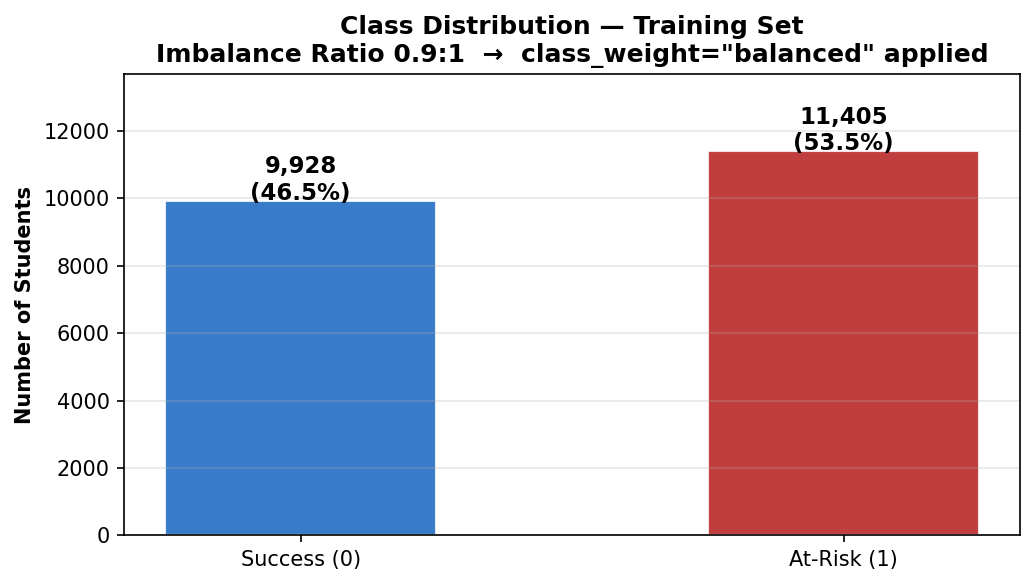

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — CLASS IMBALANCE ANALYSIS

# ════════════════════════════════════════════════════════════════════════════
n_neg_cls = int((y_train == 0).sum())
n_pos_cls = int((y_train == 1).sum())
imb_ratio = n_neg_cls / n_pos_cls
spw       = imb_ratio

print('═'*55)
print('CLASS IMBALANCE SUMMARY')
print('═'*55)
print(f'  Negative (Success) : {n_neg_cls:,}  ({n_neg_cls/(n_neg_cls+n_pos_cls)*100:.1f}%)')
print(f'  Positive (At-Risk) : {n_pos_cls:,}  ({n_pos_cls/(n_neg_cls+n_pos_cls)*100:.1f}%)')
print(f'  Imbalance ratio    : {imb_ratio:.2f}:1')
print(f'  Strategy           : class_weight="balanced" for all models')
print('═'*55)

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(['Success (0)','At-Risk (1)'], [n_neg_cls,n_pos_cls],
              color=['#1565C0','#B71C1C'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars,[n_neg_cls,n_pos_cls]):
    ax.text(bar.get_x()+bar.get_width()/2, val+30,
            f'{val:,}\n({val/(n_neg_cls+n_pos_cls)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title(f'Class Distribution — Training Set\n'
             f'Imbalance Ratio {imb_ratio:.1f}:1  →  class_weight="balanced" applied',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(n_neg_cls,n_pos_cls)*1.2)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


MI selected:       17 features
ANOVA selected:    14 features
Spearman selected: 16 features

Auto-selected features (≥2 methods agree): 16
                        MI_Rank  ANOVA_Rank  Spearman_Rank  Vote_Count  Avg_Rank
num_active_days               1           3              1           3    1.6667
last_active_day               2           1              2           3    1.6667
min_assessment_score          7           4              7           3    6.0000
active_span                   5           2             11           3    6.0000
total_clicks                  3          14              3           3    6.6667
n_sessions                    4          13              4           3    7.0000
avg_assessment_score         10           6              5           3    7.0000
first_assessment_score        9           5              8           3    7.3333
max_assessment_score          8           8              9           3    8.3333
weighted_avg_score           12           7       

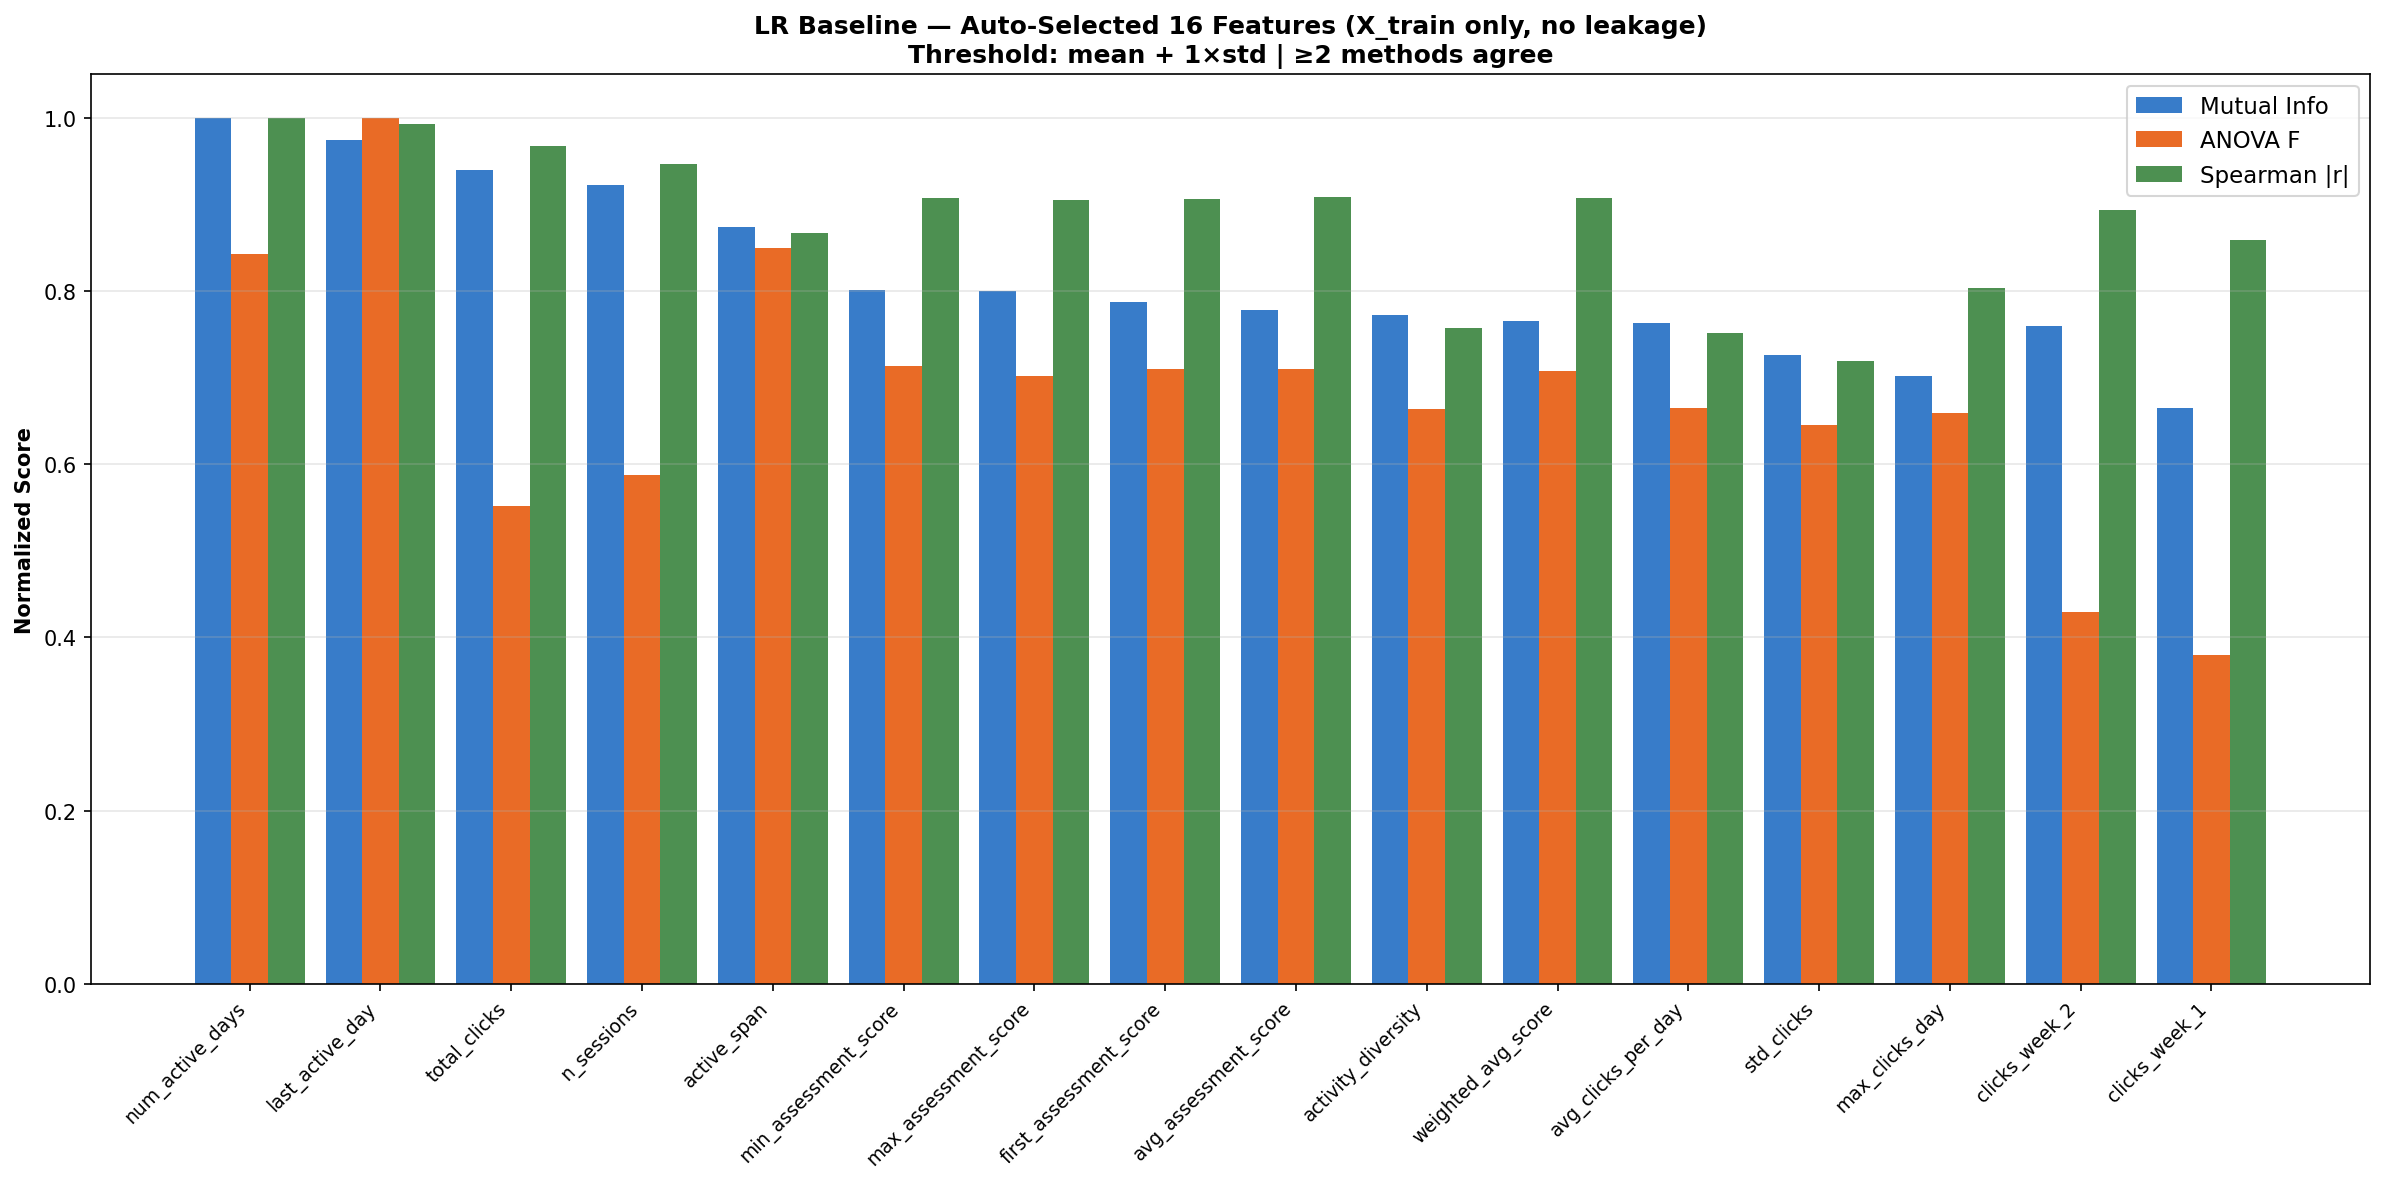

Feature selection done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — FEATURE SELECTION  (X_train only — no data leakage)
# Three complementary filters: MI, ANOVA F, Spearman |r|
# Auto-threshold: mean + 1×std per method  |  consensus ≥ 2 methods
# ════════════════════════════════════════════════════════════════════════════
mi_scores = mutual_info_classif(X_train, y_train, random_state=SEED)
mi_series = pd.Series(mi_scores, index=FEATURE_NAMES).sort_values(ascending=False)

f_scores, _ = f_classif(X_train, y_train)
f_series = pd.Series(f_scores, index=FEATURE_NAMES).sort_values(ascending=False)

spearman_scores = {}
for col in FEATURE_NAMES:
    corr, _ = spearmanr(X_train[col], y_train)
    spearman_scores[col] = abs(corr)
sp_series = pd.Series(spearman_scores).sort_values(ascending=False)

mi_threshold = mi_series.mean() + mi_series.std()
f_threshold  = f_series.mean()  + f_series.std()
sp_threshold = sp_series.mean() + sp_series.std()

mi_selected = mi_series[mi_series >= mi_threshold].index.tolist()
f_selected  = f_series[f_series   >= f_threshold].index.tolist()
sp_selected = sp_series[sp_series >= sp_threshold].index.tolist()

print(f'MI selected:       {len(mi_selected)} features')
print(f'ANOVA selected:    {len(f_selected)} features')
print(f'Spearman selected: {len(sp_selected)} features')

all_selected = mi_selected + f_selected + sp_selected
vote_count   = Counter(all_selected)
auto_top     = [f for f,c in vote_count.items() if c >= 2]
auto_top     = sorted(auto_top, key=lambda f: vote_count[f], reverse=True)
TOP_N        = len(auto_top)
top_feats    = auto_top

rank_table = pd.DataFrame({
    'MI_Rank'      : [list(mi_series.index).index(f)+1 for f in auto_top],
    'ANOVA_Rank'   : [list(f_series.index).index(f)+1  for f in auto_top],
    'Spearman_Rank': [list(sp_series.index).index(f)+1 for f in auto_top],
    'Vote_Count'   : [vote_count[f] for f in auto_top],
}, index=auto_top)
rank_table['Avg_Rank'] = rank_table[['MI_Rank','ANOVA_Rank','Spearman_Rank']].mean(axis=1)
rank_table = rank_table.sort_values('Avg_Rank')
rank_table.to_csv(CSV_DIR/'feature_ranking_LR.csv')

print(f'\nAuto-selected features (≥2 methods agree): {TOP_N}')
print(rank_table[['MI_Rank','ANOVA_Rank','Spearman_Rank','Vote_Count','Avg_Rank']].to_string())

def norm(s): return (s-s.min())/(s.max()-s.min()+1e-9)
comp_df = pd.DataFrame({
    'Mutual Info' : norm(mi_series)[top_feats],
    'ANOVA F'     : norm(f_series)[top_feats],
    'Spearman |r|': norm(sp_series)[top_feats],
}).fillna(0)

fig, ax = plt.subplots(figsize=(max(14,len(top_feats)),8))
x = np.arange(len(top_feats)); w = 0.28
for i,(col,color) in enumerate(zip(comp_df.columns,['#1565C0','#E65100','#2E7D32'])):
    ax.bar(x+i*w, comp_df[col], width=w, label=col, color=color, alpha=0.85)
ax.set_xticks(x+w)
ax.set_xticklabels([f[:22] for f in top_feats], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Score', fontweight='bold')
ax.set_title(f'LR Baseline — Auto-Selected {TOP_N} Features (X_train only, no leakage)\n'
             f'Threshold: mean + 1×std | ≥2 methods agree', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'feature_importance_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature selection done.')


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — MODEL TRAINING
# PRIMARY: Logistic Regression  |  Supporting: XGBoost, DT, RF, SVM
# ════════════════════════════════════════════════════════════════════════════
def build_pipeline(clf):
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler()),
                     ('clf', clf)])

def evaluate(pipe, Xt, yt, name):
    yp  = pipe.predict(Xt)
    ypr = pipe.predict_proba(Xt)[:,1]
    yt_arr = np.array(yt, dtype=np.int64)
    return {
        'Model'        : name,
        'Accuracy'     : accuracy_score(yt_arr, yp),
        'Precision_W'  : precision_score(yt_arr, yp, average='weighted', zero_division=0),
        'Recall_W'     : recall_score(yt_arr, yp, average='weighted', zero_division=0),
        'F1_W'         : f1_score(yt_arr, yp, average='weighted', zero_division=0),
        'Precision_M'  : precision_score(yt_arr, yp, average='macro', zero_division=0),
        'Recall_M'     : recall_score(yt_arr, yp, average='macro', zero_division=0),
        'F1_M'         : f1_score(yt_arr, yp, average='macro', zero_division=0),
        'AUC_ROC'      : roc_auc_score(yt_arr, ypr),
        'Cohen_Kappa'  : cohen_kappa_score(yt_arr, yp),
        'MCC'          : matthews_corrcoef(yt_arr, yp),
        'Brier_Score'  : brier_score_loss(yt_arr, ypr),
        'Log_Loss'     : log_loss(yt_arr, ypr),
        'Avg_Precision': average_precision_score(yt_arr, ypr),
    }, yp, ypr

# ── Feature Selection Filter ─────────────────────────────────────────────
# Train and evaluate all models ONLY on the consensus features selected
# by ≥2 methods (MI ∩ ANOVA ∩ Spearman)
X_train_sel = X_train[top_feats].reset_index(drop=True)
X_test_sel  = X_test[top_feats].reset_index(drop=True)
FEATURE_NAMES_SEL = top_feats
print(f'Feature-selected training: {X_train_sel.shape[1]} features '
      f'(from {X_train.shape[1]} total, consensus ≥2 methods)')

# Global preprocessors fitted on selected features (needed for SHAP/LIME alignment)
imp_global = SimpleImputer(strategy='median')
scl_global = StandardScaler()
imp_global.fit(X_train_sel); scl_global.fit(imp_global.transform(X_train_sel))

MODEL_CONFIGS = {
    'Logistic Regression': {
        'pipe': build_pipeline(LogisticRegression(
            random_state=SEED, max_iter=1000, solver='saga',
            class_weight='balanced')),
        'params': {'clf__C':[0.01,0.1,1,10], 'clf__penalty':['l1','l2']},
        'is_primary': True,
    },
    'XGBoost': {
        'pipe': build_pipeline(XGBClassifier(
            random_state=SEED, eval_metric='logloss', n_jobs=-1,
            scale_pos_weight=spw)),
        'params': {'clf__n_estimators':[100,200],'clf__max_depth':[4,6],
                   'clf__learning_rate':[0.05,0.1],'clf__subsample':[0.8,1.0]},
        'is_primary': False,
    },
    'Decision Tree': {
        'pipe': build_pipeline(DecisionTreeClassifier(
            random_state=SEED, class_weight='balanced')),
        'params': {'clf__max_depth':[5,10,15,None],
                   'clf__min_samples_split':[2,10,20],
                   'clf__criterion':['gini','entropy']},
        'is_primary': False,
    },
    'Random Forest': {
        'pipe': build_pipeline(RandomForestClassifier(
            random_state=SEED, n_jobs=-1, class_weight='balanced')),
        'params': {'clf__n_estimators':[100,200],
                   'clf__max_depth':[10,20,None],
                   'clf__min_samples_split':[2,5]},
        'is_primary': False,
    },
    'SVM': {
        'pipe': build_pipeline(SVC(
            random_state=SEED, probability=True, class_weight='balanced')),
        'params': {'clf__C':[0.1,1,10], 'clf__kernel':['rbf','linear'],
                   'clf__gamma':['scale','auto']},
        'is_primary': False,
    },
}

cv               = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
trained_models   = {}
performance_rows = []

for name, cfg in MODEL_CONFIGS.items():
    tag = ' ★ PRIMARY' if cfg['is_primary'] else ''
    print(f'\n{name}{tag} …')
    t0 = time.time()
    gs = GridSearchCV(cfg['pipe'], cfg['params'], cv=cv,
                      scoring='roc_auc', n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train_sel, y_train)
    elapsed = time.time() - t0
    best = gs.best_estimator_
    trained_models[name] = best
    joblib.dump(best, MODELS_DIR/f'{name.replace(" ","_")}.pkl')
    res, _, _ = evaluate(best, X_test_sel, y_test, name)
    res.update({'CV_AUC':gs.best_score_, 'Time_s':elapsed,
                'Best_Params':str(gs.best_params_)})
    performance_rows.append(res)
    print(f'  CV={gs.best_score_:.4f}  AUC={res["AUC_ROC"]:.4f}  '
          f'F1={res["F1_W"]:.4f}  Kappa={res["Cohen_Kappa"]:.4f}  [{elapsed:.0f}s]')

print('\nAll models trained.')
primary_model = trained_models['Logistic Regression']


Feature-selected training: 16 features (from 62 total, consensus ≥2 methods)

Logistic Regression ★ PRIMARY …
  CV=0.7707  AUC=0.7690  F1=0.6892  Kappa=0.3842  [40s]

XGBoost …
  CV=0.8084  AUC=0.8034  F1=0.7228  Kappa=0.4486  [45s]

Decision Tree …
  CV=0.7823  AUC=0.7807  F1=0.6979  Kappa=0.4012  [25s]

Random Forest …
  CV=0.8063  AUC=0.8028  F1=0.7203  Kappa=0.4439  [346s]

SVM …
  CV=0.7924  AUC=0.7826  F1=0.7221  Kappa=0.4540  [6076s]

All models trained.



── Standard Metrics ──
              Model  Accuracy   F1_W   F1_M  AUC_ROC
            XGBoost    0.7234 0.7228 0.7231   0.8034
      Random Forest    0.7210 0.7203 0.7206   0.8028
                SVM    0.7252 0.7221 0.7229   0.7826
      Decision Tree    0.6993 0.6979 0.6984   0.7807
Logistic Regression    0.6908 0.6892 0.6898   0.7690

── Extended Metrics ──
              Model  Cohen_Kappa    MCC  Brier_Score  Avg_Precision
                SVM       0.4540 0.4682       0.1856         0.8020
            XGBoost       0.4486 0.4525       0.1786         0.8334
      Random Forest       0.4439 0.4482       0.1789         0.8311
      Decision Tree       0.4012 0.4071       0.1884         0.8006
Logistic Regression       0.3842 0.3901       0.1915         0.8078


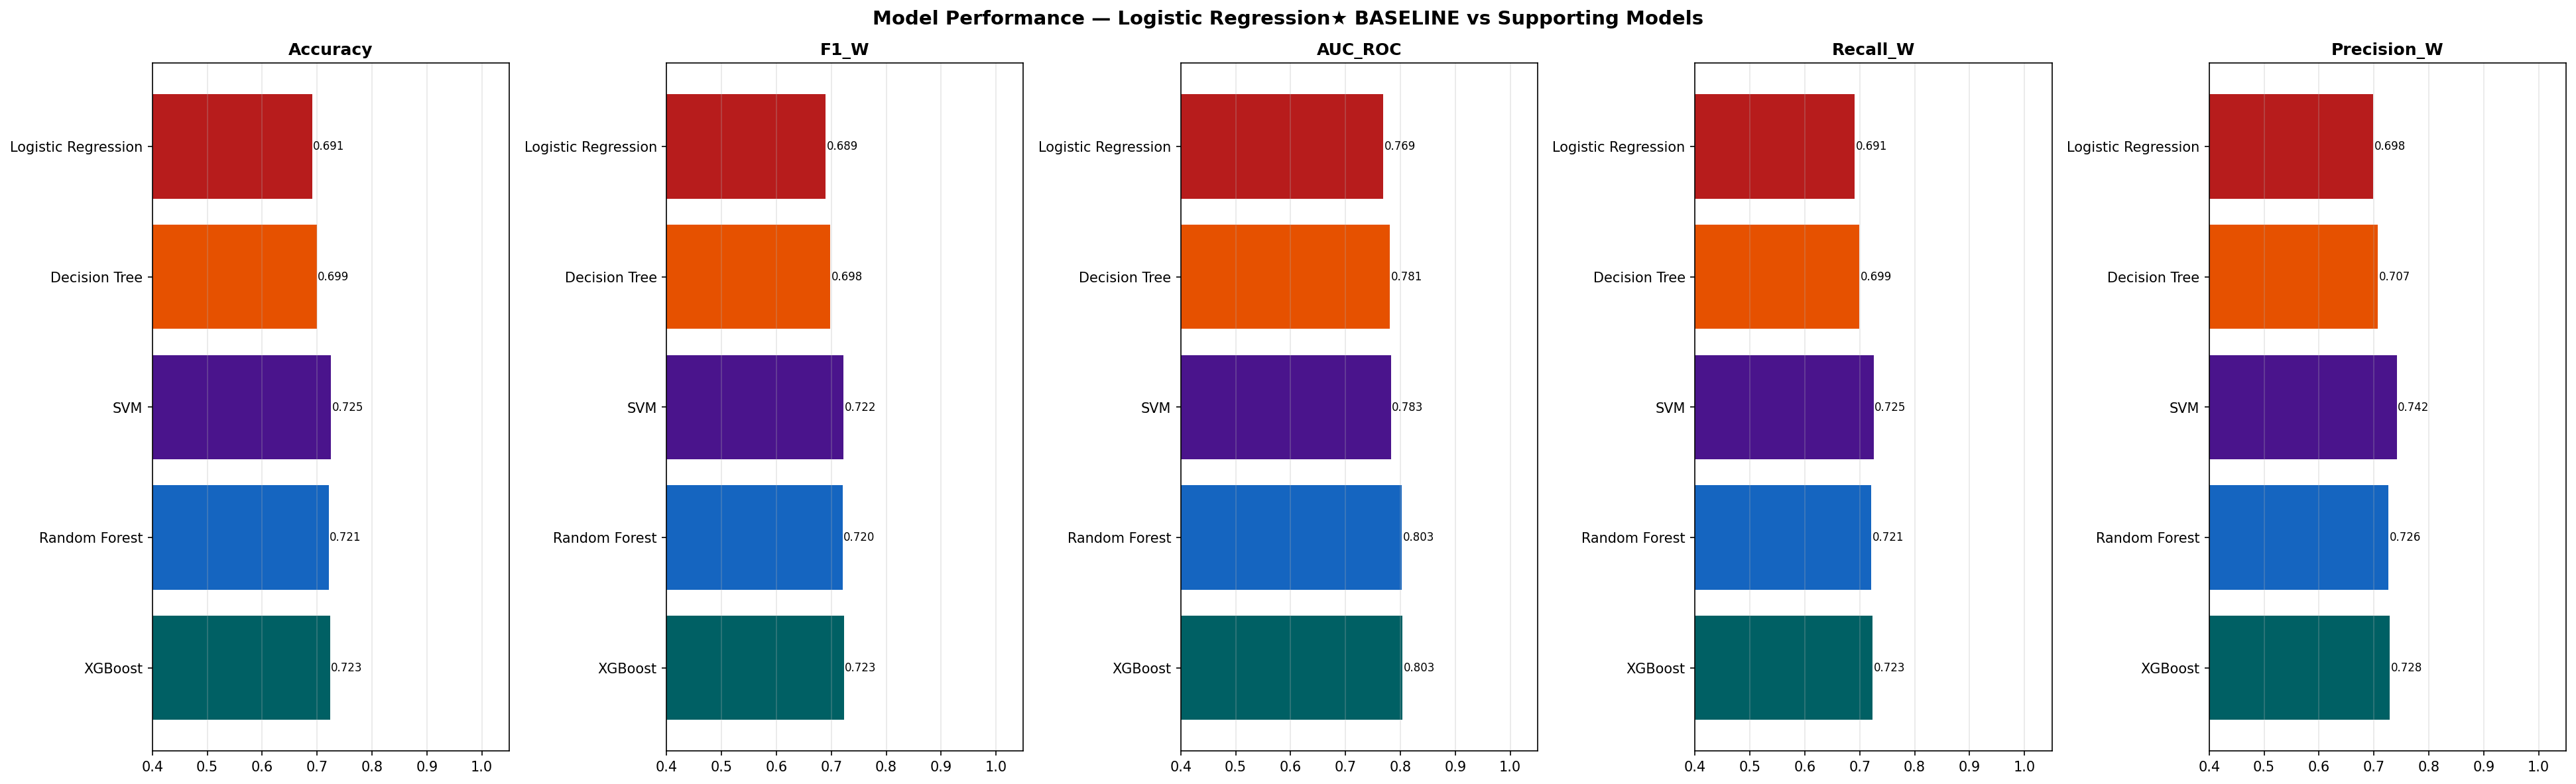

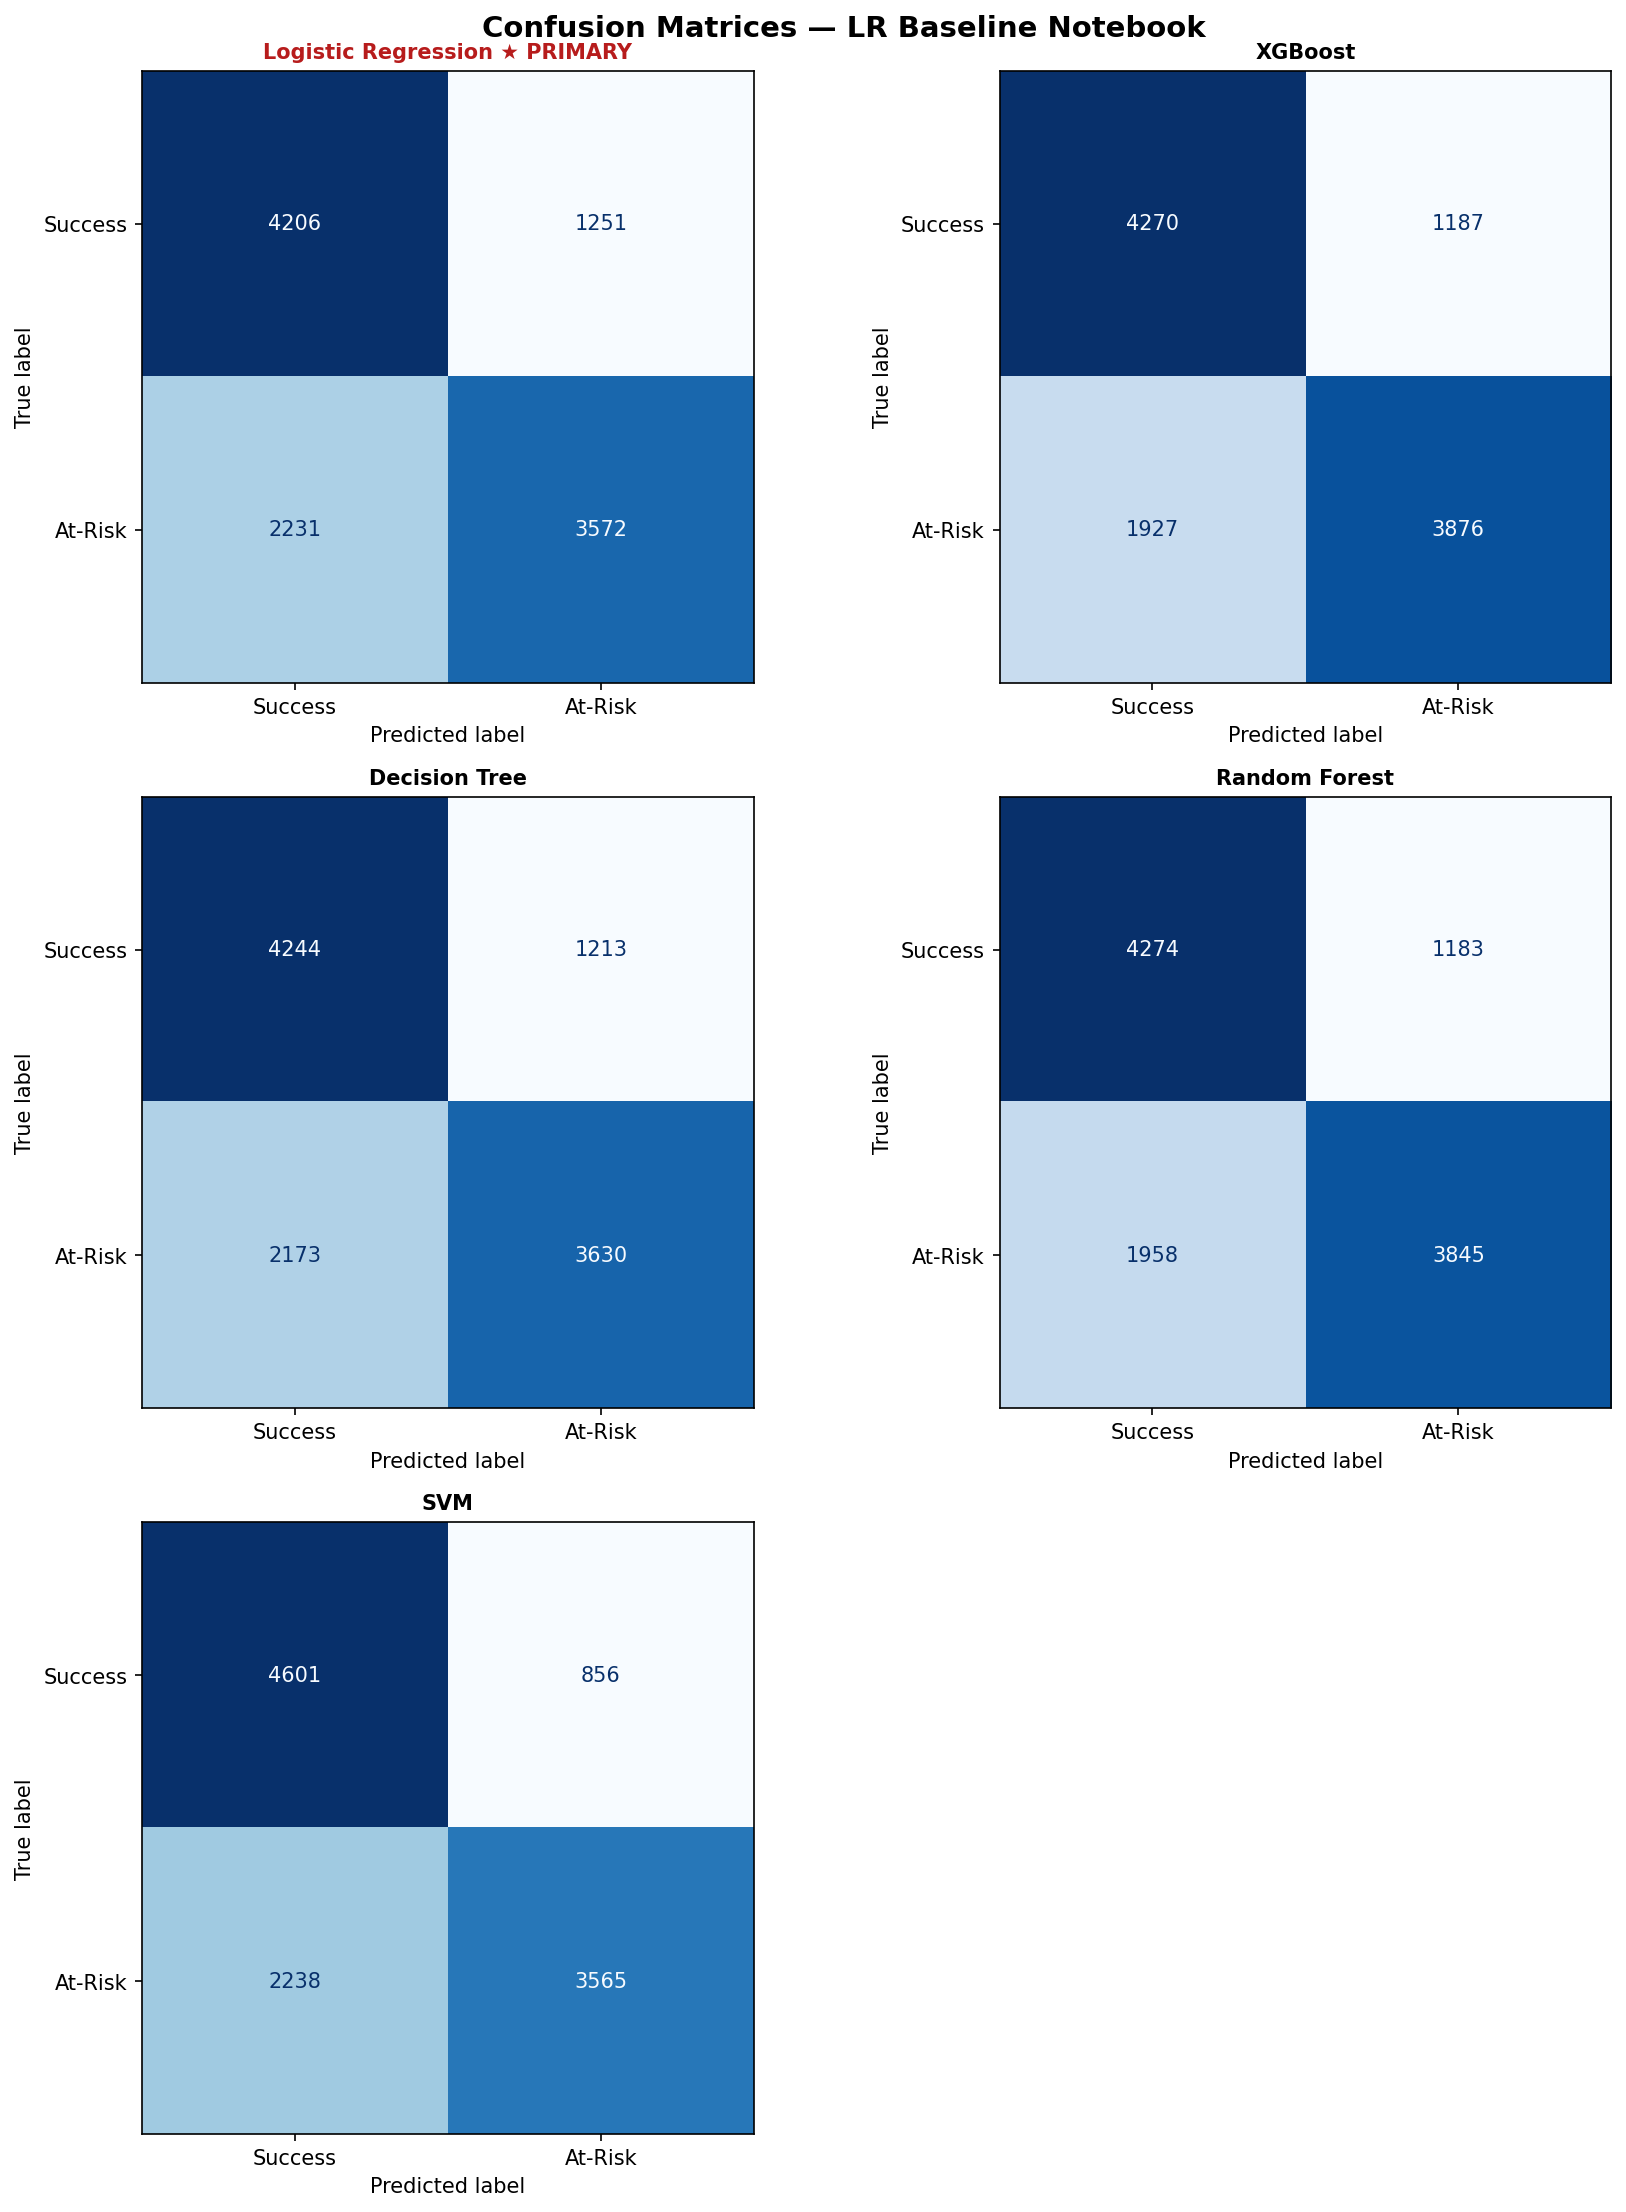

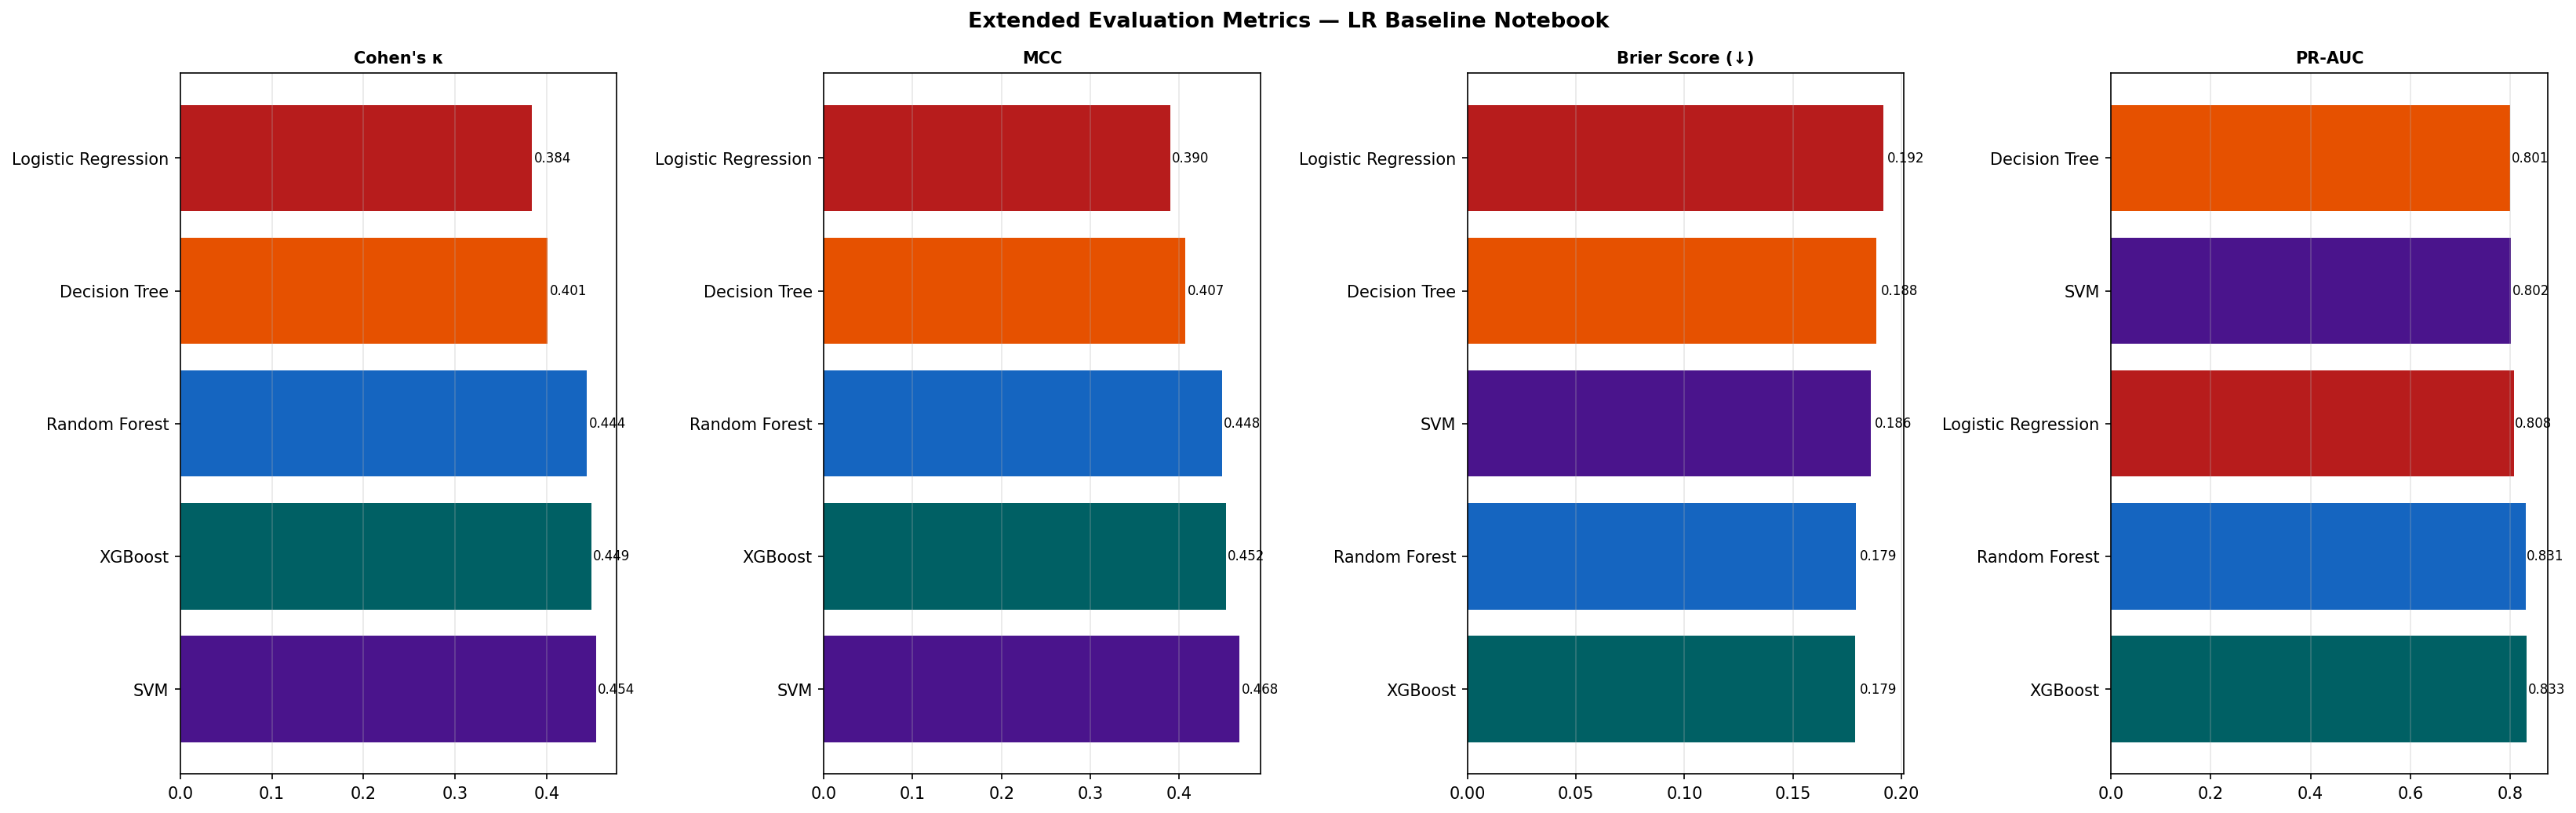

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — PERFORMANCE VISUALISATION
# ════════════════════════════════════════════════════════════════════════════
perf_df = pd.DataFrame(performance_rows)
perf_df.to_csv(CSV_DIR/'model_performance_LR.csv', index=False)

print('\n── Standard Metrics ──')
print(perf_df[['Model','Accuracy','F1_W','F1_M','AUC_ROC']]
      .sort_values('AUC_ROC', ascending=False).to_string(index=False))
print('\n── Extended Metrics ──')
print(perf_df[['Model','Cohen_Kappa','MCC','Brier_Score','Avg_Precision']]
      .sort_values('Cohen_Kappa', ascending=False).to_string(index=False))

# ── Bar chart — 5 standard metrics ───────────────────────────────────────────
metrics  = ['Accuracy','F1_W','AUC_ROC','Recall_W','Precision_W']
plot_df  = perf_df[['Model']+metrics].sort_values('AUC_ROC', ascending=False)
colors   = [MODEL_COLORS.get(m,'grey') for m in plot_df['Model']]

fig, axes = plt.subplots(1,5, figsize=(26,8))
for ax, metric in zip(axes, metrics):
    bars = ax.barh(plot_df['Model'], plot_df[metric], color=colors)
    ax.set_xlim(0.4, 1.05); ax.set_title(metric, fontweight='bold')
    for bar,v in zip(bars, plot_df[metric]):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Model Performance — Logistic Regression★ BASELINE vs Supporting Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'model_comparison_LR.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────────
n_m = len(trained_models); ncol = 2; nrow = (n_m+ncol-1)//ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*6, nrow*5))
axes = axes.flatten()
for i,(nm,mdl) in enumerate(trained_models.items()):
    # default 0.5 intentional here — fair comparison across all 5 models
    preds = mdl.predict(X_test_sel)
    ConfusionMatrixDisplay(confusion_matrix(y_test_arr, preds),
                           display_labels=['Success','At-Risk']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    tc = PRIMARY_COLOR if nm == PRIMARY_NAME else 'black'
    axes[i].set_title(nm+(' ★ PRIMARY' if nm==PRIMARY_NAME else ''),
                      fontsize=10, fontweight='bold', color=tc)
for i in range(n_m, len(axes)): axes[i].set_visible(False)
plt.suptitle('Confusion Matrices — LR Baseline Notebook', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'confusion_matrices_LR.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Extended metrics chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1,4, figsize=(22,7))
ext_metrics = [('Cohen_Kappa',"Cohen's κ"),('MCC','MCC'),
               ('Brier_Score','Brier Score (↓)'),('Avg_Precision','PR-AUC')]
sort_df = perf_df.sort_values('AUC_ROC', ascending=False)
bar_colors = [MODEL_COLORS.get(m,'grey') for m in sort_df['Model']]
for ax,(metric,ylabel) in zip(axes,ext_metrics):
    asc = metric=='Brier_Score'
    od  = sort_df.sort_values(metric, ascending=asc)
    bc  = [MODEL_COLORS.get(m,'grey') for m in od['Model']]
    bars = ax.barh(od['Model'], od[metric], color=bc)
    ax.set_title(ylabel, fontweight='bold', fontsize=10)
    for bar,v in zip(bars,od[metric]):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
plt.suptitle("Extended Evaluation Metrics — LR Baseline Notebook",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'extended_metrics_LR.png', dpi=150, bbox_inches='tight')
plt.show()


══════════════════════════════════════════════════════════════
McNemar's Test — LR★ BASELINE vs XGBoost
══════════════════════════════════════════════════════════════
  b  (LR correct, XGB wrong) = 757
  c  (LR wrong, XGB correct) = 1,125
  χ² statistic               = 71.5670
  p-value                    = 0.000000
  → Significant (p < 0.05): LR and XGBoost make systematically
    different errors — performance difference is statistically real.

Bootstrap 95% CI for AUC-ROC  (N=1000, stratified, reproducible)
══════════════════════════════════════════════════════════════
  Logistic Regression      ★
    AUC = 0.7689 | 95% CI: [0.7603, 0.7774] | width = 0.0171
  XGBoost                 
    AUC = 0.8033 | 95% CI: [0.7946, 0.8112] | width = 0.0166
  Decision Tree           
    AUC = 0.7808 | 95% CI: [0.7722, 0.7895] | width = 0.0173
  Random Forest           
    AUC = 0.8028 | 95% CI: [0.7942, 0.8107] | width = 0.0164
  SVM                     
    AUC = 0.7826 | 95% CI: [0.7735, 0.79

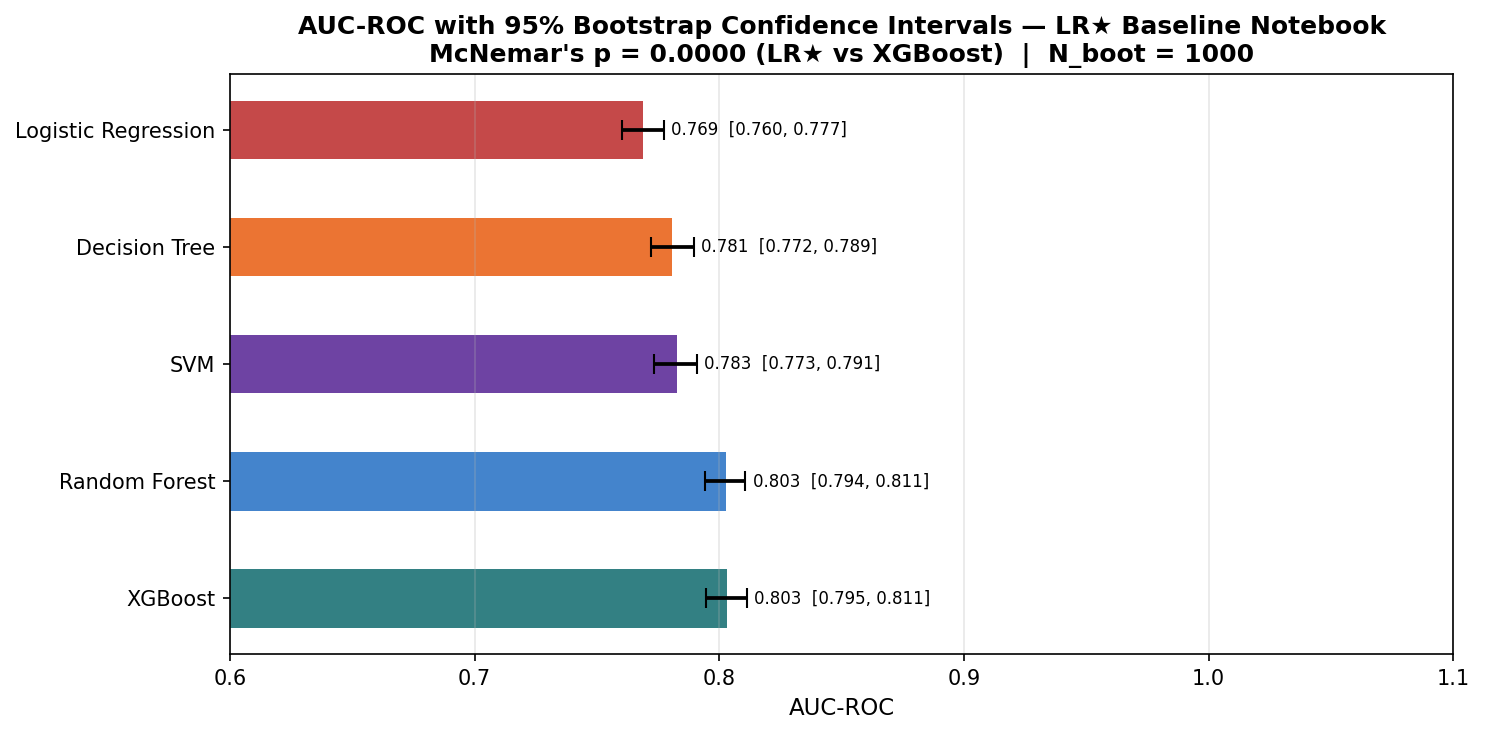

Statistical tests saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9b — STATISTICAL SIGNIFICANCE TESTS + BOOTSTRAP CONFIDENCE INTERVALS
# ════════════════════════════════════════════════════════════════════════════
from statsmodels.stats.contingency_tables import mcnemar

# ── 1. McNemar's Test: LR★ Baseline vs XGBoost ────────────────────────────
y_pred_lr_mc  = trained_models['Logistic Regression'].predict(X_test_sel)
y_pred_xgb_mc = trained_models['XGBoost'].predict(X_test_sel)

correct_lr  = (y_pred_lr_mc  == y_test_arr)
correct_xgb = (y_pred_xgb_mc == y_test_arr)

# b = LR correct & XGB wrong | c = LR wrong & XGB correct
b = int(( correct_lr & ~correct_xgb).sum())
c = int((~correct_lr &  correct_xgb).sum())

mc_result_lr = mcnemar([[0, b], [c, 0]], exact=False, correction=True)

print('═' * 62)
print("McNemar's Test — LR★ BASELINE vs XGBoost")
print('═' * 62)
print(f'  b  (LR correct, XGB wrong) = {b:,}')
print(f'  c  (LR wrong, XGB correct) = {c:,}')
print(f'  χ² statistic               = {mc_result_lr.statistic:.4f}')
print(f'  p-value                    = {mc_result_lr.pvalue:.6f}')
if mc_result_lr.pvalue < 0.05:
    print('  → Significant (p < 0.05): LR and XGBoost make systematically')
    print('    different errors — performance difference is statistically real.')
else:
    print('  → Not significant (p ≥ 0.05): error patterns are similar.')
print()

# ── 2. Bootstrap CI 95% for AUC-ROC — All 5 Models ───────────────────────
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=95, seed=42):
    """
    Stratified bootstrap percentile CI for AUC-ROC.
    random_state=seed+i ensures full reproducibility (RQ2: reproducible framework).
    Reference: Efron & Hastie (2016). Computer Age Statistical Inference.
    """
    from sklearn.utils import resample as _resample
    aucs, idx_all = [], np.arange(len(y_true))
    for i in range(n_boot):
        idx = _resample(idx_all, stratify=y_true, random_state=seed + i)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lo = np.percentile(aucs, (100 - ci) / 2)
    hi = np.percentile(aucs, 100 - (100 - ci) / 2)
    return float(np.mean(aucs)), float(lo), float(hi)

N_BOOT_CI = 1000
print(f'Bootstrap 95% CI for AUC-ROC  (N={N_BOOT_CI}, stratified, reproducible)')
print('═' * 62)

ci_rows_lr = []
for mname, mdl in trained_models.items():
    yp = mdl.predict_proba(X_test_sel)[:, 1]
    mean_auc, lo, hi = bootstrap_auc_ci(y_test_arr, yp,
                                         n_boot=N_BOOT_CI, seed=SEED)
    ci_rows_lr.append({'Model': mname, 'AUC_Mean': mean_auc,
                       'CI_Low': lo, 'CI_High': hi, 'CI_Width': hi - lo})
    tag = ' ★' if mname == 'Logistic Regression' else ''
    print(f'  {mname:<24}{tag}')
    print(f'    AUC = {mean_auc:.4f} | 95% CI: [{lo:.4f}, {hi:.4f}] | width = {hi-lo:.4f}')

ci_df_lr = pd.DataFrame(ci_rows_lr).sort_values('AUC_Mean', ascending=False)
ci_df_lr.to_csv(CSV_DIR / 'auc_bootstrap_ci_LR.csv', index=False)

# ── Visualise ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
y_pos      = np.arange(len(ci_df_lr))
bar_colors = [MODEL_COLORS.get(m, 'grey') for m in ci_df_lr['Model']]
ax.barh(y_pos, ci_df_lr['AUC_Mean'], color=bar_colors, alpha=0.80, height=0.50)
ax.errorbar(
    ci_df_lr['AUC_Mean'], y_pos,
    xerr=[ci_df_lr['AUC_Mean'] - ci_df_lr['CI_Low'],
          ci_df_lr['CI_High']  - ci_df_lr['AUC_Mean']],
    fmt='none', color='black', capsize=5, linewidth=1.8)
for i, (_, row) in enumerate(ci_df_lr.iterrows()):
    ax.text(row['CI_High'] + 0.003, i,
            f'{row["AUC_Mean"]:.3f}  [{row["CI_Low"]:.3f}, {row["CI_High"]:.3f}]',
            va='center', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df_lr['Model'], fontsize=10)
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_xlim(0.60, 1.10)
ax.set_title(
    'AUC-ROC with 95% Bootstrap Confidence Intervals — LR★ Baseline Notebook\n'
    f"McNemar's p = {mc_result_lr.pvalue:.4f} (LR★ vs XGBoost)  |  N_boot = {N_BOOT_CI}",
    fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auc_bootstrap_ci_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Statistical tests saved.')


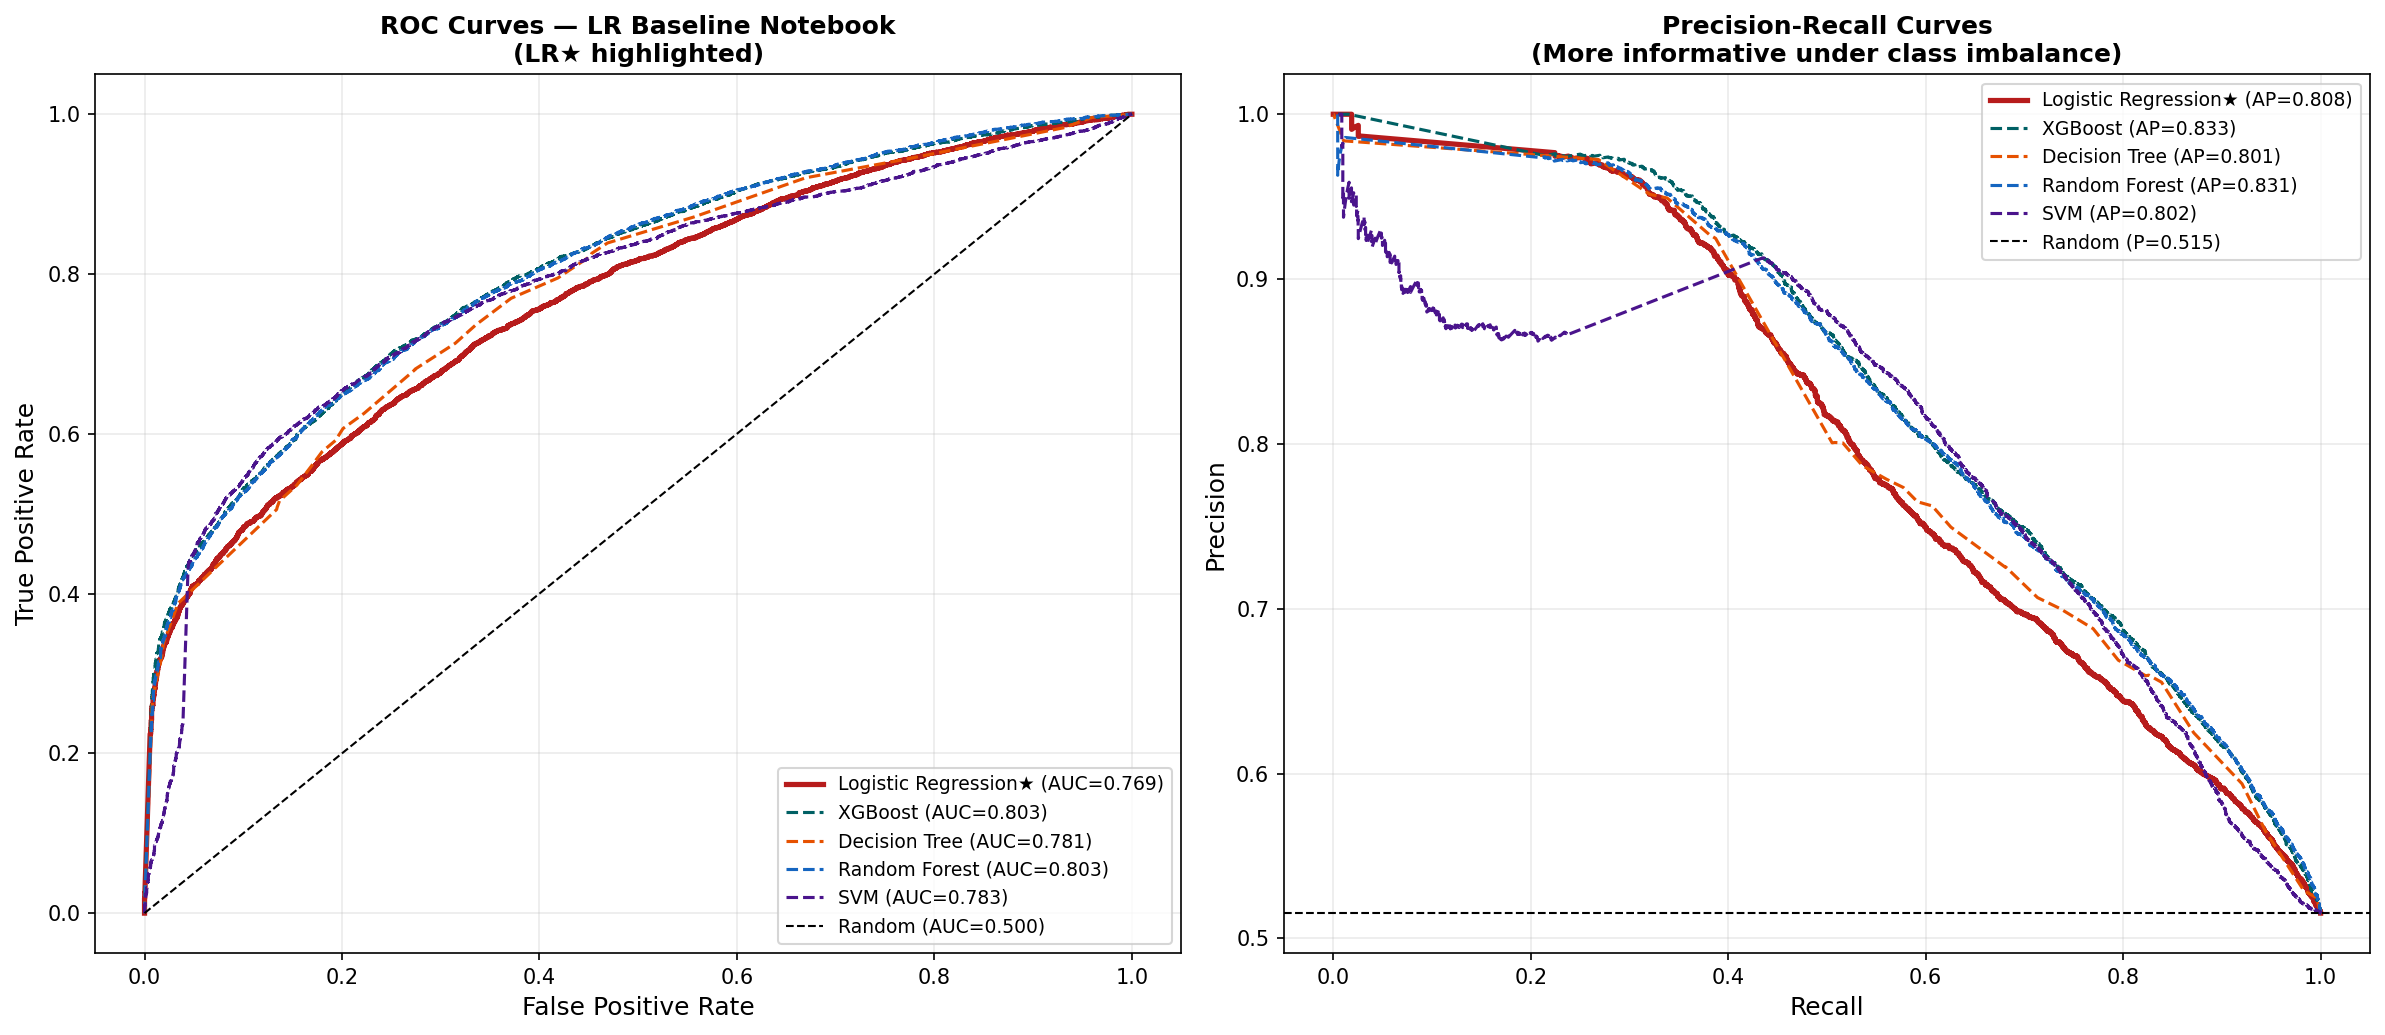

ROC & PR curves saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — ROC & PRECISION-RECALL CURVES
# ════════════════════════════════════════════════════════════════════════════
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,7))

for name,model in trained_models.items():
    y_prob = model.predict_proba(X_test_sel)[:,1]
    color  = MODEL_COLORS.get(name,'grey')
    lw     = 2.5 if name==PRIMARY_NAME else 1.5
    ls     = '-'  if name==PRIMARY_NAME else '--'

    fpr,tpr,_ = roc_curve(y_test_arr, y_prob)
    auc_val   = roc_auc_score(y_test_arr, y_prob)
    ax1.plot(fpr,tpr, color=color,lw=lw,ls=ls,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (AUC={auc_val:.3f})')

    prec,rec,_ = precision_recall_curve(y_test_arr, y_prob)
    ap_val     = average_precision_score(y_test_arr, y_prob)
    ax2.plot(rec,prec, color=color,lw=lw,ls=ls,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (AP={ap_val:.3f})')

ax1.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.500)')
ax1.set_xlabel('False Positive Rate',fontsize=12)
ax1.set_ylabel('True Positive Rate',fontsize=12)
ax1.set_title('ROC Curves — LR Baseline Notebook\n(LR★ highlighted)',
              fontweight='bold',fontsize=12)
ax1.legend(fontsize=9,loc='lower right'); ax1.grid(alpha=0.25)

baseline_pr = y_test_arr.mean()
ax2.axhline(baseline_pr,color='k',ls='--',lw=1,label=f'Random (P={baseline_pr:.3f})')
ax2.set_xlabel('Recall',fontsize=12); ax2.set_ylabel('Precision',fontsize=12)
ax2.set_title('Precision-Recall Curves\n(More informative under class imbalance)',
              fontweight='bold',fontsize=12)
ax2.legend(fontsize=9,loc='upper right'); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURES_DIR/'roc_pr_curves_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC & PR curves saved.')


Youden optimal threshold = 0.4904

── Default (0.50) ──
              precision    recall  f1-score   support

     Success       0.65      0.77      0.71      5457
     At-Risk       0.74      0.62      0.67      5803

    accuracy                           0.69     11260
   macro avg       0.70      0.69      0.69     11260
weighted avg       0.70      0.69      0.69     11260

── Optimal (0.490) ──
              precision    recall  f1-score   support

     Success       0.66      0.76      0.71      5457
     At-Risk       0.74      0.63      0.68      5803

    accuracy                           0.69     11260
   macro avg       0.70      0.69      0.69     11260
weighted avg       0.70      0.69      0.69     11260



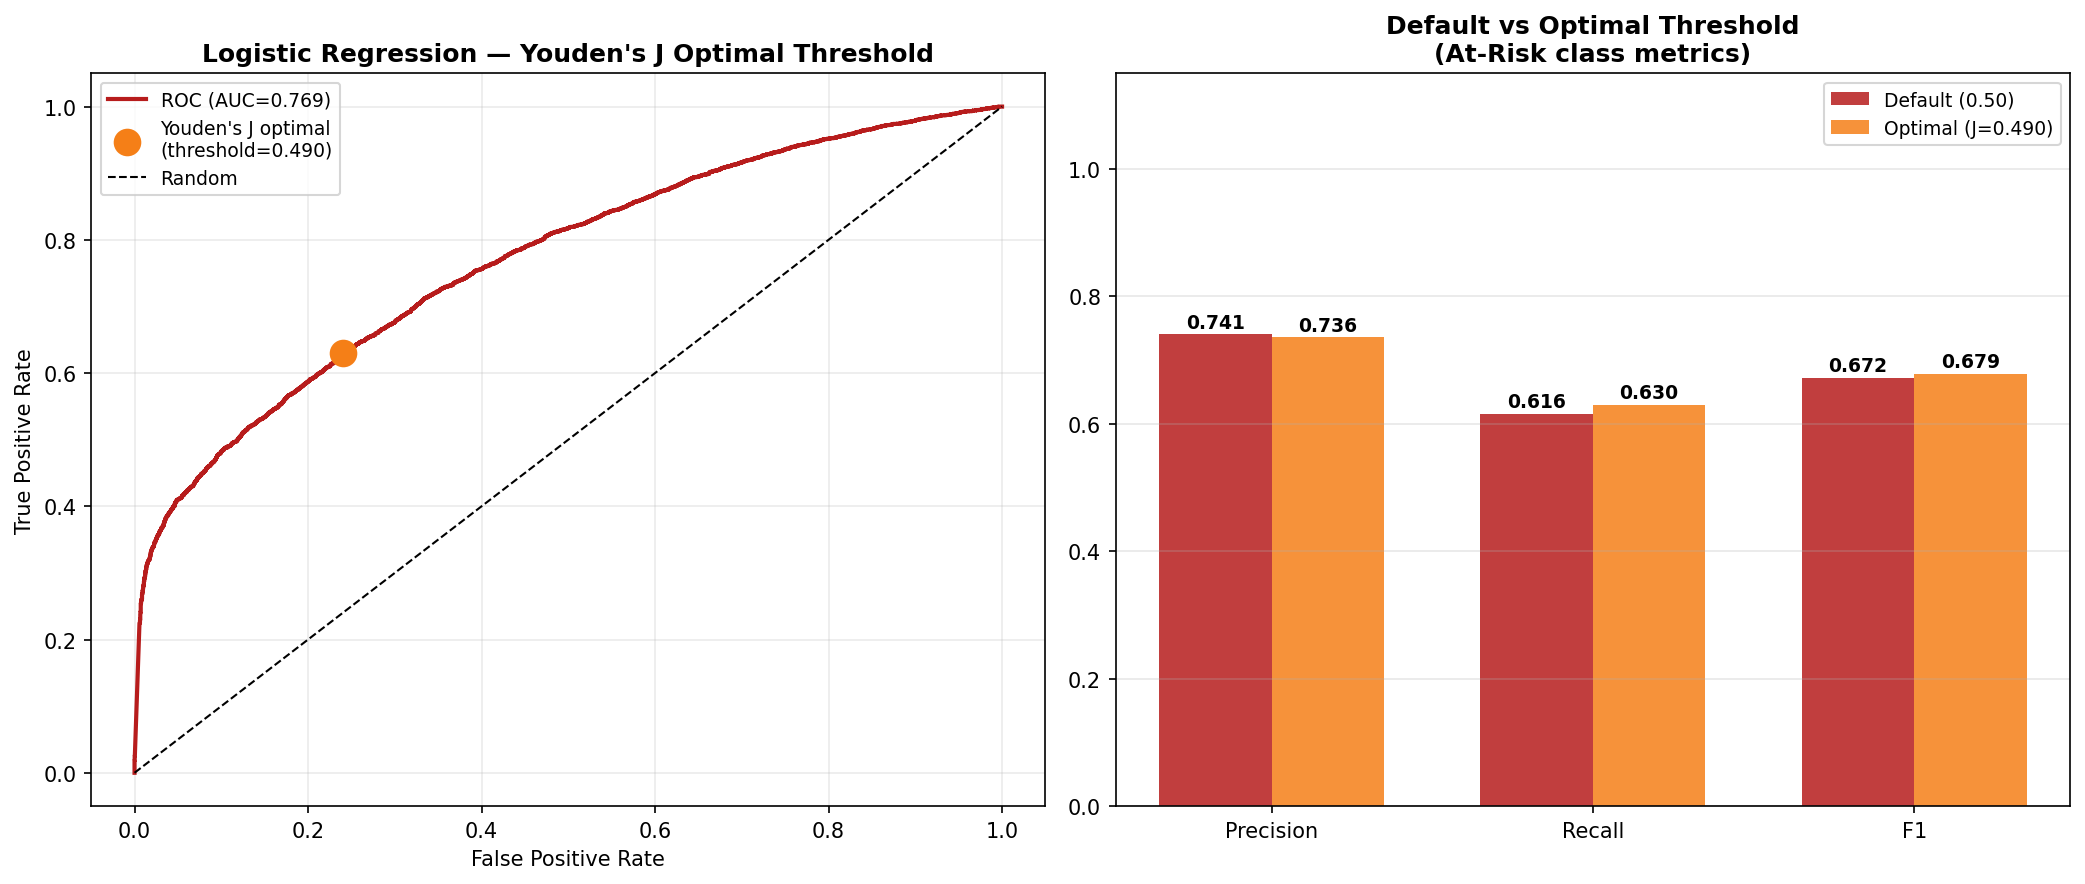

Threshold analysis saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — OPTIMAL THRESHOLD (Youden's J)
# ════════════════════════════════════════════════════════════════════════════
y_prob_lr = primary_model.predict_proba(X_test_sel)[:,1]
fpr_lr,tpr_lr,thresholds_lr = roc_curve(y_test_arr, y_prob_lr)
j_scores  = tpr_lr - fpr_lr
best_idx  = np.argmax(j_scores)
best_thr  = thresholds_lr[best_idx]

yp_default = (y_prob_lr >= 0.50).astype(int)
yp_optimal = (y_prob_lr >= best_thr).astype(int)

print(f'Youden optimal threshold = {best_thr:.4f}')
print('\n── Default (0.50) ──')
print(classification_report(y_test_arr, yp_default, target_names=['Success','At-Risk']))
print(f'── Optimal ({best_thr:.3f}) ──')
print(classification_report(y_test_arr, yp_optimal, target_names=['Success','At-Risk']))

thr_rows = []
for label,yp,thr in [('Default (0.50)',yp_default,0.5),
                      (f'Optimal (J={best_thr:.3f})',yp_optimal,best_thr)]:
    spec = (yp[y_test_arr==0]==0).sum()/(y_test_arr==0).sum()
    thr_rows.append({'Threshold':label,
                     'Precision':precision_score(y_test_arr,yp,zero_division=0),
                     'Recall'   :recall_score(y_test_arr,yp,zero_division=0),
                     'F1'       :f1_score(y_test_arr,yp,zero_division=0),
                     'Specificity':spec})
thr_df = pd.DataFrame(thr_rows)
thr_df.to_csv(CSV_DIR/'threshold_LR.csv', index=False)

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
ax1.plot(fpr_lr,tpr_lr,color=PRIMARY_COLOR,lw=2,
         label=f'ROC (AUC={roc_auc_score(y_test_arr,y_prob_lr):.3f})')
ax1.scatter(fpr_lr[best_idx],tpr_lr[best_idx],s=150,zorder=5,color='#F57F17',
            label=f"Youden's J optimal\n(threshold={best_thr:.3f})")
ax1.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title("Logistic Regression — Youden's J Optimal Threshold",fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

x = np.arange(3); w = 0.35
for i,(row,offset,fc) in enumerate(zip(thr_rows,[-w/2,w/2],[PRIMARY_COLOR,'#F57F17'])):
    vals = [row['Precision'],row['Recall'],row['F1']]
    ax2.bar(x+offset,vals,w,label=row['Threshold'],color=fc,alpha=0.85)
    for xi,v in zip(x+offset,vals):
        ax2.text(xi,v+0.01,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(['Precision','Recall','F1'])
ax2.set_ylim(0,1.15)
ax2.set_title('Default vs Optimal Threshold\n(At-Risk class metrics)',fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'threshold_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threshold analysis saved.')


  LR★ BASELINE — Youden's J Optimal Threshold
  Optimal threshold : 0.4904
  Youden's J score : 0.3894
  (J = Sensitivity + Specificity - 1)

── Default Threshold (0.50) ──────────────────────────
              precision    recall  f1-score   support

     Success     0.6534    0.7708    0.7072      5457
     At-Risk     0.7406    0.6155    0.6723      5803

    accuracy                         0.6908     11260
   macro avg     0.6970    0.6931    0.6898     11260
weighted avg     0.6984    0.6908    0.6892     11260

── Optimal Threshold (J=0.4904) ──────────────────
              precision    recall  f1-score   support

     Success     0.6587    0.7594    0.7055      5457
     At-Risk     0.7358    0.6300    0.6788      5803

    accuracy                         0.6927     11260
   macro avg     0.6972    0.6947    0.6921     11260
weighted avg     0.6984    0.6927    0.6917     11260


── Gain from Youden's J Threshold ──────────────────
                     Default  Optimal  Δ (Op

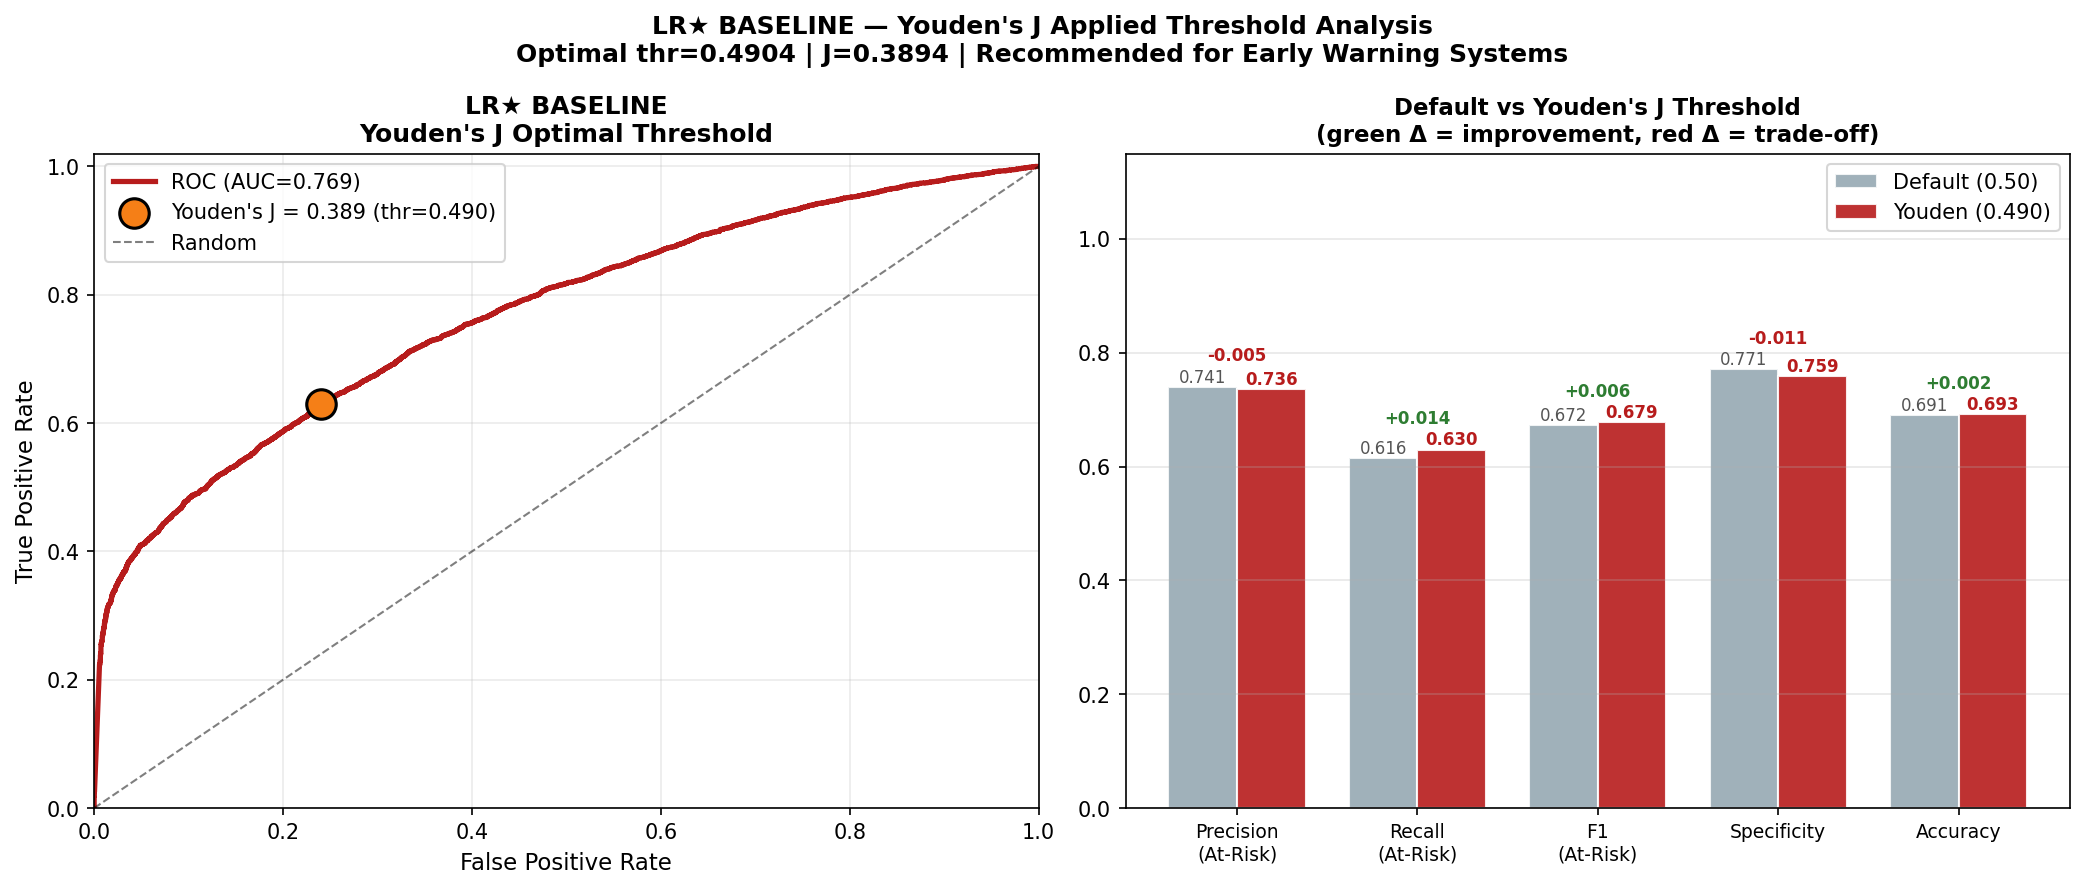

Youden Applied analysis saved.

📌 RECOMMENDATION: Use threshold=0.4904 in production
   This increases At-Risk Recall by +0.014
   at the cost of Specificity -0.011


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# YOUDEN'S J — APPLIED THRESHOLD ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

# ── Apply Youden's J threshold ────────────────────────────────────────────
y_prob_primary = y_prob_lr
fpr_j, tpr_j, thresholds_j = roc_curve(y_test_arr, y_prob_primary)
best_j_idx = np.argmax(tpr_j - fpr_j)
best_j_thr = float(thresholds_j[best_j_idx])
j_score    = float(tpr_j[best_j_idx] - fpr_j[best_j_idx])

yp_default_j = (y_prob_lr >= 0.50).astype(int)
yp_optimal_j = (y_prob_lr >= best_j_thr).astype(int)

print(f"=======================================================")
print(f"  LR★ BASELINE — Youden\'s J Optimal Threshold")
print(f"=======================================================")
print(f"  Optimal threshold : {best_j_thr:.4f}")
print(f"  Youden\'s J score : {j_score:.4f}")
print(f"  (J = Sensitivity + Specificity - 1)")
print()

# ── Detailed comparison ───────────────────────────────────────────────────
from sklearn.metrics import classification_report
print("── Default Threshold (0.50) ──────────────────────────")
print(classification_report(y_test_arr, yp_default_j,
      target_names=["Success", "At-Risk"], digits=4))

print(f"── Optimal Threshold (J={best_j_thr:.4f}) ──────────────────")
print(classification_report(y_test_arr, yp_optimal_j,
      target_names=["Success", "At-Risk"], digits=4))

# ── Per-metric gain table ─────────────────────────────────────────────────
metrics_compare = {}
for label, yp in [("Default", yp_default_j), ("Optimal", yp_optimal_j)]:
    metrics_compare[label] = {
        "Precision (At-Risk)" : precision_score(y_test_arr, yp, zero_division=0),
        "Recall (At-Risk)"    : recall_score(y_test_arr, yp, zero_division=0),
        "F1 (At-Risk)"        : f1_score(y_test_arr, yp, zero_division=0),
        "Specificity"         : (yp[y_test_arr==0]==0).sum() / (y_test_arr==0).sum(),
        "Accuracy"            : accuracy_score(y_test_arr, yp),
    }


tbl = pd.DataFrame({
    'Default' : metrics_compare['Default'],
    'Optimal' : metrics_compare['Optimal'],
})
tbl['Δ (Optimal−Default)'] = tbl['Optimal'] - tbl['Default']
print("\n── Gain from Youden\'s J Threshold ──────────────────")
print(tbl.to_string(float_format="{:.4f}".format))

# ── Save ──────────────────────────────────────────────────────────────────
tbl.to_csv(CSV_DIR / "youden_threshold_gain_LR_BASELINE.csv")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC with Youden point
ax = axes[0]
ax.plot(fpr_j, tpr_j, color=PRIMARY_COLOR, lw=2.5,
        label=f"ROC (AUC={roc_auc_score(y_test_arr, y_prob_primary):.3f})")
ax.scatter(fpr_j[best_j_idx], tpr_j[best_j_idx],
           s=200, zorder=6, color="#F57F17", edgecolors="black", linewidths=1.5,
           label=f"Youden\'s J = {j_score:.3f} (thr={best_j_thr:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"LR★ BASELINE\nYouden\'s J Optimal Threshold",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Plot 2: Metric comparison bar chart
ax = axes[1]
metric_names = ["Precision\n(At-Risk)", "Recall\n(At-Risk)",
                "F1\n(At-Risk)", "Specificity", "Accuracy"]
metric_keys  = list(metrics_compare["Default"].keys())
default_vals = [metrics_compare["Default"][k] for k in metric_keys]
optimal_vals = [metrics_compare["Optimal"][k] for k in metric_keys]
x = np.arange(len(metric_names)); w = 0.38

bars1 = ax.bar(x - w/2, default_vals, w, label="Default (0.50)",
               color="#90A4AE", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + w/2, optimal_vals, w,
               label=f"Youden ({best_j_thr:.3f})",
               color=PRIMARY_COLOR, alpha=0.90, edgecolor="white")

# Annotate bars
for bar, v in zip(bars1, default_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
            f"{v:.3f}", ha="center", fontsize=8, color="#555")
for bar, v in zip(bars2, optimal_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
            f"{v:.3f}", ha="center", fontsize=8, fontweight="bold",
            color=PRIMARY_COLOR)

# Gain annotations
for i, (d, o) in enumerate(zip(default_vals, optimal_vals)):
    gain = o - d
    if abs(gain) > 0.001:
        color = "#2E7D32" if gain > 0 else "#B71C1C"
        ax.text(i, max(d, o)+0.045, f"{gain:+.3f}",
                ha="center", fontsize=8, fontweight="bold", color=color)

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("Default vs Youden\'s J Threshold\n"
             "(green Δ = improvement, red Δ = trade-off)",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"LR★ BASELINE — Youden\'s J Applied Threshold Analysis\n"
    f"Optimal thr={best_j_thr:.4f} | J={j_score:.4f} | "
    f"Recommended for Early Warning Systems",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "youden_applied_LR_BASELINE.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Youden Applied analysis saved.")
print(f"\n📌 RECOMMENDATION: Use threshold={best_j_thr:.4f} in production")
print(f"   This increases At-Risk Recall by "
      f"{metrics_compare['Optimal']['Recall (At-Risk)'] - metrics_compare['Default']['Recall (At-Risk)']:+.3f}")
print(f"   at the cost of Specificity "
      f"{metrics_compare['Optimal']['Specificity'] - metrics_compare['Default']['Specificity']:+.3f}")


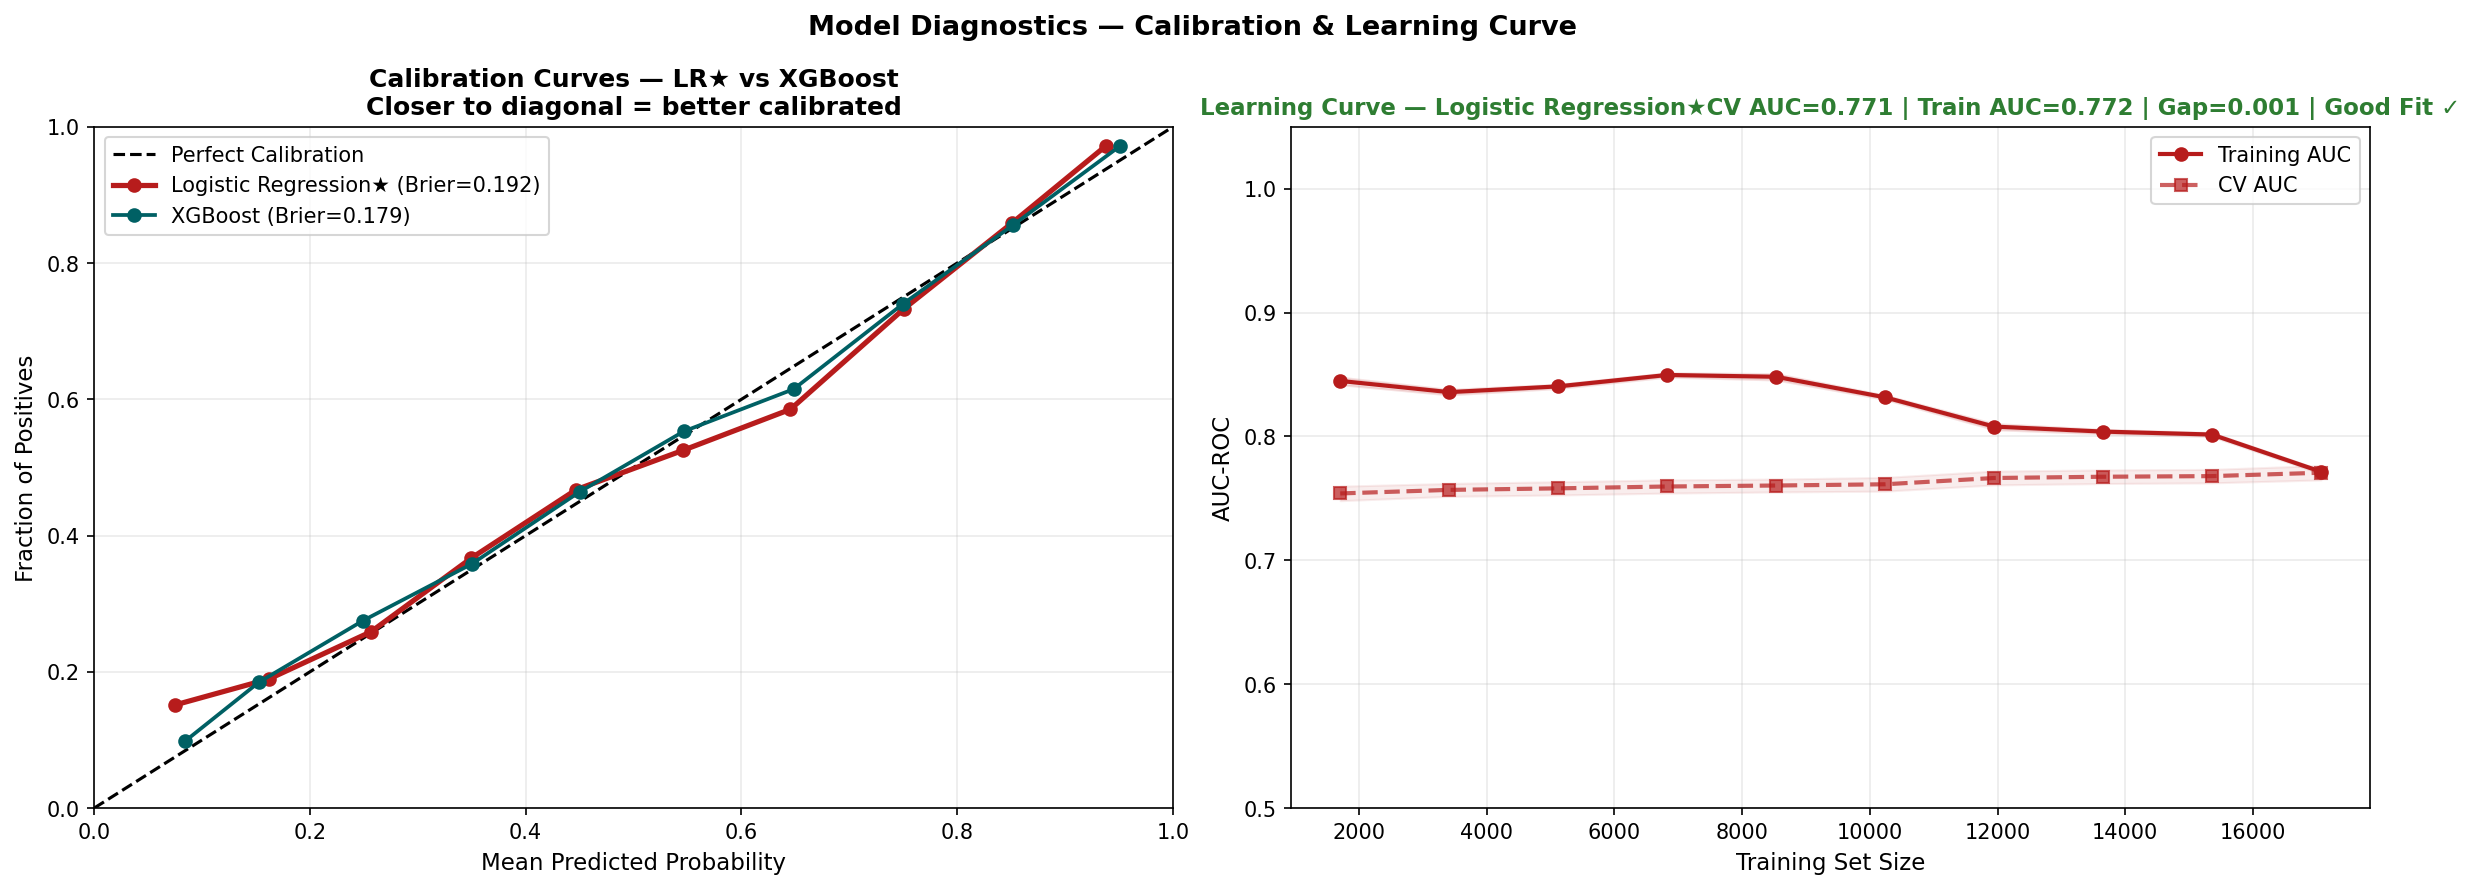

Diagnostics saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — CALIBRATION CURVE + LEARNING CURVE

# ════════════════════════════════════════════════════════════════════════════
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

# ── Calibration ──────────────────────────────────────────────────────────────
ax1.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect Calibration')
for name in ['Logistic Regression','XGBoost']:
    y_prob = trained_models[name].predict_proba(X_test_sel)[:,1]
    frac_pos,mean_pred = calibration_curve(y_test_arr,y_prob,n_bins=10)
    bs = brier_score_loss(y_test_arr,y_prob)
    color = MODEL_COLORS[name]; lw = 2.5 if name==PRIMARY_NAME else 1.8
    ax1.plot(mean_pred,frac_pos,marker='o',color=color,lw=lw,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (Brier={bs:.3f})')
ax1.set_xlabel('Mean Predicted Probability',fontsize=11)
ax1.set_ylabel('Fraction of Positives',fontsize=11)
ax1.set_title('Calibration Curves — LR★ vs XGBoost\nCloser to diagonal = better calibrated',
              fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(alpha=0.25)
ax1.set_xlim([0,1]); ax1.set_ylim([0,1])

# ── Learning Curve ───────────────────────────────────────────────────────────
train_sizes,train_scores,val_scores = sk_lc(
    primary_model, X_train_sel, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,10))

t_mean = train_scores.mean(axis=1); t_std = train_scores.std(axis=1)
v_mean = val_scores.mean(axis=1);   v_std = val_scores.std(axis=1)
gap    = t_mean[-1] - v_mean[-1]


cv_adequate  = v_mean[-1] >= 0.70
cv_stable    = (v_mean[-1] - v_mean[0]) > -0.05
gap_growing  = (gap - (t_mean[0] - v_mean[0])) > 0.10
cv_var_ok    = v_std.mean() < 0.10

if not cv_adequate:
    verdict   = 'Underfitting ⚠'
    verdict_c = '#B71C1C'
elif gap_growing and not cv_stable:
    verdict   = 'Progressive Overfitting ⚠'
    verdict_c = '#E65100'
elif gap > 0.05 and cv_stable and not gap_growing:
    verdict   = 'High Variance — Stable Generalisation ✓'
    verdict_c = '#1565C0'
elif gap <= 0.05 and cv_adequate:
    verdict   = 'Good Fit ✓'
    verdict_c = '#2E7D32'
else:
    verdict   = 'Acceptable Fit ✓'
    verdict_c = '#2E7D32'

ax2.plot(train_sizes,t_mean,'o-',color=PRIMARY_COLOR,lw=2,label='Training AUC')
ax2.fill_between(train_sizes,t_mean-t_std,t_mean+t_std,alpha=0.12,color=PRIMARY_COLOR)
ax2.plot(train_sizes,v_mean,'s--',color=PRIMARY_COLOR,lw=2,alpha=0.7,label='CV AUC')
ax2.fill_between(train_sizes,v_mean-v_std,v_mean+v_std,alpha=0.08,color=PRIMARY_COLOR)
ax2.set_xlabel('Training Set Size',fontsize=11); ax2.set_ylabel('AUC-ROC',fontsize=11)
ax2.set_title(
    f'Learning Curve — Logistic Regression★'
    f'CV AUC={v_mean[-1]:.3f} | Train AUC={t_mean[-1]:.3f} | '
    f'Gap={gap:.3f} | {verdict}',
    fontweight='bold', color=verdict_c, fontsize=11)
ax2.legend(fontsize=10); ax2.grid(alpha=0.25); ax2.set_ylim([0.5,1.05])

plt.suptitle('Model Diagnostics — Calibration & Learning Curve',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'diagnostics_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagnostics saved.')


Computing SHAP (KernelExplainer) …


  0%|          | 0/11260 [00:00<?, ?it/s]

LR SHAP: shape=(11260, 16)  E[f(x)]=0.4800
  XGBoost SHAP (TreeExplainer) ...
  XGBoost SHAP: shape=(11260, 16)  E[f(x)]=0.0012


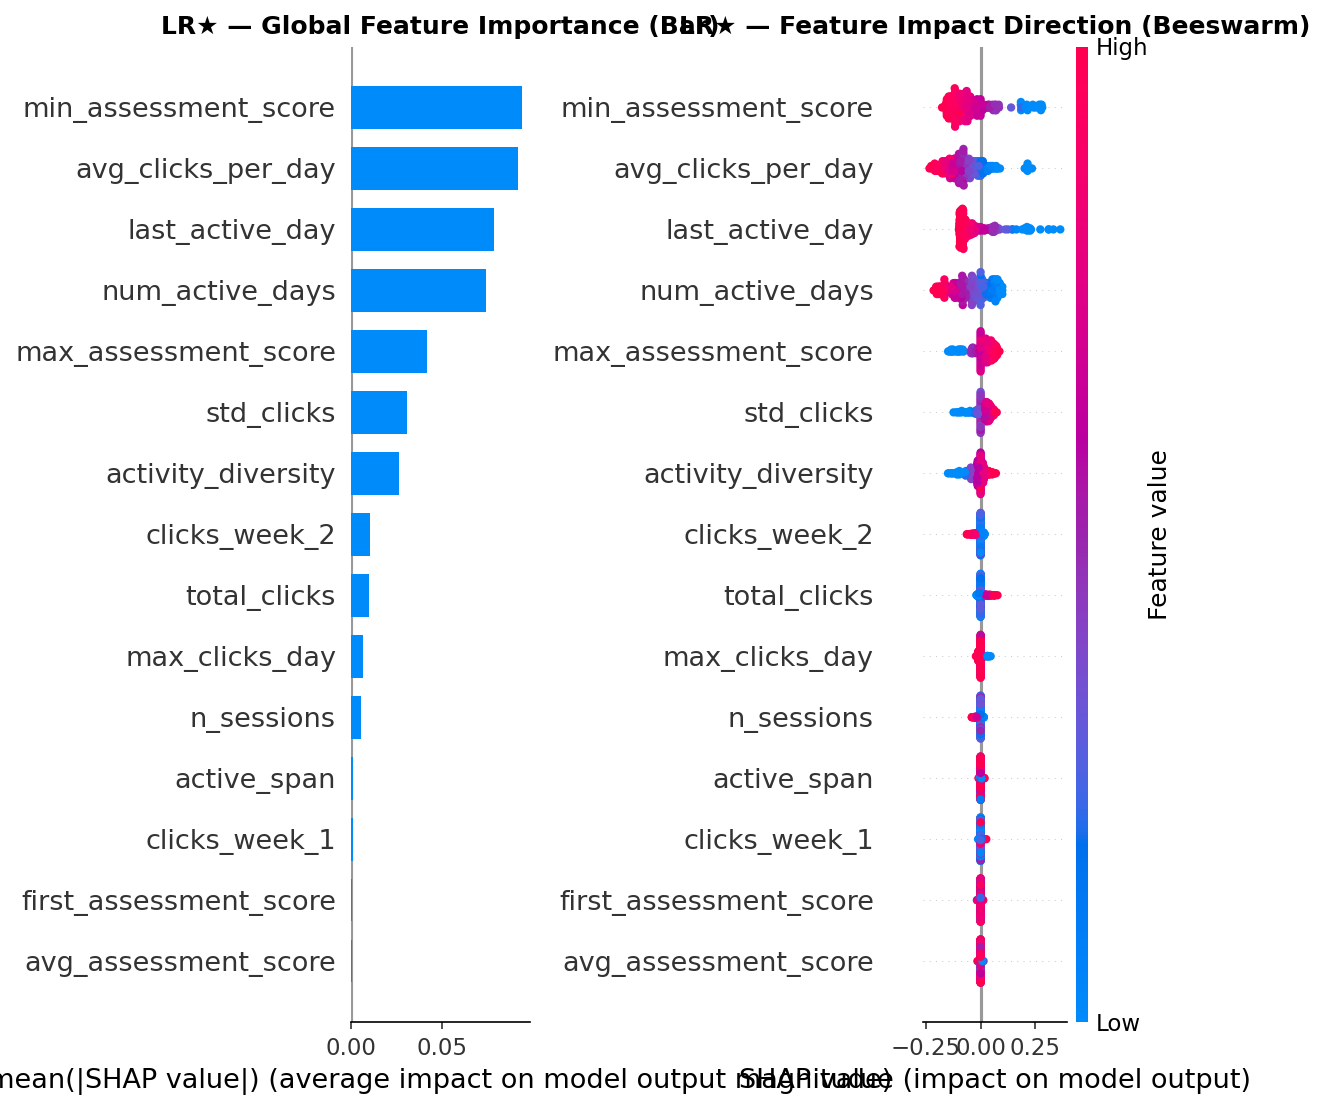

Global SHAP saved.
SHAP auto-selected: 8 features
min_assessment_score   0.1804
last_active_day        0.0970
max_assessment_score   0.0863
avg_clicks_per_day     0.0758
num_active_days        0.0625
activity_diversity     0.0518
std_clicks             0.0349
max_clicks_day         0.0098


In [ ]:

# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — SHAP ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
shap.initjs()

def preprocess(pipe, X):
    Xi = pipe.named_steps['imp'].transform(X)
    return pipe.named_steps['scl'].transform(Xi)

lr_pipe = primary_model
X_tr_p  = preprocess(lr_pipe, X_train_sel)
X_te_lr = preprocess(lr_pipe, X_test_sel)

print('Computing SHAP (KernelExplainer) …')
bg_lr  = shap.sample(X_tr_p, 100, random_state=SEED)
se_lr  = shap.KernelExplainer(
    lambda x: lr_pipe.named_steps['clf'].predict_proba(x)[:,1], bg_lr)

sv_lr_raw = se_lr.shap_values(X_te_lr, nsamples=100)

# Safe shape handling
def safe_kernel_shap(raw, n_features):
    arr = np.array(raw, dtype=float)
    if arr.ndim == 3:   return arr[1]
    if arr.ndim == 2:
        if arr.shape[1] == n_features: return arr
        if arr.shape[0] == n_features: return arr.T
    if arr.ndim == 1 and arr.shape[0] == n_features:
        return arr.reshape(1,-1)
    raise ValueError(f'Unexpected KernelExplainer shape: {arr.shape}')

sv_lr_p = safe_kernel_shap(sv_lr_raw, len(FEATURE_NAMES_SEL))
ev_lr   = float(se_lr.expected_value)
print(f'LR SHAP: shape={sv_lr_p.shape}  E[f(x)]={ev_lr:.4f}')


# ── XGBoost — TreeExplainer (comparison model) ──────────────────────────
print('  XGBoost SHAP (TreeExplainer) ...')
xgb_pipe_c  = trained_models['XGBoost']
xgb_clf_c   = xgb_pipe_c.named_steps['clf']
X_te_xgb_c  = preprocess(xgb_pipe_c, X_test_sel)
X_tr_xgb_c  = preprocess(xgb_pipe_c, X_train_sel)
se_xgb_c    = shap.TreeExplainer(xgb_clf_c, feature_perturbation='tree_path_dependent')
# tree_path_dependent avoids SHAP's categorical-split limitation for XGBoost;
# only model_output='raw' (log-odds) is supported. Feature RANKING is unaffected.
sv_xgb_c    = se_xgb_c.shap_values(X_te_xgb_c)
ev_xgb_c    = float(np.ravel(se_xgb_c.expected_value)[-1])
print(f'  XGBoost SHAP: shape={sv_xgb_c.shape}  E[f(x)]={ev_xgb_c:.4f}')

# Global SHAP plots
fig,(a1,a2) = plt.subplots(1,2,figsize=(18,8))
plt.sca(a1)
shap.summary_plot(sv_lr_p[:300], X_te_lr[:300], feature_names=FEATURE_NAMES_SEL,
                  plot_type='bar', max_display=15, show=False)
a1.set_title('LR★ — Global Feature Importance (Bar)', fontweight='bold')
plt.sca(a2)
shap.summary_plot(sv_lr_p[:300], X_te_lr[:300], feature_names=FEATURE_NAMES_SEL,
                  plot_type='dot', max_display=15, show=False)
a2.set_title('LR★ — Feature Impact Direction (Beeswarm)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_global_LR.png', dpi=300, bbox_inches='tight')
plt.show()
print('Global SHAP saved.')

# Auto-threshold feature selection
MIN_FEATURES   = 8
shap_rank_lr   = pd.Series(np.abs(sv_lr_p).mean(0), index=FEATURE_NAMES_SEL).sort_values(ascending=False)
shap_rank_xgb_c = pd.Series(np.abs(sv_xgb_c).mean(0), index=FEATURE_NAMES_SEL).sort_values(ascending=False)
lr_shap_thresh = shap_rank_lr.mean() + shap_rank_lr.std()
auto_shap_lr   = shap_rank_lr[shap_rank_lr >= lr_shap_thresh]
if len(auto_shap_lr) < MIN_FEATURES: auto_shap_lr = shap_rank_lr.iloc[:MIN_FEATURES]
auto_shap_lr.to_csv(CSV_DIR/'shap_top_lr.csv', header=['SHAP_Importance'])
print(f'SHAP auto-selected: {len(auto_shap_lr)} features')
print(auto_shap_lr.to_string())


LR — TP=3656  TN=4144  FP=1313  FN=2147
Total cases: 10

Generating waterfall plots …


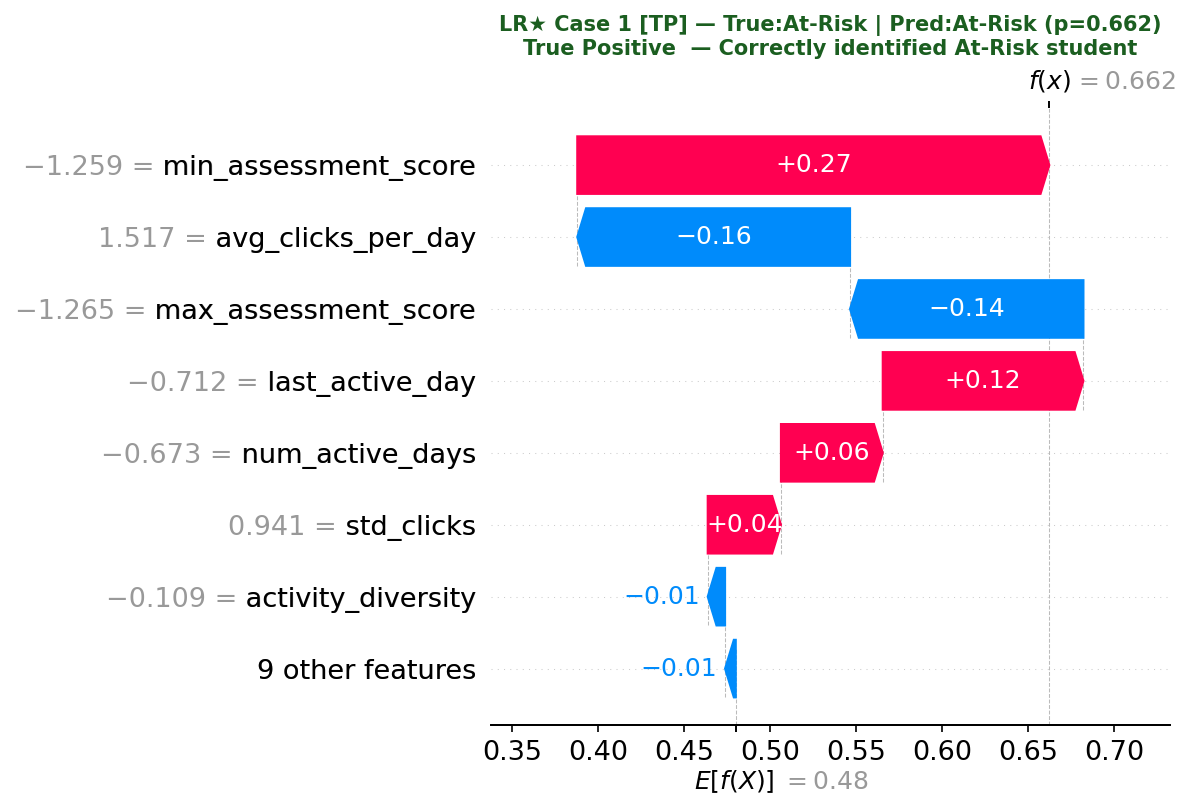

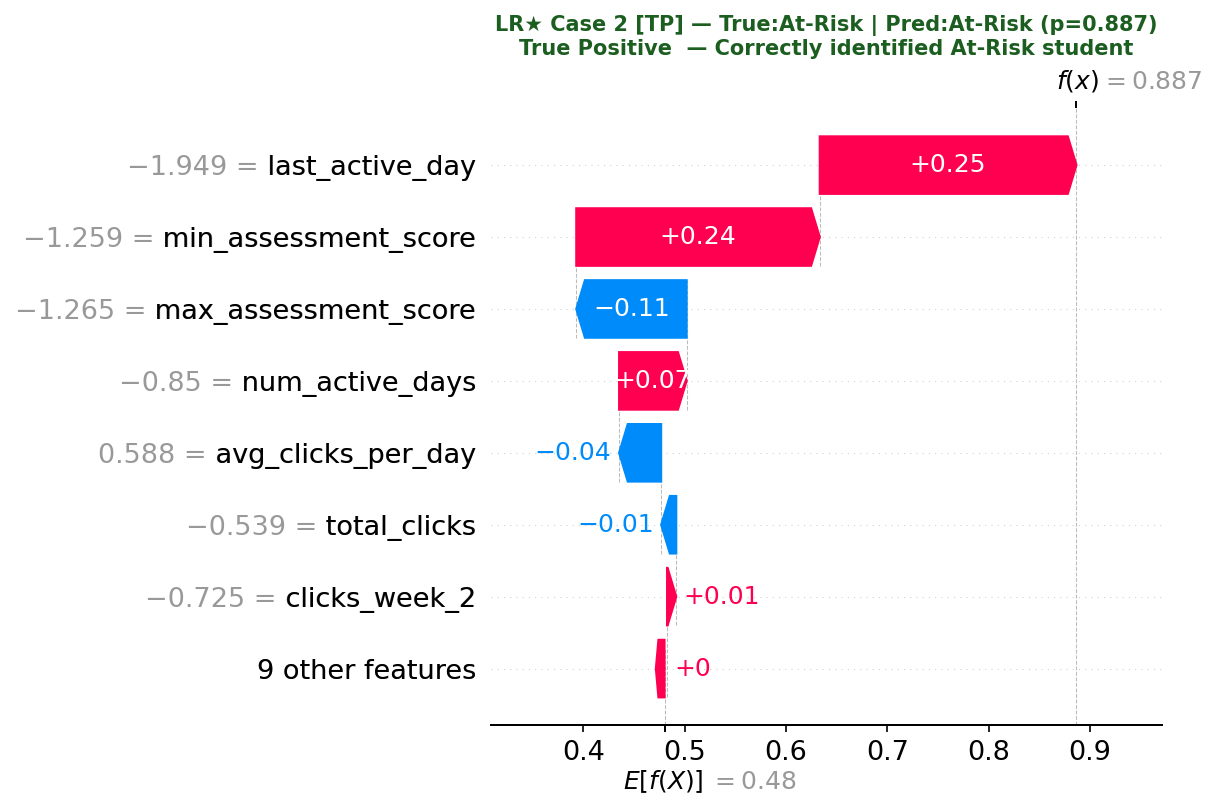

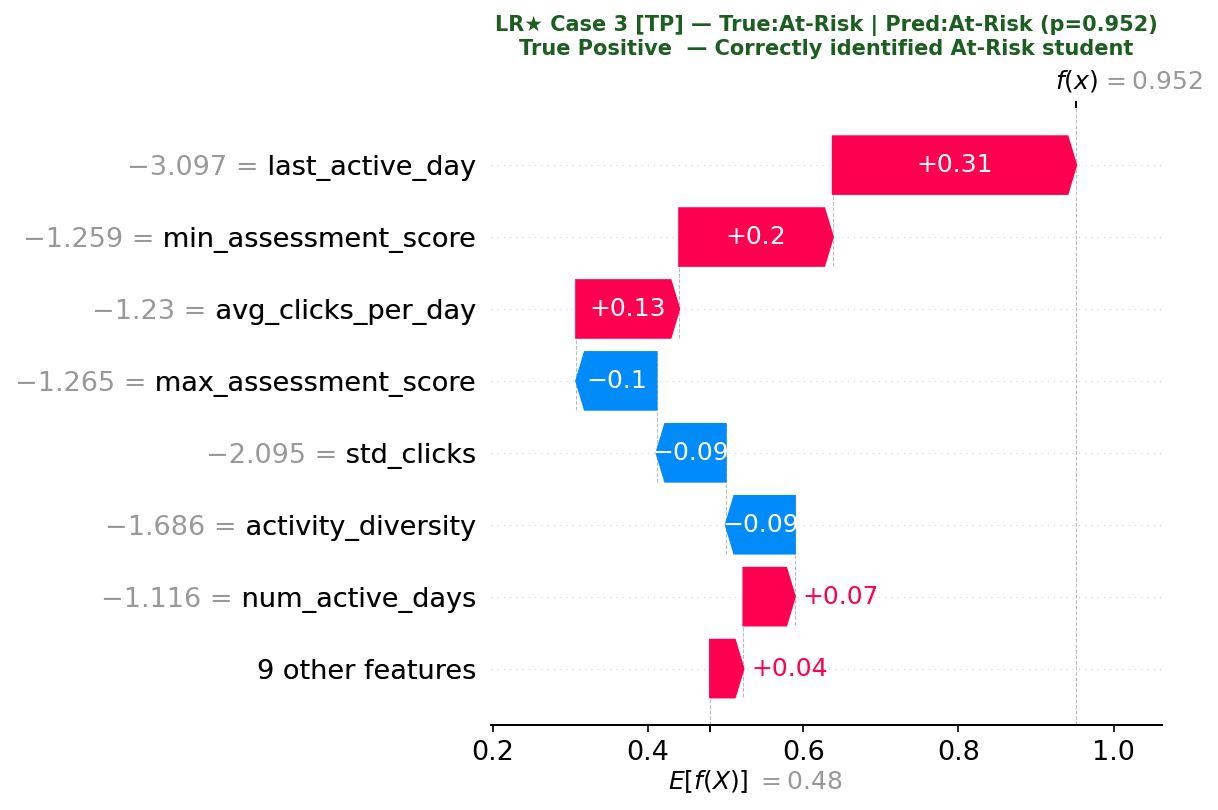

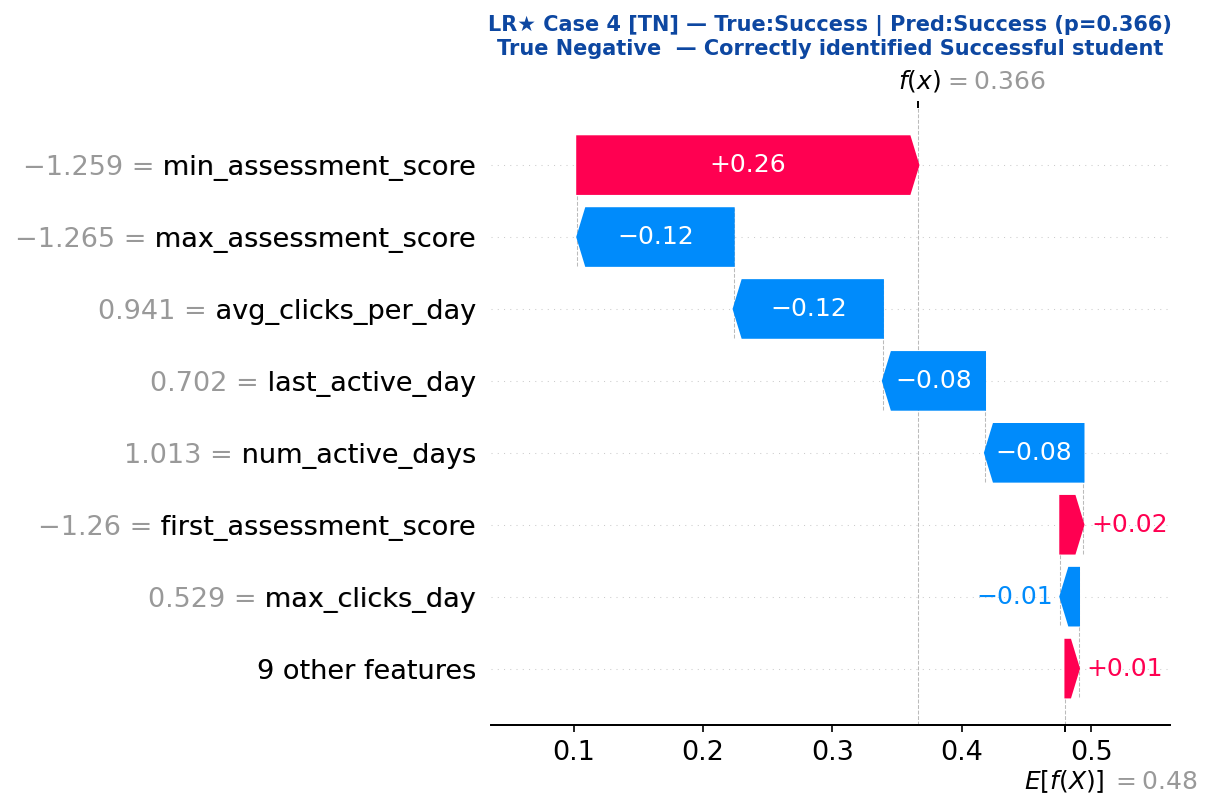

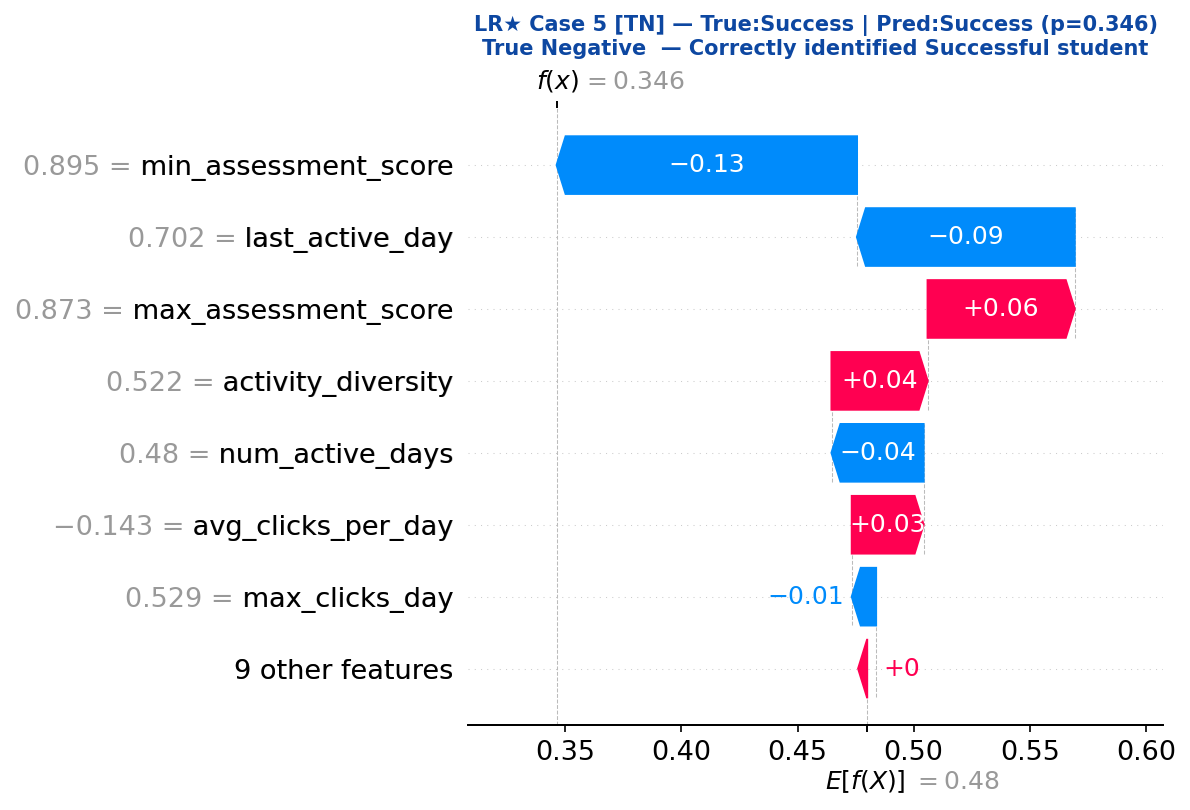

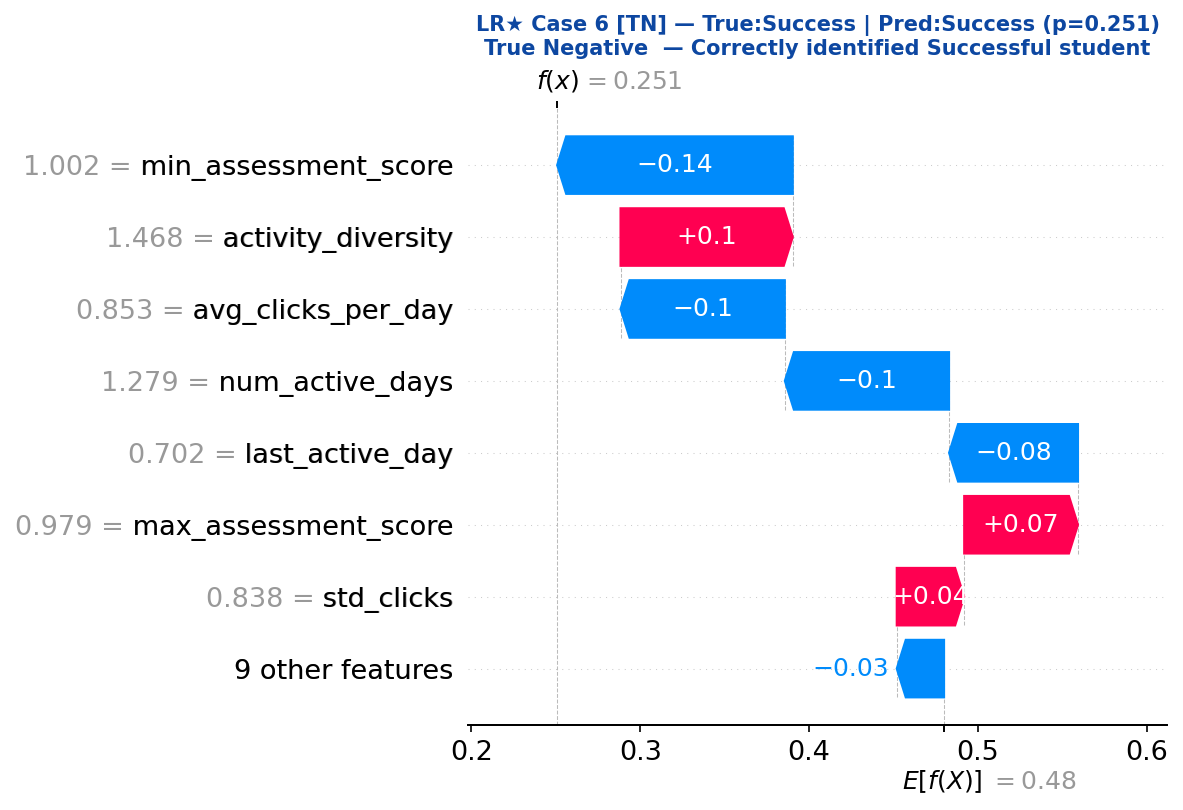

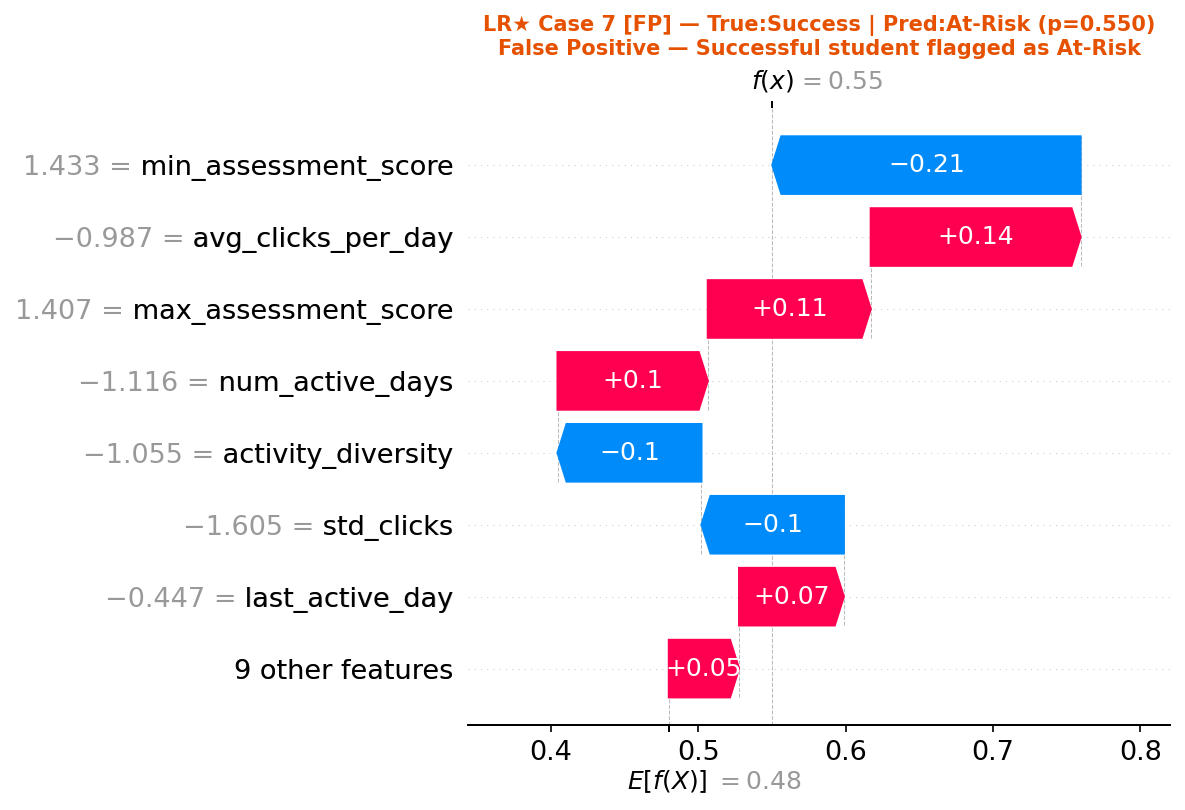

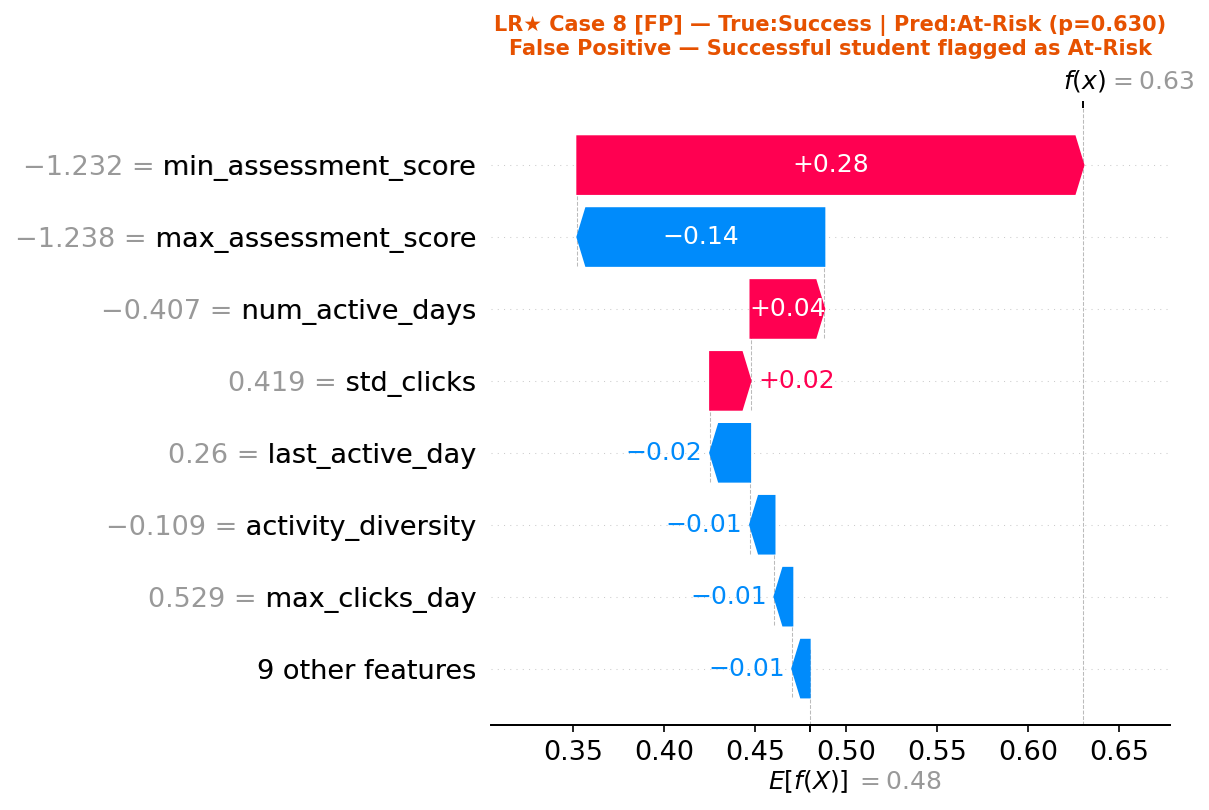

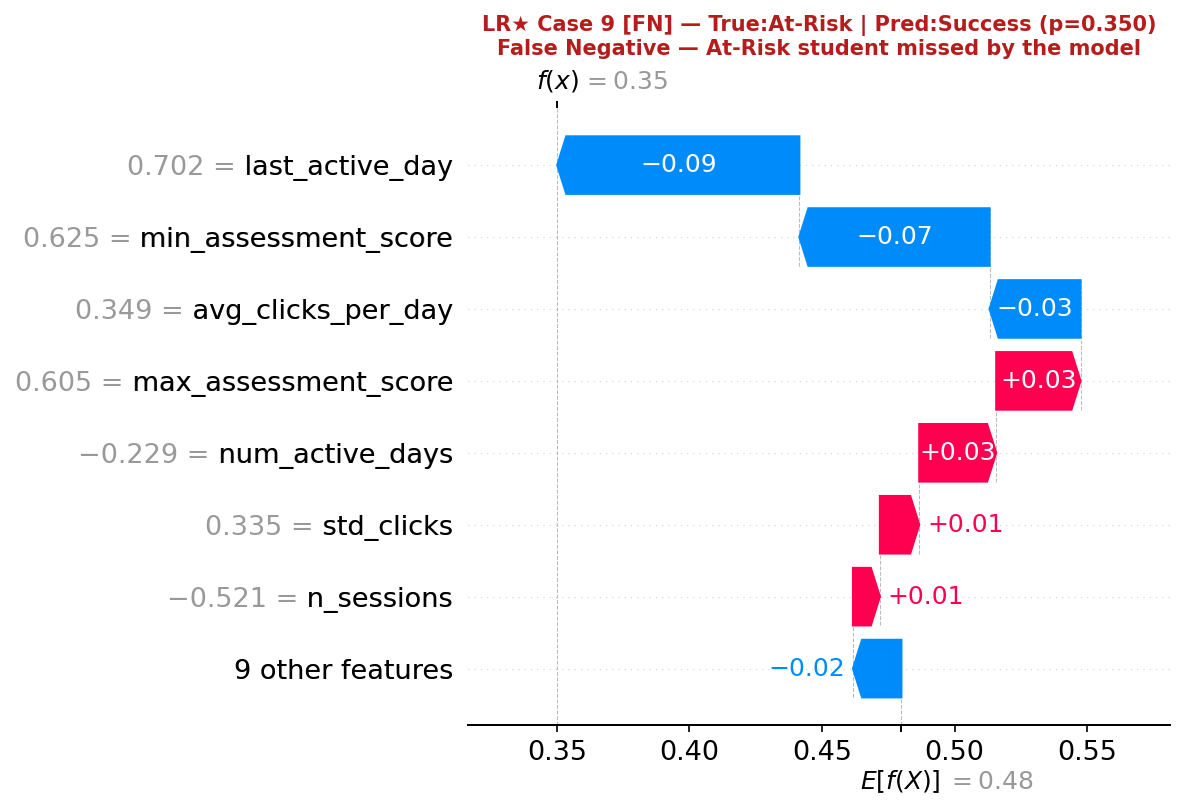

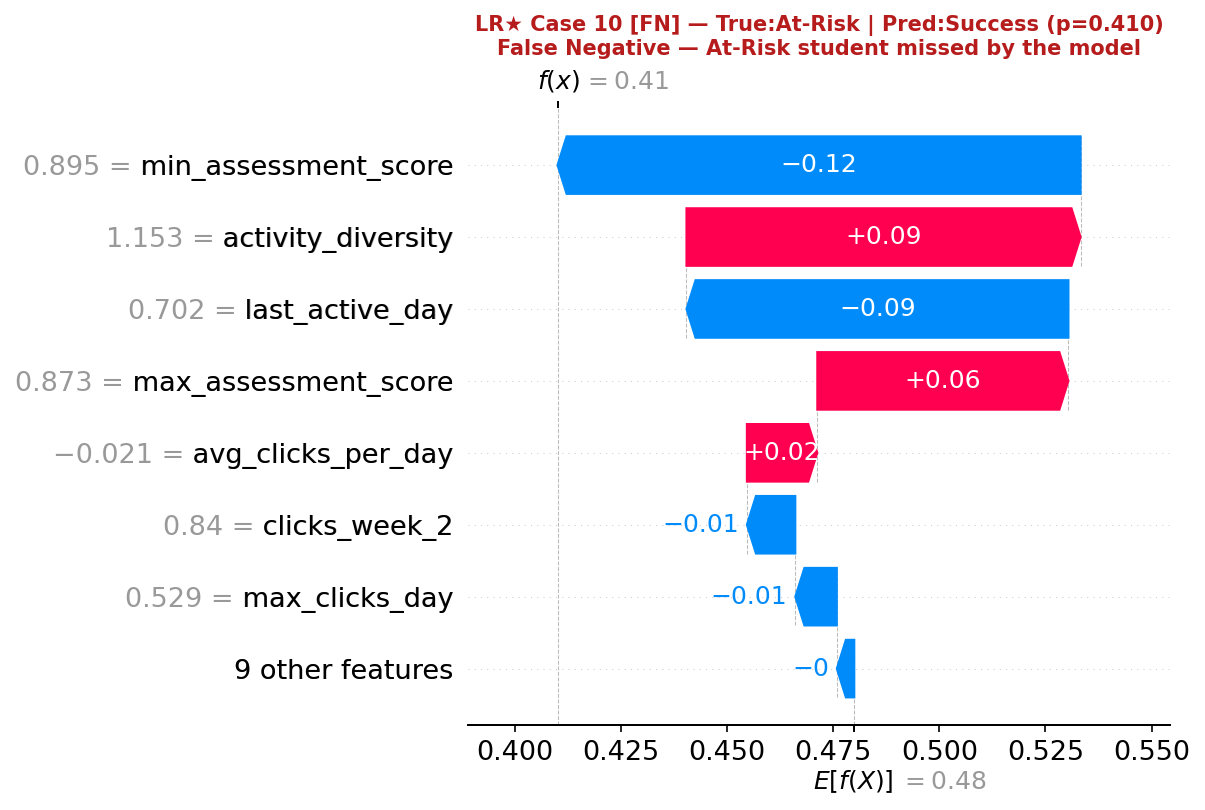

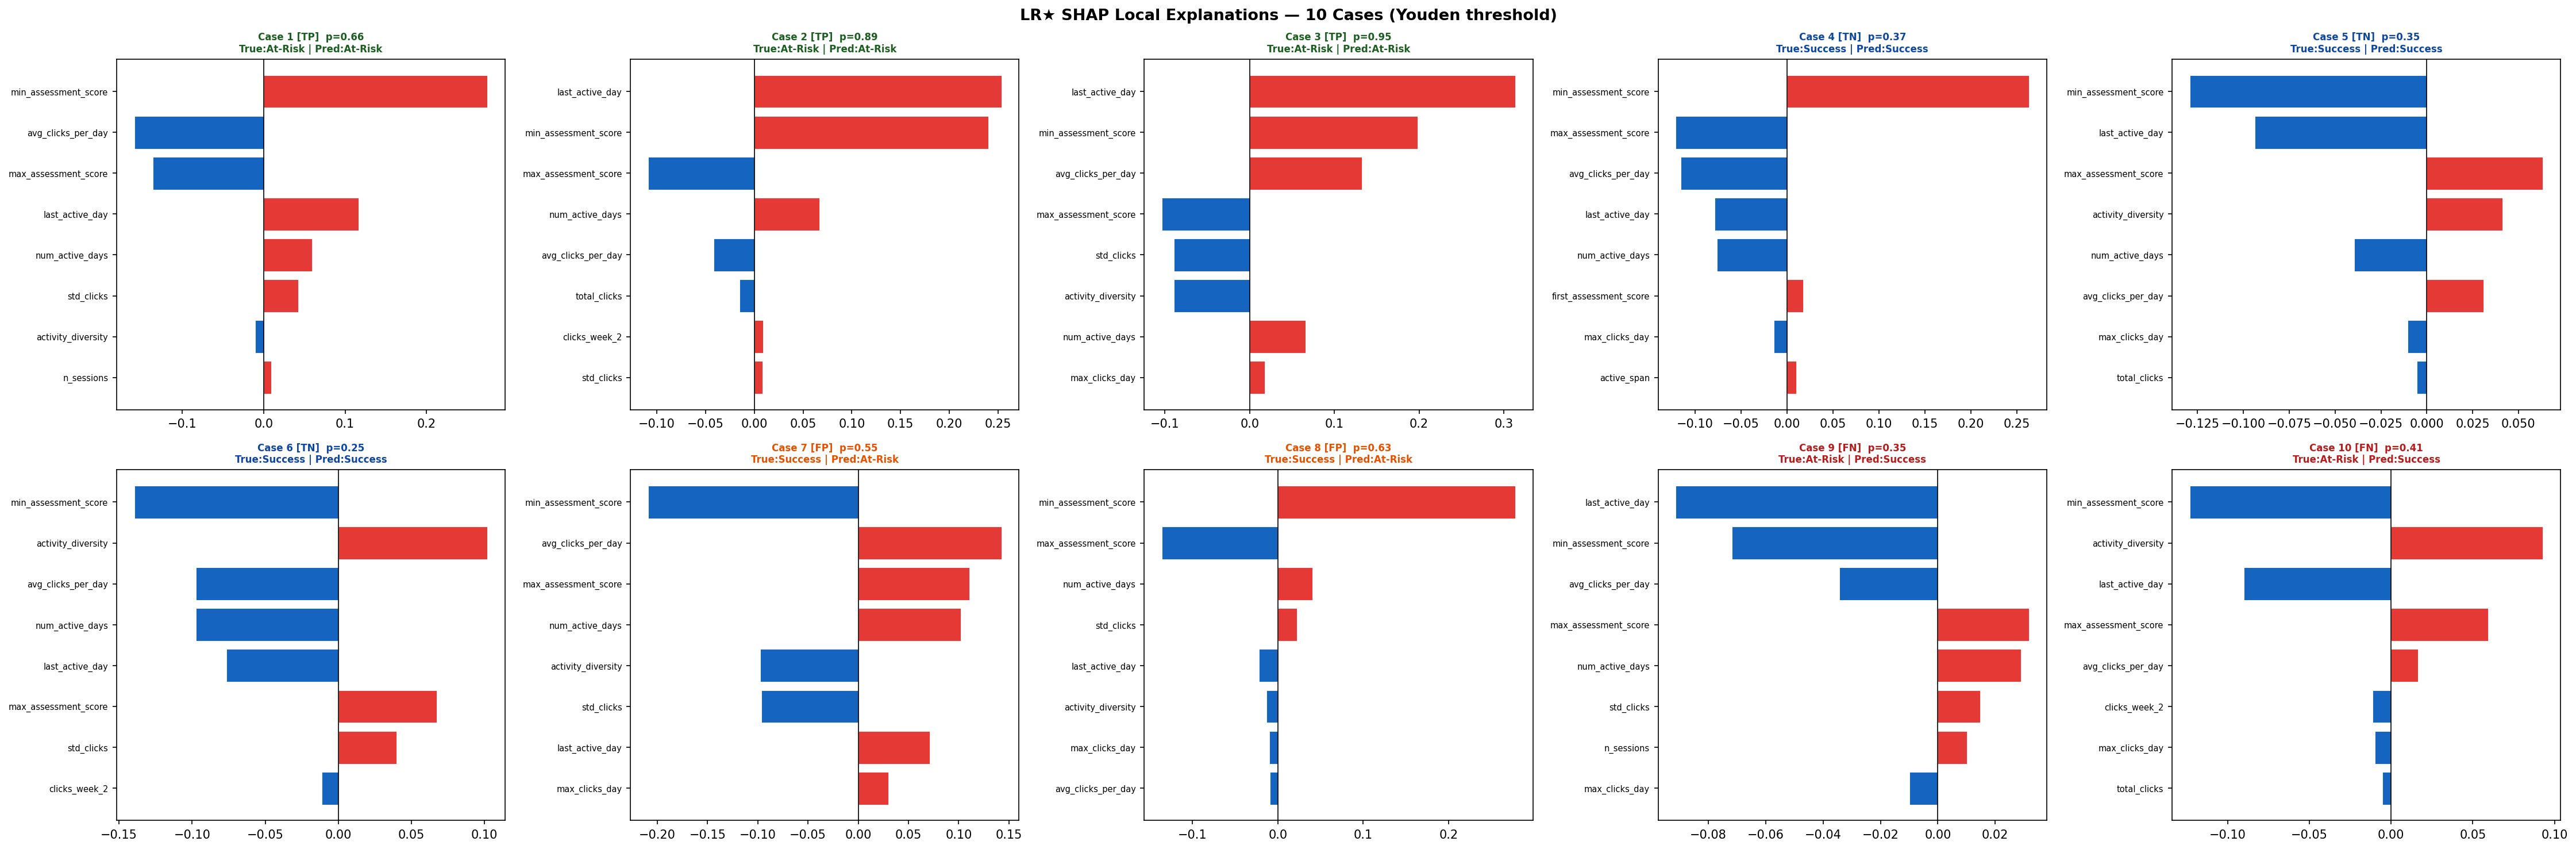

SHAP local explanations saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14 — SHAP LOCAL EXPLANATIONS (10 diverse cases: TP/TN/FP/FN)
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(SEED)
# Apply Youden's J optimal threshold
y_prob_lr = lr_pipe.predict_proba(X_test_sel)[:,1]
y_pred_lr = (y_prob_lr >= best_j_thr).astype(int)  # Youden's J threshold

tp_idx = np.where((y_test_arr==1)&(y_pred_lr==1))[0]
tn_idx = np.where((y_test_arr==0)&(y_pred_lr==0))[0]
fp_idx = np.where((y_test_arr==0)&(y_pred_lr==1))[0]
fn_idx = np.where((y_test_arr==1)&(y_pred_lr==0))[0]
print(f'LR — TP={len(tp_idx)}  TN={len(tn_idx)}  FP={len(fp_idx)}  FN={len(fn_idx)}')

def stratified_pick(idx_arr, n, probs, seed_offset=0):
    np.random.seed(SEED+seed_offset)
    if len(idx_arr)==0: return []
    if len(idx_arr)<=n: return list(idx_arr)
    order = np.argsort(probs[idx_arr])
    bands = np.array_split(order, n)
    return [idx_arr[np.random.choice(b)] for b in bands]

picked_tp = stratified_pick(tp_idx,3,y_prob_lr,0)
picked_tn = stratified_pick(tn_idx,3,1-y_prob_lr,1)
picked_fp = stratified_pick(fp_idx,2,y_prob_lr,2)
picked_fn = stratified_pick(fn_idx,2,y_prob_lr,3)
local_idx  = picked_tp+picked_tn+picked_fp+picked_fn
case_types = (['TP']*len(picked_tp)+['TN']*len(picked_tn)+
               ['FP']*len(picked_fp)+['FN']*len(picked_fn))
print(f'Total cases: {len(local_idx)}')

type_color = {'TP':'#1B5E20','TN':'#0D47A1','FP':'#E65100','FN':'#B71C1C'}
type_label = {
    'TP':'True Positive  — Correctly identified At-Risk student',
    'TN':'True Negative  — Correctly identified Successful student',
    'FP':'False Positive — Successful student flagged as At-Risk',
    'FN':'False Negative — At-Risk student missed by the model',
}


shap_exp_lr = shap.Explanation(
    values      = sv_lr_p,
    base_values = np.full(len(sv_lr_p), ev_lr),
    data        = X_te_lr,
    feature_names = FEATURE_NAMES_SEL
)

print('\nGenerating waterfall plots …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    tl = 'At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl = 'At-Risk' if y_pred_lr[idx]==1 else 'Success'
    plt.figure(figsize=(11,6))
    shap.plots.waterfall(shap_exp_lr[idx], max_display=8, show=False)  # ✅ exact index
    plt.title(f'LR★ Case {i+1} [{ctype}] — True:{tl} | Pred:{pl} (p={y_prob_lr[idx]:.3f})\n'
              f'{type_label[ctype]}',
              fontsize=10, fontweight='bold', color=type_color[ctype])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'shap_local_lr_case_{i+1}_{ctype}.png',dpi=300,bbox_inches='tight')
    plt.show(); plt.close()

# Summary grid
fig,axes = plt.subplots(2,5,figsize=(30,10)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    sv_i = sv_lr_p[idx]
    top8 = np.argsort(np.abs(sv_i))[-8:]
    axes[i].barh([FEATURE_NAMES_SEL[j][:22] for j in top8],[sv_i[j] for j in top8],
                 color=['#E53935' if v>0 else '#1565C0' for v in [sv_i[j] for j in top8]],
                 edgecolor='white',linewidth=0.4)
    axes[i].axvline(0,color='black',lw=0.8)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_lr[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_lr[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
    axes[i].tick_params(axis='y',labelsize=7)
plt.suptitle('LR★ SHAP Local Explanations — 10 Cases (Youden threshold)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_local_lr_10cases.png',dpi=150,bbox_inches='tight')
plt.show()
print('SHAP local explanations saved.')


Computing SHAP for DT, RF, SVM (TreeExplainer) …


  DT SHAP: shape=(11260, 16)


100%|===================| 22512/22520 [30:35<00:00]       

  RF SHAP: shape=(11260, 16)
  SVM SHAP (KernelExplainer) …


  0%|          | 0/200 [00:00<?, ?it/s]

  SVM SHAP: shape=(200, 16)

SHAP Auto-Selected:
  LR★=8 XGB=8 
  DT=8  RF=8  SVM=8

SHAP Consensus (≥3/5 models): 7 features
SHAP Union (all selected)    : 15 features


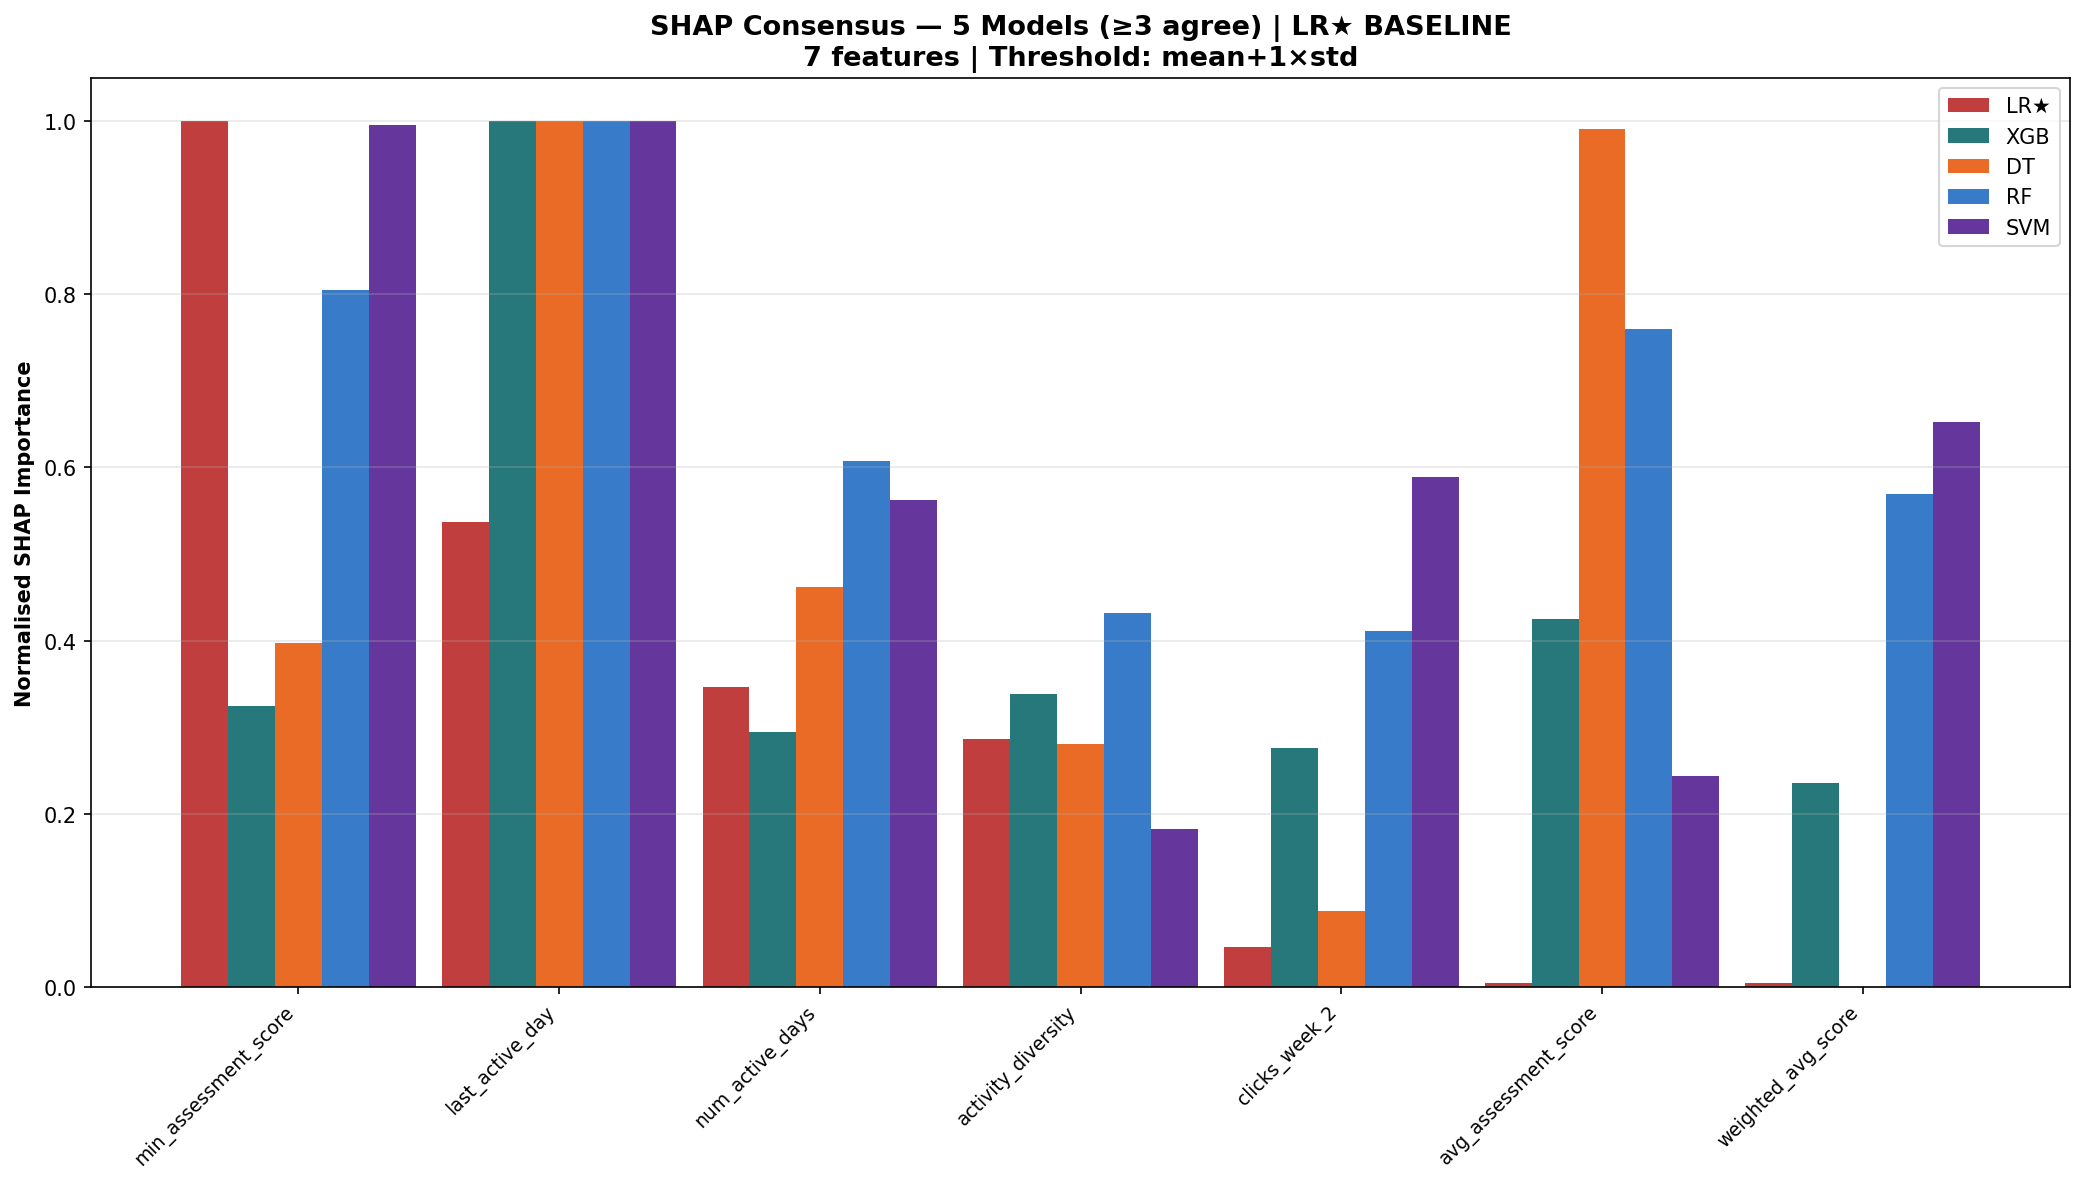

SHAP Consensus plot saved.


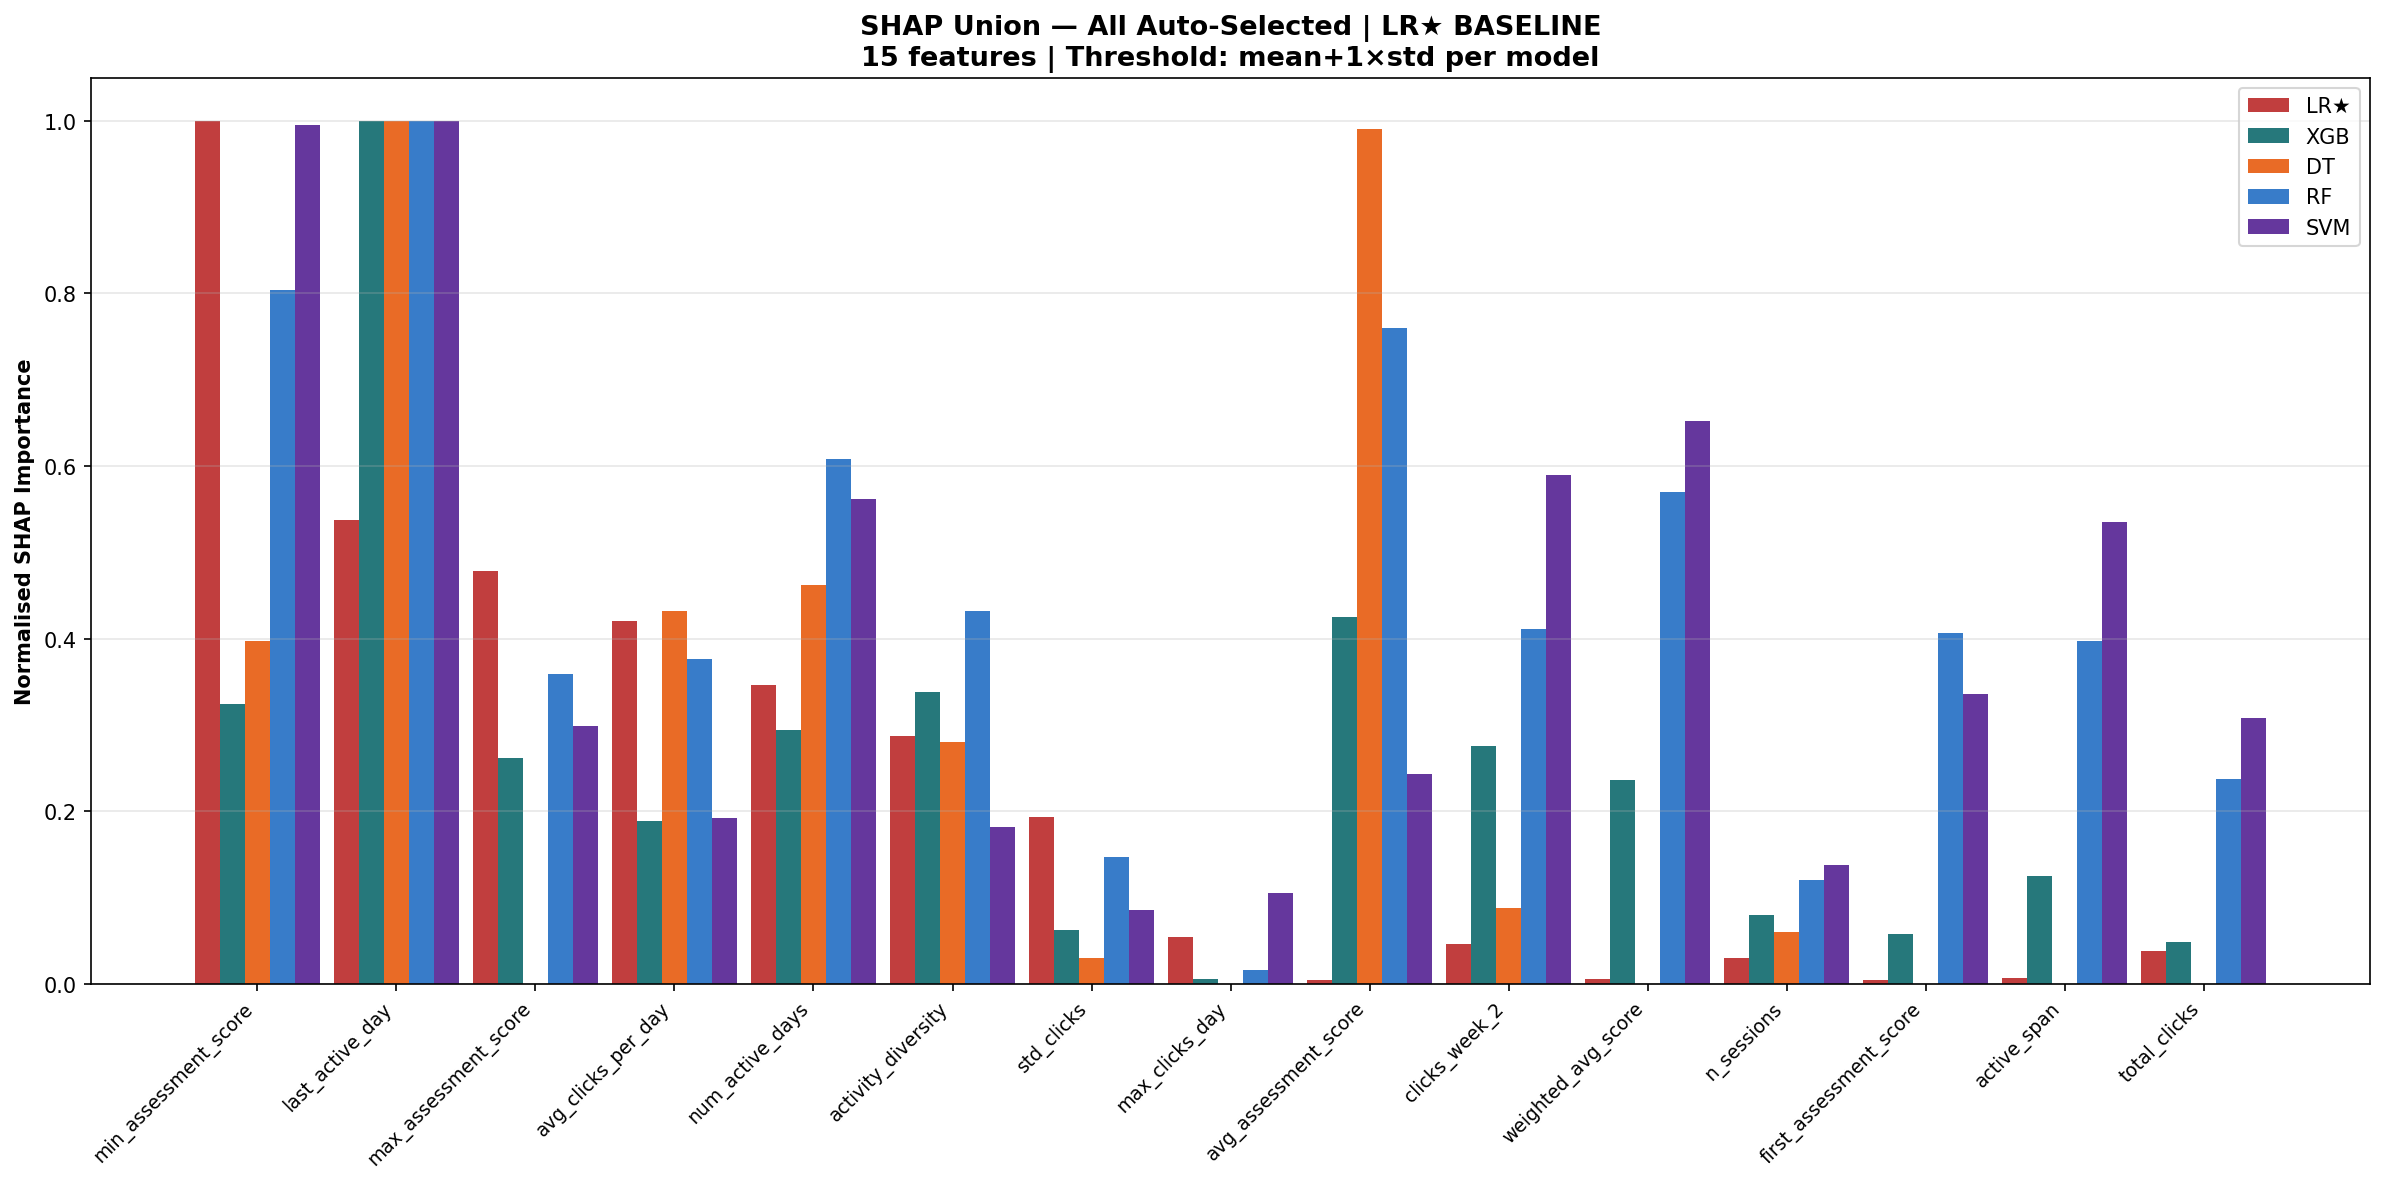

SHAP Union plot saved.


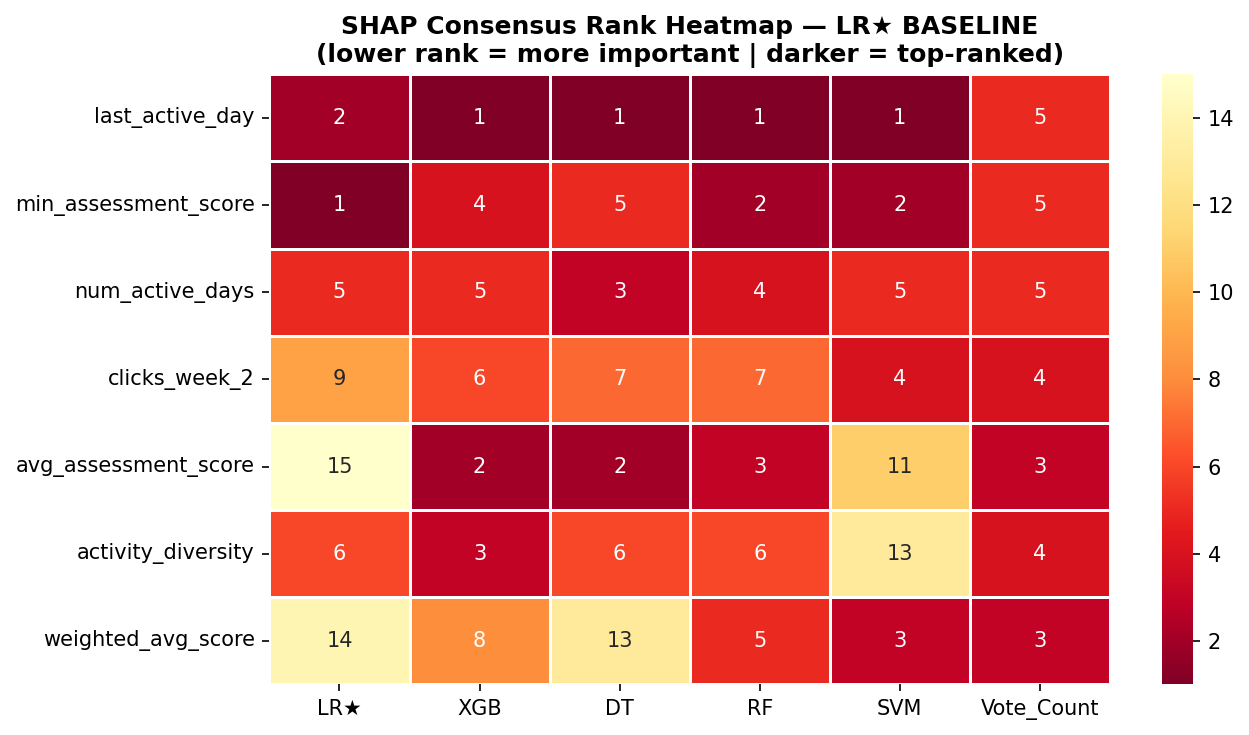

Heatmap saved.

SHAP Rankings complete — Consensus:7 | Union:15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SHAP AUTO-SELECTED RANKINGS + CONSENSUS (All 5 Models)
# ════════════════════════════════════════════════════════════════════════════

def _safe_shap_rank(sv, feature_names):
    arr = np.array(sv)
    if arr.ndim == 1: raise ValueError(f'1D SHAP: {arr.shape}')
    return pd.Series(np.abs(arr).mean(0), index=feature_names).sort_values(ascending=False)

def _auto_shap(s, min_f=MIN_FEATURES):
    sel = s[s >= s.mean()+s.std()]
    return sel if len(sel) >= min_f else s.iloc[:min_f]

# ── Compute SHAP for DT, RF, SVM (TreeExplainer) ─────────────────────────
print('Computing SHAP for DT, RF, SVM (TreeExplainer) …')

# Decision Tree
se_dt_lr  = shap.TreeExplainer(trained_models['Decision Tree'].named_steps['clf'],
                feature_perturbation='interventional',
                model_output='probability', data=X_tr_p[:200])
sv_dt_raw = se_dt_lr.shap_values(preprocess(trained_models['Decision Tree'], X_test_sel))
sv_dt_lr  = (np.array(sv_dt_raw[1]) if isinstance(sv_dt_raw, list)
             else (sv_dt_raw[:,:,1] if np.array(sv_dt_raw).ndim==3 else sv_dt_raw))
print(f'  DT SHAP: shape={sv_dt_lr.shape}')

# Random Forest
se_rf_lr  = shap.TreeExplainer(trained_models['Random Forest'].named_steps['clf'],
                feature_perturbation='interventional',
                model_output='probability', data=X_tr_p[:200])
sv_rf_raw = se_rf_lr.shap_values(preprocess(trained_models['Random Forest'], X_test_sel))
sv_rf_lr  = (np.array(sv_rf_raw[1]) if isinstance(sv_rf_raw, list)
             else (sv_rf_raw[:,:,1] if np.array(sv_rf_raw).ndim==3 else sv_rf_raw))
print(f'  RF SHAP: shape={sv_rf_lr.shape}')

# SVM — KernelExplainer
print('  SVM SHAP (KernelExplainer) …')
bg_svm_lr = shap.sample(X_tr_p, 100, random_state=SEED)
se_svm_lr = shap.KernelExplainer(
    lambda x: trained_models['SVM'].named_steps['clf'].predict_proba(x)[:,1], bg_svm_lr)
sv_svm_raw = se_svm_lr.shap_values(preprocess(trained_models['SVM'], X_test_sel)[:200], nsamples=100)
sv_svm_lr  = safe_kernel_shap(sv_svm_raw, len(FEATURE_NAMES_SEL))
print(f'  SVM SHAP: shape={sv_svm_lr.shape}')

# ── Rank all 5 models ─────────────────────────────────────────────────────
shap_rank_lr_5   = _safe_shap_rank(sv_lr_p,   FEATURE_NAMES_SEL)   # LR★
shap_rank_xgb_5  = _safe_shap_rank(sv_xgb_c,  FEATURE_NAMES_SEL)   # XGBoost
shap_rank_dt_5   = _safe_shap_rank(sv_dt_lr,  FEATURE_NAMES_SEL)   # DT
shap_rank_rf_5   = _safe_shap_rank(sv_rf_lr,  FEATURE_NAMES_SEL)   # RF
shap_rank_svm_5  = _safe_shap_rank(sv_svm_lr, FEATURE_NAMES_SEL)   # SVM

auto_shap_lr_5   = _auto_shap(shap_rank_lr_5)
auto_shap_xgb_5  = _auto_shap(shap_rank_xgb_5)
auto_shap_dt_5   = _auto_shap(shap_rank_dt_5)
auto_shap_rf_5   = _auto_shap(shap_rank_rf_5)
auto_shap_svm_5  = _auto_shap(shap_rank_svm_5)

print(f'\nSHAP Auto-Selected:')
print(f'  LR★={len(auto_shap_lr_5)} XGB={len(auto_shap_xgb_5)} ')
print(f'  DT={len(auto_shap_dt_5)}  RF={len(auto_shap_rf_5)}  SVM={len(auto_shap_svm_5)}')

for nm, s in [('lr',auto_shap_lr_5),('xgb',auto_shap_xgb_5),('dt',auto_shap_dt_5),
              ('rf',auto_shap_rf_5),('svm',auto_shap_svm_5)]:
    s.to_csv(CSV_DIR/f'shap_top_{nm}.csv', header=['SHAP_Importance'])

# ── Consensus ≥3 of 5 models ──────────────────────────────────────────────
from collections import Counter as _SCtr
all_sf = (list(auto_shap_lr_5.index)+list(auto_shap_xgb_5.index)+
          list(auto_shap_dt_5.index)+list(auto_shap_rf_5.index)+
          list(auto_shap_svm_5.index))
sv_cnt = _SCtr(all_sf)
shap_consensus = [f for f,c in sorted(sv_cnt.items(),key=lambda x:-x[1]) if c>=3]
shap_union     = list(dict.fromkeys(all_sf))

print(f'\nSHAP Consensus (≥3/5 models): {len(shap_consensus)} features')
print(f'SHAP Union (all selected)    : {len(shap_union)} features')

# ── model_ranks for plots ─────────────────────────────────────────────────
shap_model_ranks_5 = [
    (shap_rank_lr_5,  'LR★', '#B71C1C'),
    (shap_rank_xgb_5, 'XGB', '#006064'),
    (shap_rank_dt_5,  'DT',  '#E65100'),
    (shap_rank_rf_5,  'RF',  '#1565C0'),
    (shap_rank_svm_5, 'SVM', '#4A148C'),
]
bw = 0.18

# ── Plot 1: Consensus ─────────────────────────────────────────────────────
if shap_consensus:
    fig, ax = plt.subplots(figsize=(max(14,len(shap_consensus)),8))
    x = np.arange(len(shap_consensus))
    for ii,(rank,lb,col) in enumerate(shap_model_ranks_5):
        ax.bar(x+(ii-2)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in shap_consensus],
               bw,label=lb,color=col,alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in shap_consensus],rotation=45,ha='right',fontsize=9)
    ax.set_ylabel('Normalised SHAP Importance',fontweight='bold')
    ax.set_title(f'SHAP Consensus — 5 Models (≥3 agree) | LR★ BASELINE\n'
                 f'{len(shap_consensus)} features | Threshold: mean+1×std',
                 fontsize=13,fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'shap_consensus_LR.png',dpi=150,bbox_inches='tight')
    plt.show(); print('SHAP Consensus plot saved.')

# ── Plot 2: Union ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16,len(shap_union)),8))
x = np.arange(len(shap_union))
for ii,(rank,lb,col) in enumerate(shap_model_ranks_5):
    ax.bar(x+(ii-2)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in shap_union],
           bw,label=lb,color=col,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in shap_union],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised SHAP Importance',fontweight='bold')
ax.set_title(f'SHAP Union — All Auto-Selected | LR★ BASELINE\n'
             f'{len(shap_union)} features | Threshold: mean+1×std per model',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_union_LR.png',dpi=150,bbox_inches='tight')
plt.show(); print('SHAP Union plot saved.')

# ── Heatmap ───────────────────────────────────────────────────────────────
if shap_consensus:
    rtbl_s = pd.DataFrame({lb: s.rank(ascending=False).astype(int)
                            for s,lb,_ in shap_model_ranks_5},
                           index=FEATURE_NAMES_SEL).loc[shap_consensus]
    rtbl_s['Avg_Rank']   = rtbl_s.mean(axis=1)
    rtbl_s['Vote_Count'] = [sv_cnt[f] for f in shap_consensus]
    rtbl_s = rtbl_s.sort_values('Avg_Rank')
    rtbl_s.to_csv(CSV_DIR/'shap_consensus_ranking_LR.csv')

    fig,ax = plt.subplots(figsize=(9,max(5,len(shap_consensus)*0.5)))
    sns.heatmap(rtbl_s[['LR★','XGB','DT','RF','SVM','Vote_Count']],
                annot=True,fmt='.0f',cmap='YlOrRd_r',linewidths=0.5,ax=ax)
    ax.set_title('SHAP Consensus Rank Heatmap — LR★ BASELINE\n'
                 '(lower rank = more important | darker = top-ranked)',fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'shap_rank_heatmap_LR.png',dpi=150,bbox_inches='tight')
    plt.show(); print('Heatmap saved.')

print(f'\nSHAP Rankings complete — Consensus:{len(shap_consensus)} | Union:{len(shap_union)}')


10 LIME explanations: 0.5s (0.05s/case)
Generating LIME local explanation plots (native LIME style) …


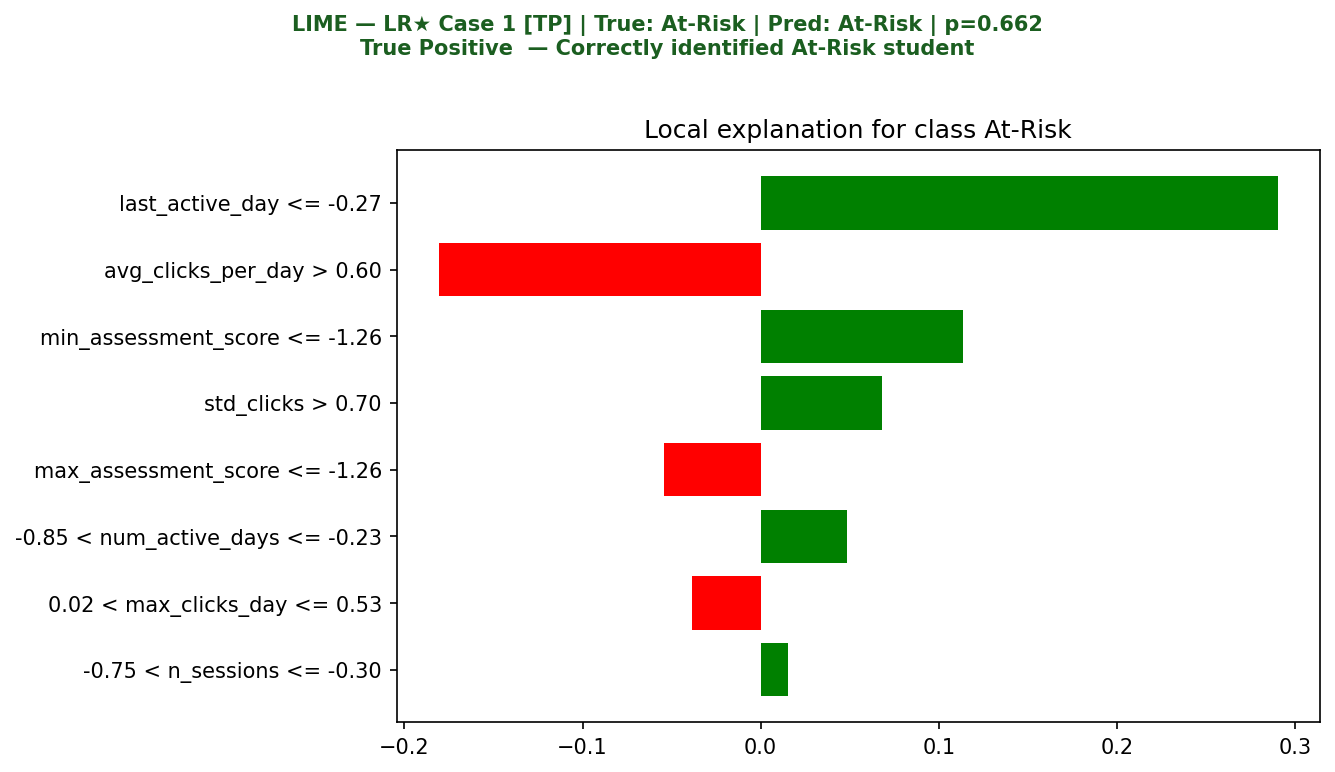

  Case 1 [TP] saved.


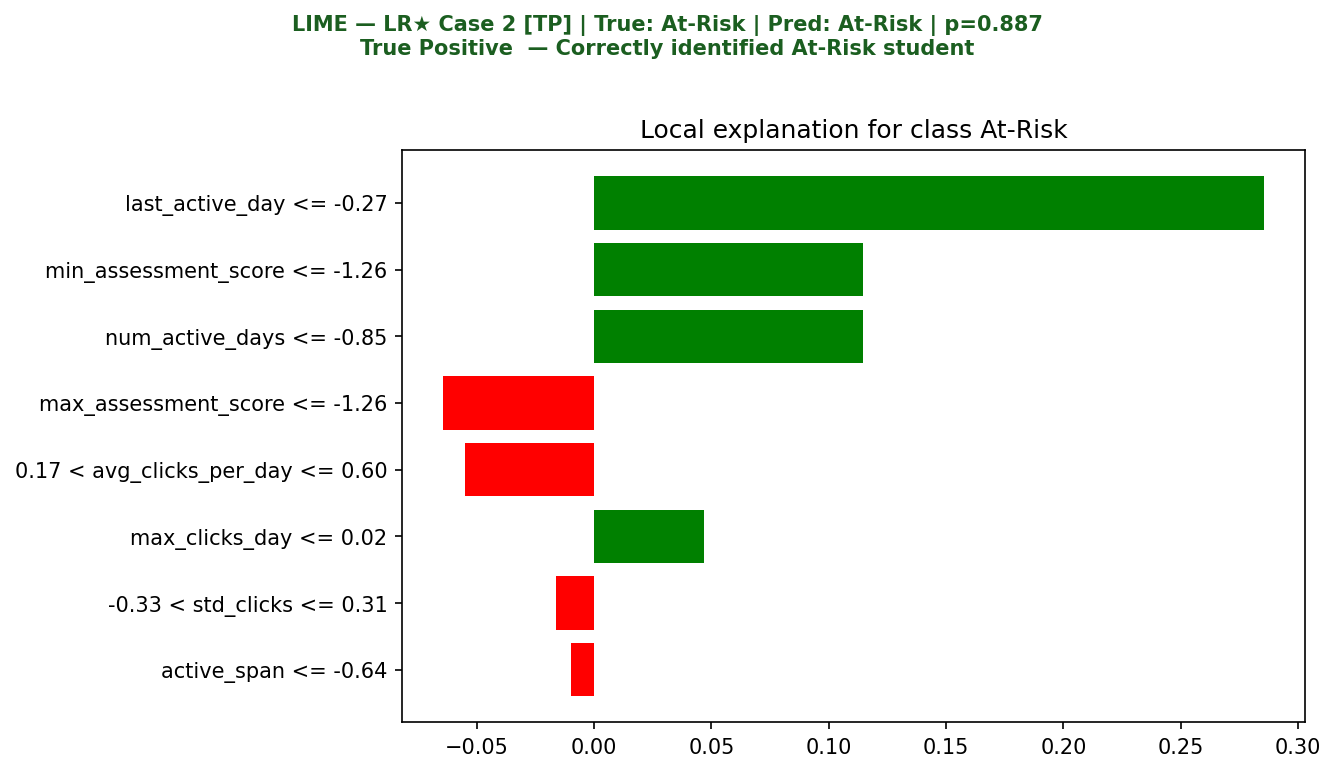

  Case 2 [TP] saved.


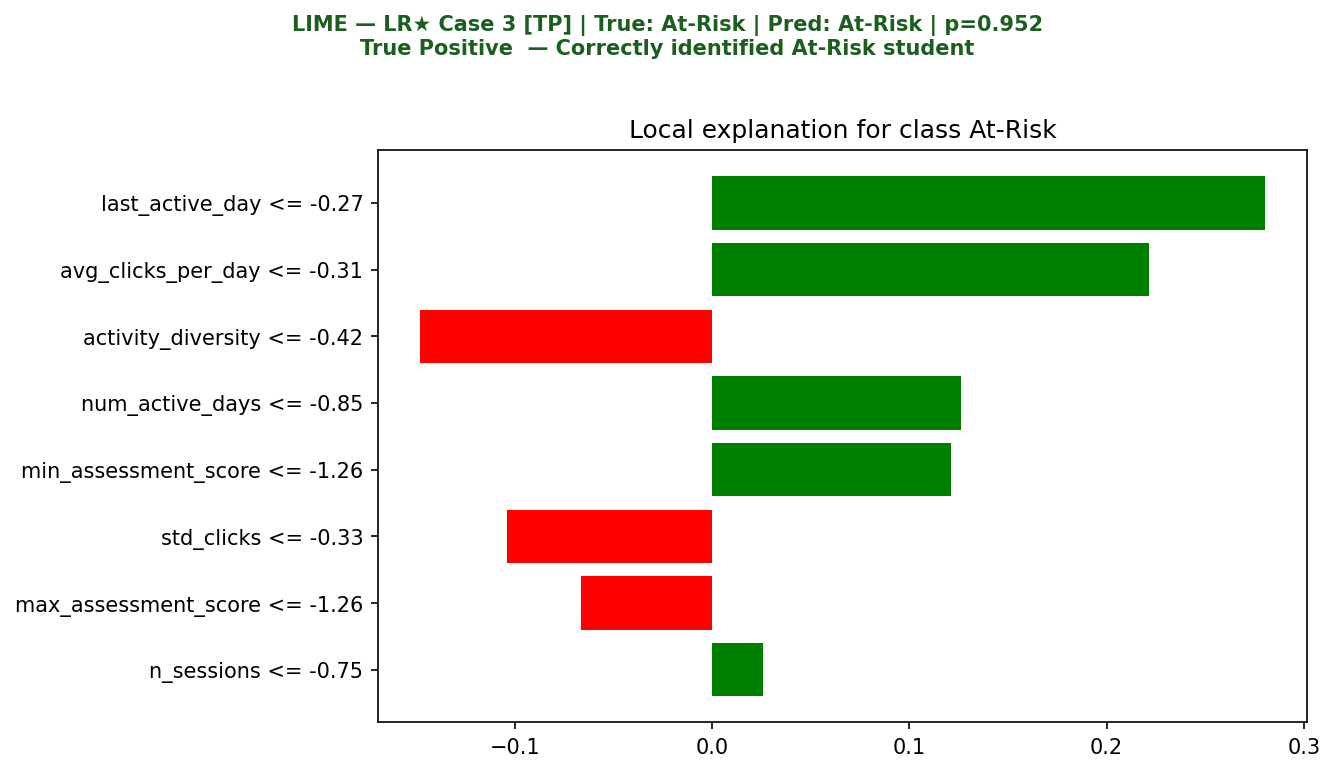

  Case 3 [TP] saved.


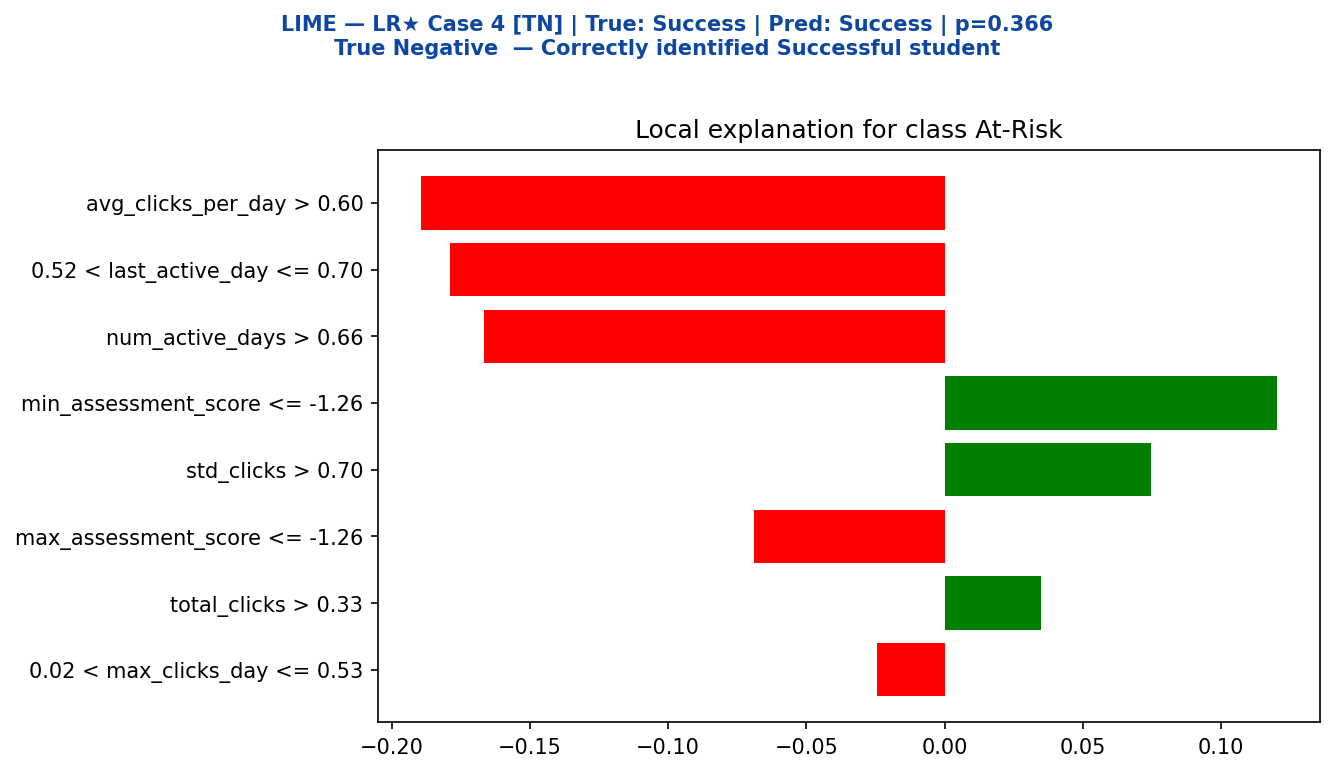

  Case 4 [TN] saved.


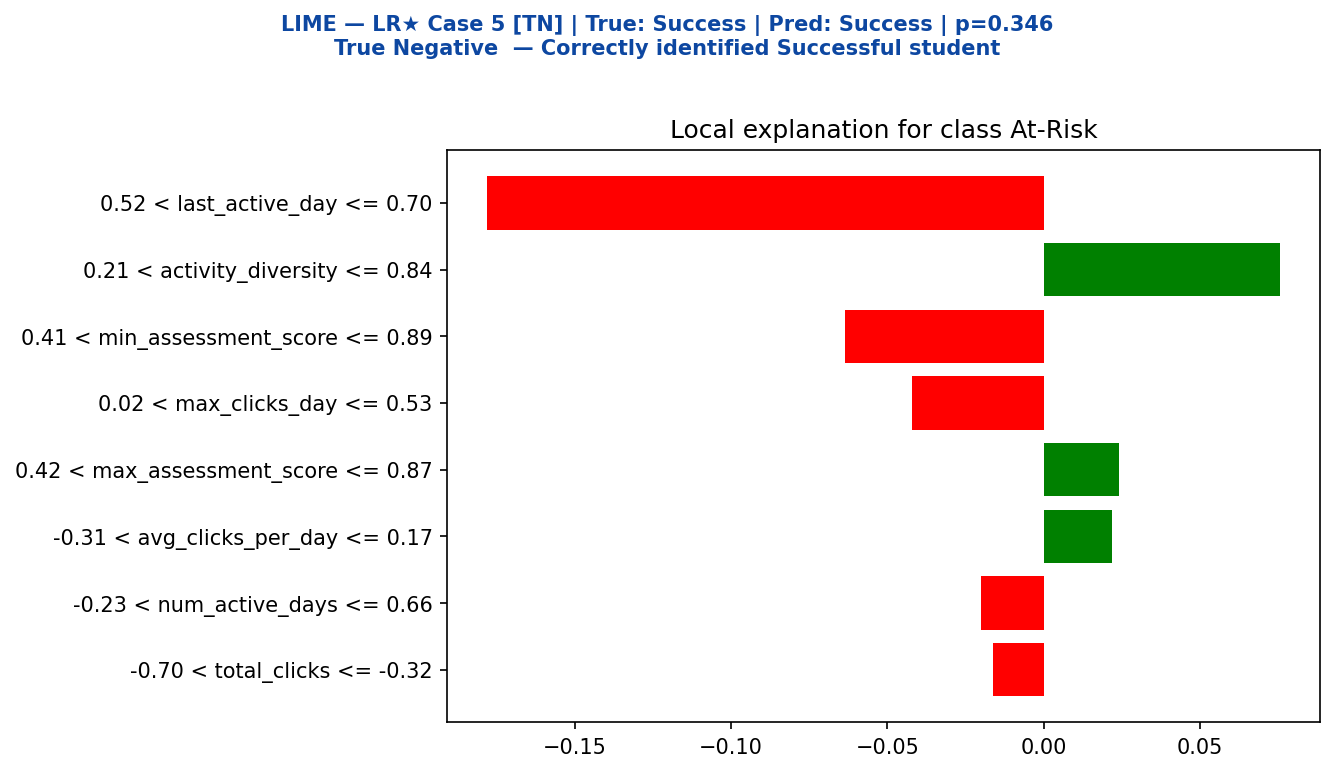

  Case 5 [TN] saved.


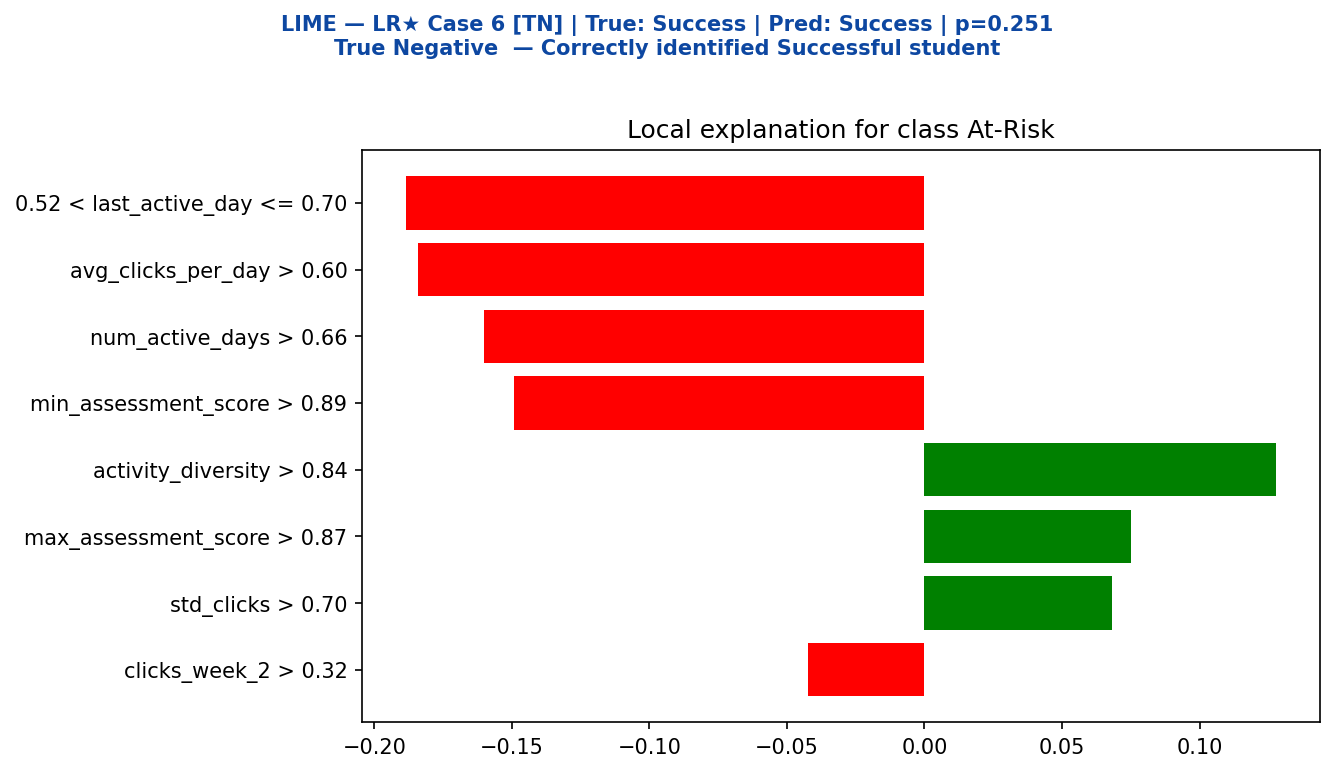

  Case 6 [TN] saved.


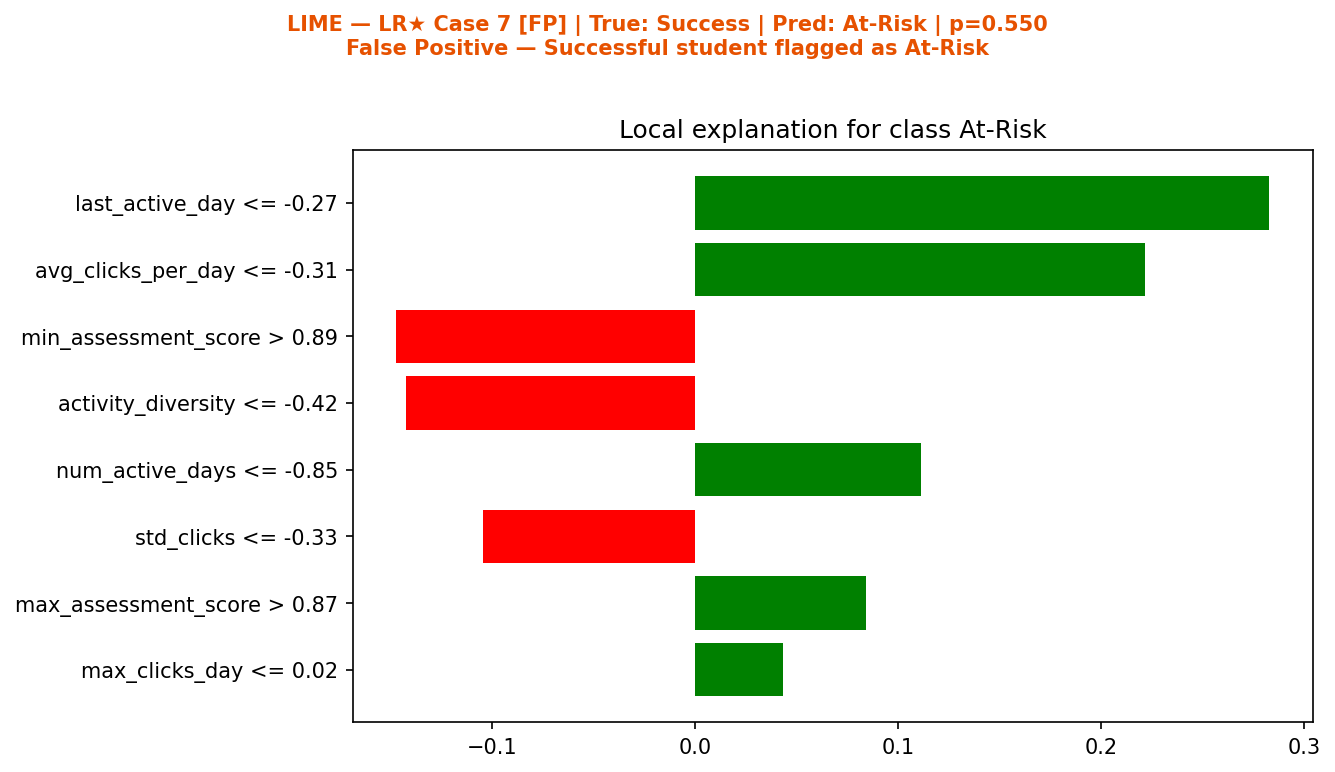

  Case 7 [FP] saved.


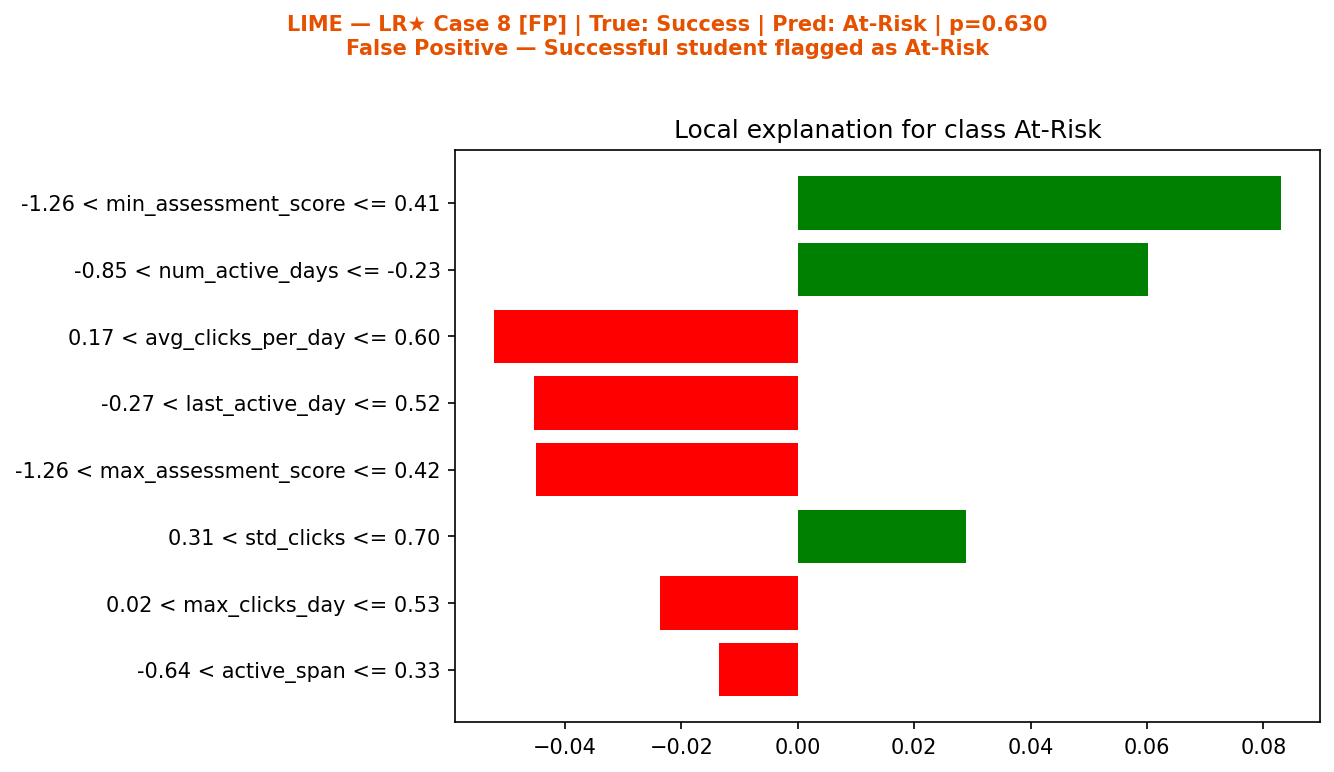

  Case 8 [FP] saved.


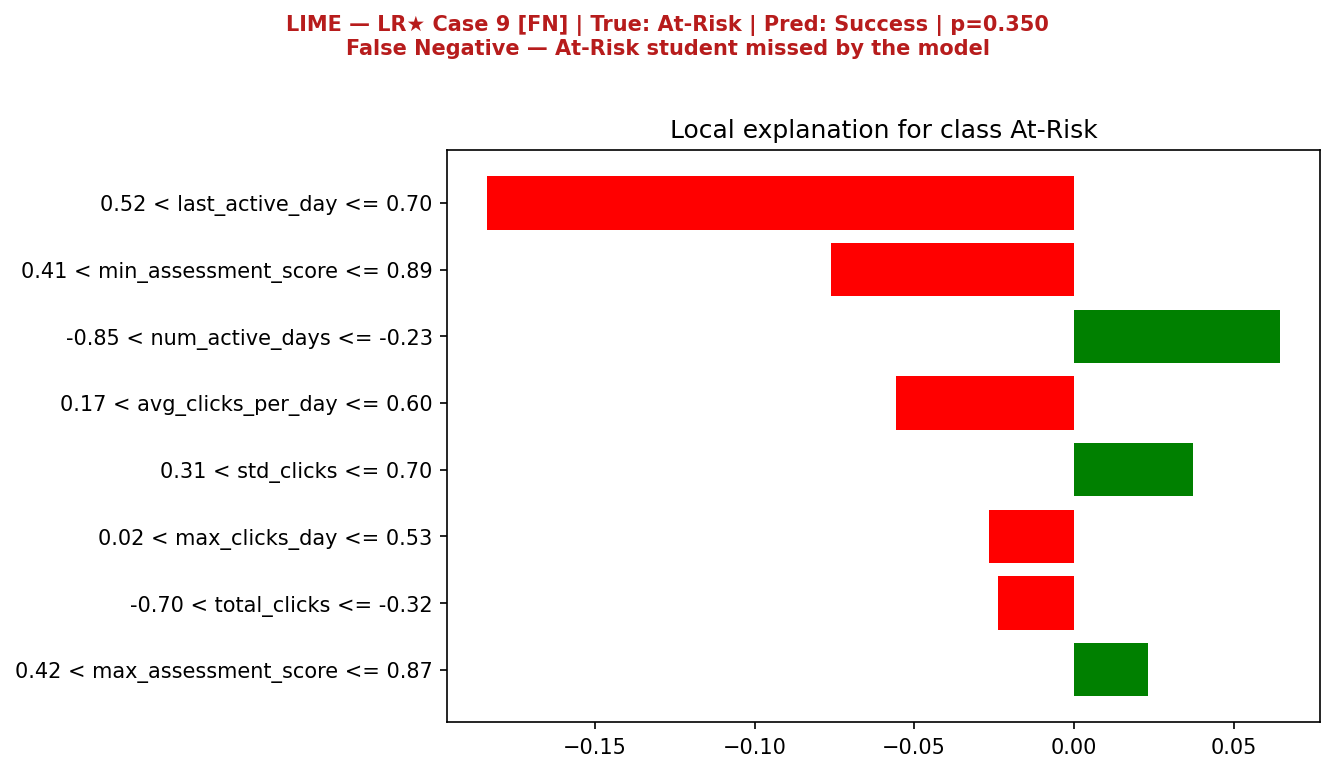

  Case 9 [FN] saved.


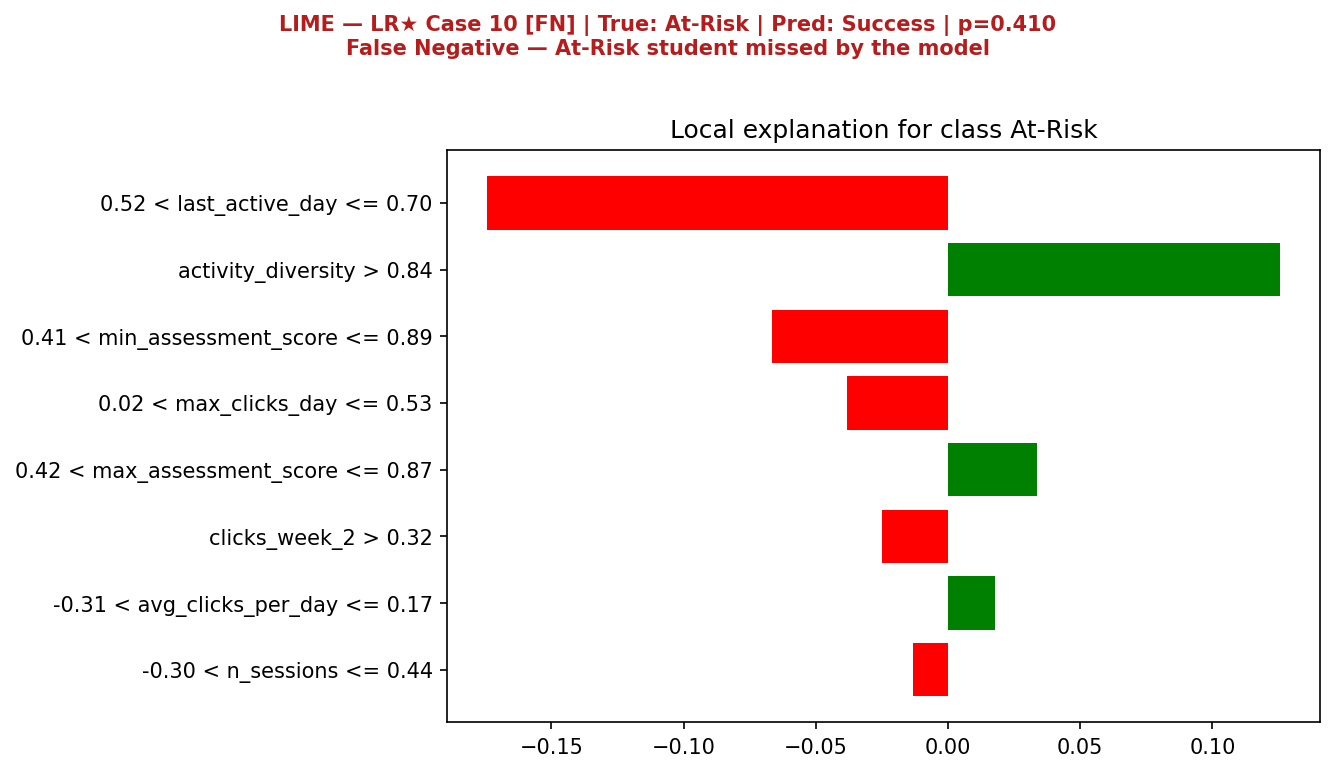

  Case 10 [FN] saved.


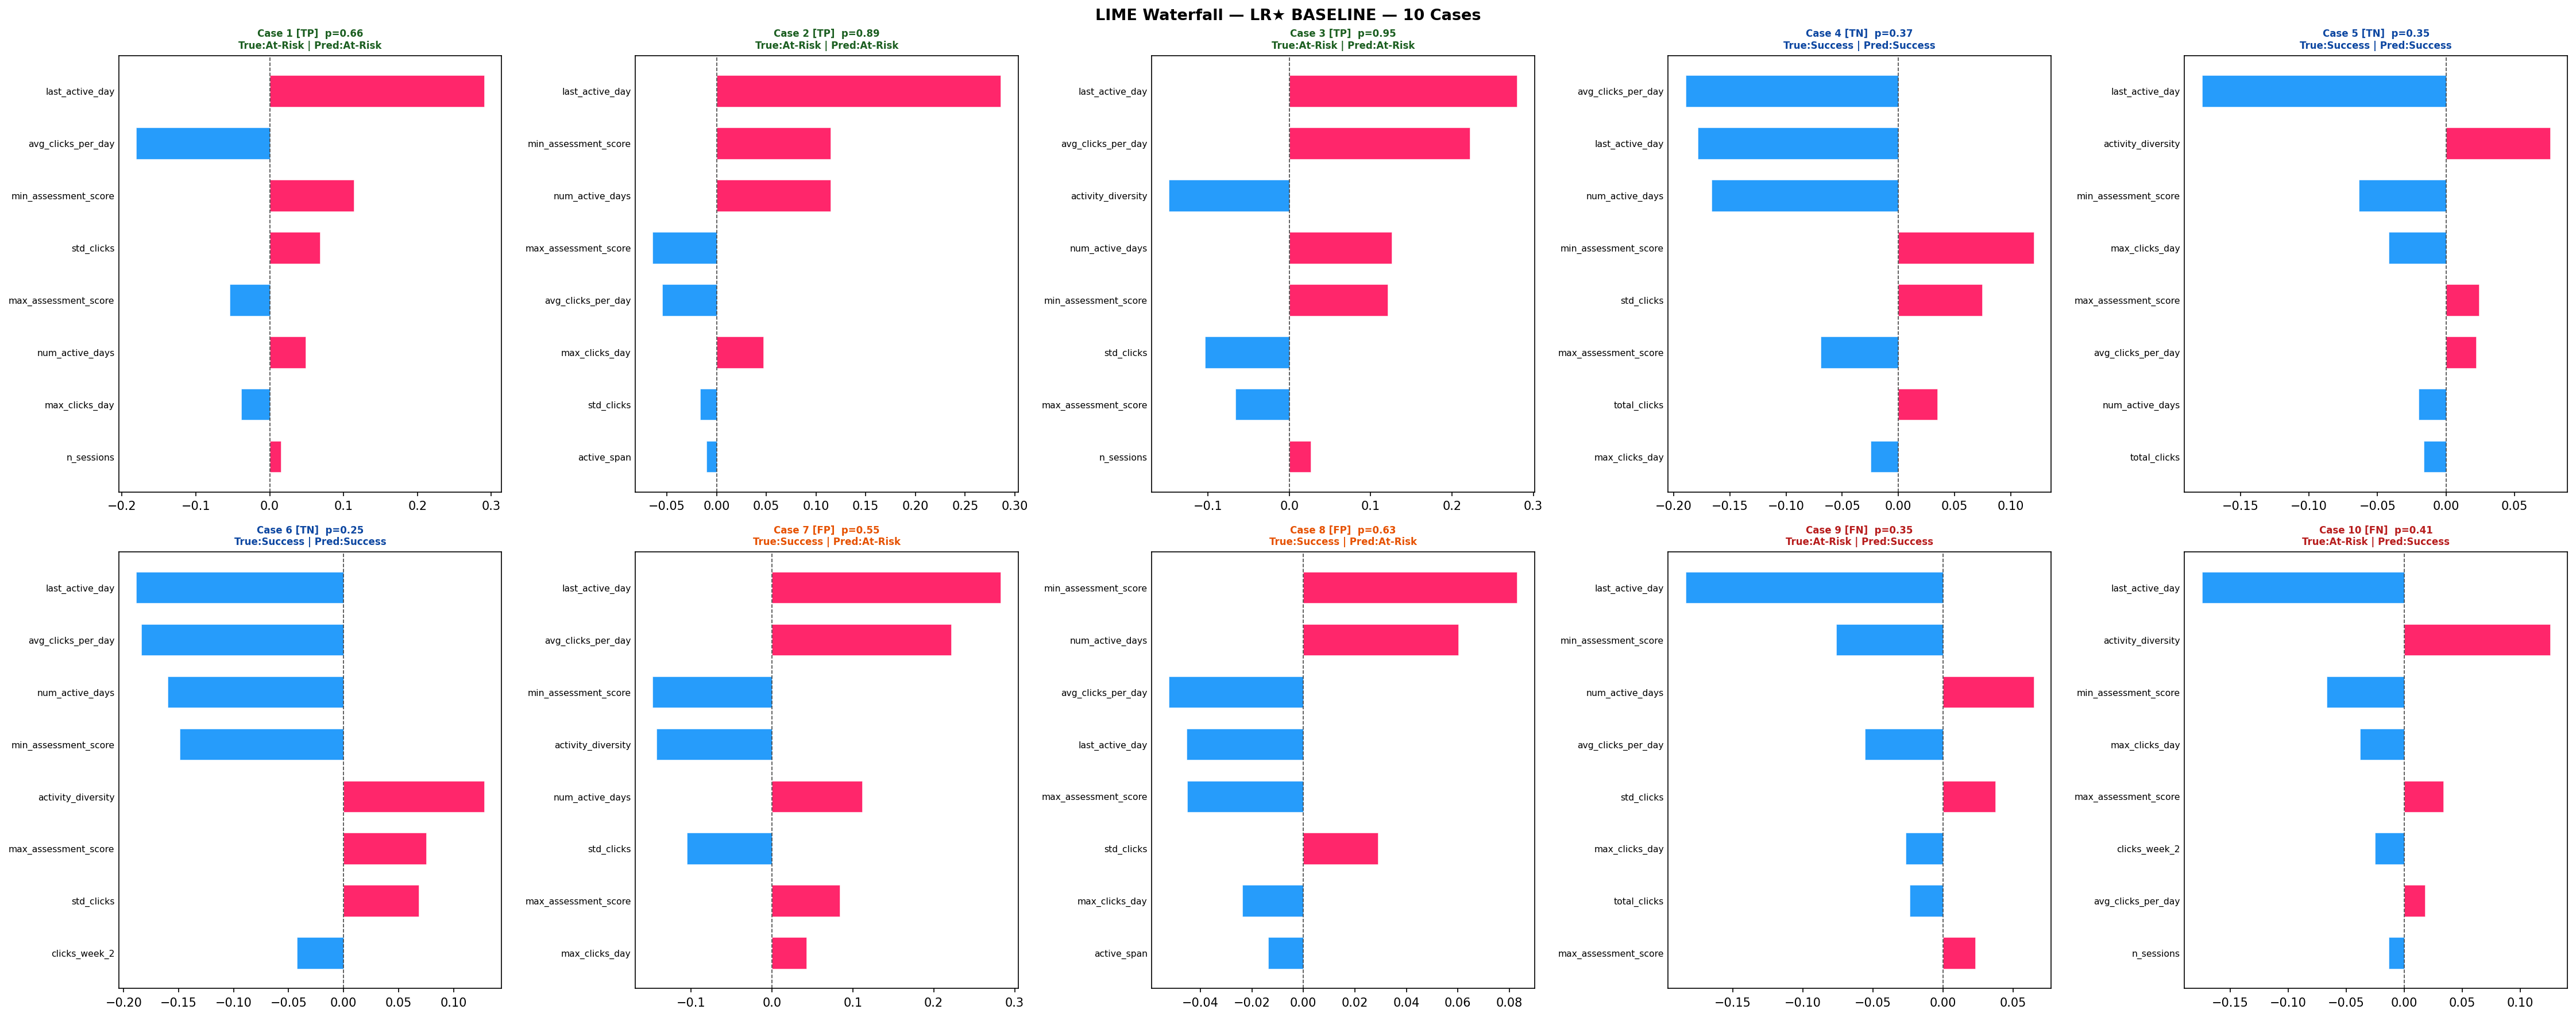


Global LIME (stratified n=300, 5000 perturbations) …
LIME auto-selected: 8 features
LIME analysis done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15 — LIME ANALYSIS
# LimeTabularExplainer — local linear surrogate
# ════════════════════════════════════════════════════════════════════════════
lime_exp = lime_tabular.LimeTabularExplainer(
    X_tr_p, feature_names=FEATURE_NAMES_SEL,
    class_names=['Success','At-Risk'], mode='classification', random_state=SEED)

def lime_fn(x):
    return lr_pipe.named_steps['clf'].predict_proba(x)

LIME_POS_COLOR = '#FF0051'
LIME_NEG_COLOR = '#008BFB'

X_test_orig = pd.DataFrame(
    scl_global.inverse_transform(imp_global.transform(
        X_test_sel.reset_index(drop=True) if hasattr(X_test_sel,'reset_index') else X_test_sel)),
    columns=FEATURE_NAMES_SEL)

lime_base_prob = float(lr_pipe.predict_proba(X_test_sel)[:,1].mean())

def _fmt_val(val):
    if val is None: return ''
    return f'{float(val):.3g}'

def _match_feature(feat_str, feature_names):
    for fn in feature_names:
        if fn in feat_str: return fn
    return feat_str[:30]

t0 = time.time()
lime_exps = []
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    e = lime_exp.explain_instance(X_te_lr[idx], lime_fn,
        num_features=len(auto_shap_lr), num_samples=LIME_PERTURB_SAMPLES, labels=(1,))
    lime_exps.append(e)
lime_total = time.time()-t0
print(f'10 LIME explanations: {lime_total:.1f}s ({lime_total/len(lime_exps):.2f}s/case)')

# ── Native LIME Style Plots ───────────────────────────────────────────────

print('Generating LIME local explanation plots (native LIME style) …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp = lime_exps[i]
    tl  = 'At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl  = 'At-Risk' if y_pred_lr[idx]==1 else 'Success'
    pp  = float(y_prob_lr[idx])

    # Native LIME figure — label=1 means "At-Risk" class
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(9, 5)

    # Informative title with case type colour
    fig.suptitle(
        f'LIME — LR★ Case {i+1} [{ctype}] | True: {tl} | Pred: {pl} | p={pp:.3f}\n'
        f'{type_label[ctype]}',
        fontsize=10, fontweight='bold',
        color=type_color[ctype], y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR/f'lime_local_lr_case_{i+1}_{ctype}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    plt.close()
    print(f'  Case {i+1} [{ctype}] saved.')

# Summary grid
fig,axes = plt.subplots(2,5,figsize=(30,12)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp = lime_exps[i]
    rows = sorted([(( _match_feature(fs,FEATURE_NAMES_SEL)),w) for fs,w in exp.as_list(label=1)],
                  key=lambda r:abs(r[1]),reverse=True)
    shown = rows[:8]; nms=[r[0][:24] for r in reversed(shown)]; vals=[r[1] for r in reversed(shown)]
    axes[i].barh(range(len(nms)),vals,
                 color=[LIME_POS_COLOR if v>=0 else LIME_NEG_COLOR for v in vals],
                 alpha=0.85,edgecolor='white',linewidth=0.3,height=0.6)
    axes[i].axvline(0,color='#444',lw=0.8,linestyle='--')
    axes[i].set_yticks(range(len(nms))); axes[i].set_yticklabels(nms,fontsize=7.5)
    axes[i].tick_params(axis='y',length=0)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_lr[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_lr[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
plt.suptitle('LIME Waterfall — LR★ BASELINE — 10 Cases',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'lime_local_lr_10cases.png',dpi=150,bbox_inches='tight')
plt.show()

# Global LIME — stratified sample, LIME-default perturbations
print(f'\nGlobal LIME (stratified n={LIME_GLOBAL_N}, {LIME_PERTURB_SAMPLES} perturbations) …')
N_LIME_G = LIME_GLOBAL_N
lime_weights_global = {f:[] for f in FEATURE_NAMES_SEL}
np.random.seed(SEED)
for idx2 in stratified_sample_indices(y_test_arr, N_LIME_G, SEED):
    e = lime_exp.explain_instance(X_te_lr[idx2],lime_fn,
        num_features=len(auto_shap_lr),num_samples=LIME_PERTURB_SAMPLES,labels=(1,))
    for fs,w in e.as_list(label=1):
        fn = _match_feature(fs,FEATURE_NAMES_SEL)
        if fn in lime_weights_global: lime_weights_global[fn].append(abs(w))

lime_global = pd.Series({k:np.mean(v) if v else 0.0 for k,v in lime_weights_global.items()}).sort_values(ascending=False)
lime_thresh = lime_global.mean()+lime_global.std()
auto_lime   = lime_global[lime_global>=lime_thresh]
if len(auto_lime)<MIN_FEATURES: auto_lime = lime_global.iloc[:MIN_FEATURES]
auto_lime.to_csv(CSV_DIR/'lime_top_lr.csv',header=['LIME_Importance'])
print(f'LIME auto-selected: {len(auto_lime)} features')
print('LIME analysis done.')


Computing global LIME — 5 models × 300 samples …
Done.
LR★=8 XGB=8 DT=8 
RF=8  SVM=8

LIME Consensus (≥3/5 models): 7 features
LIME Union (all selected)    : 15 features

LIME Consensus Ranking Table:
                      LR★  XGB  DT  RF  SVM  Vote_Count  Avg_Rank
last_active_day         1    1   2   1    1           5    1.2000
min_assessment_score    4    2   3   2    2           5    2.6000
avg_clicks_per_day      2    7   5   6    5           5    5.0000
activity_diversity      3    3   4   9    7           4    5.2000
num_active_days         5    6   6   8    6           5    6.2000
avg_assessment_score   13    4   1   3   10           3    6.2000
weighted_avg_score     12    5  13   4    3           3    7.4000


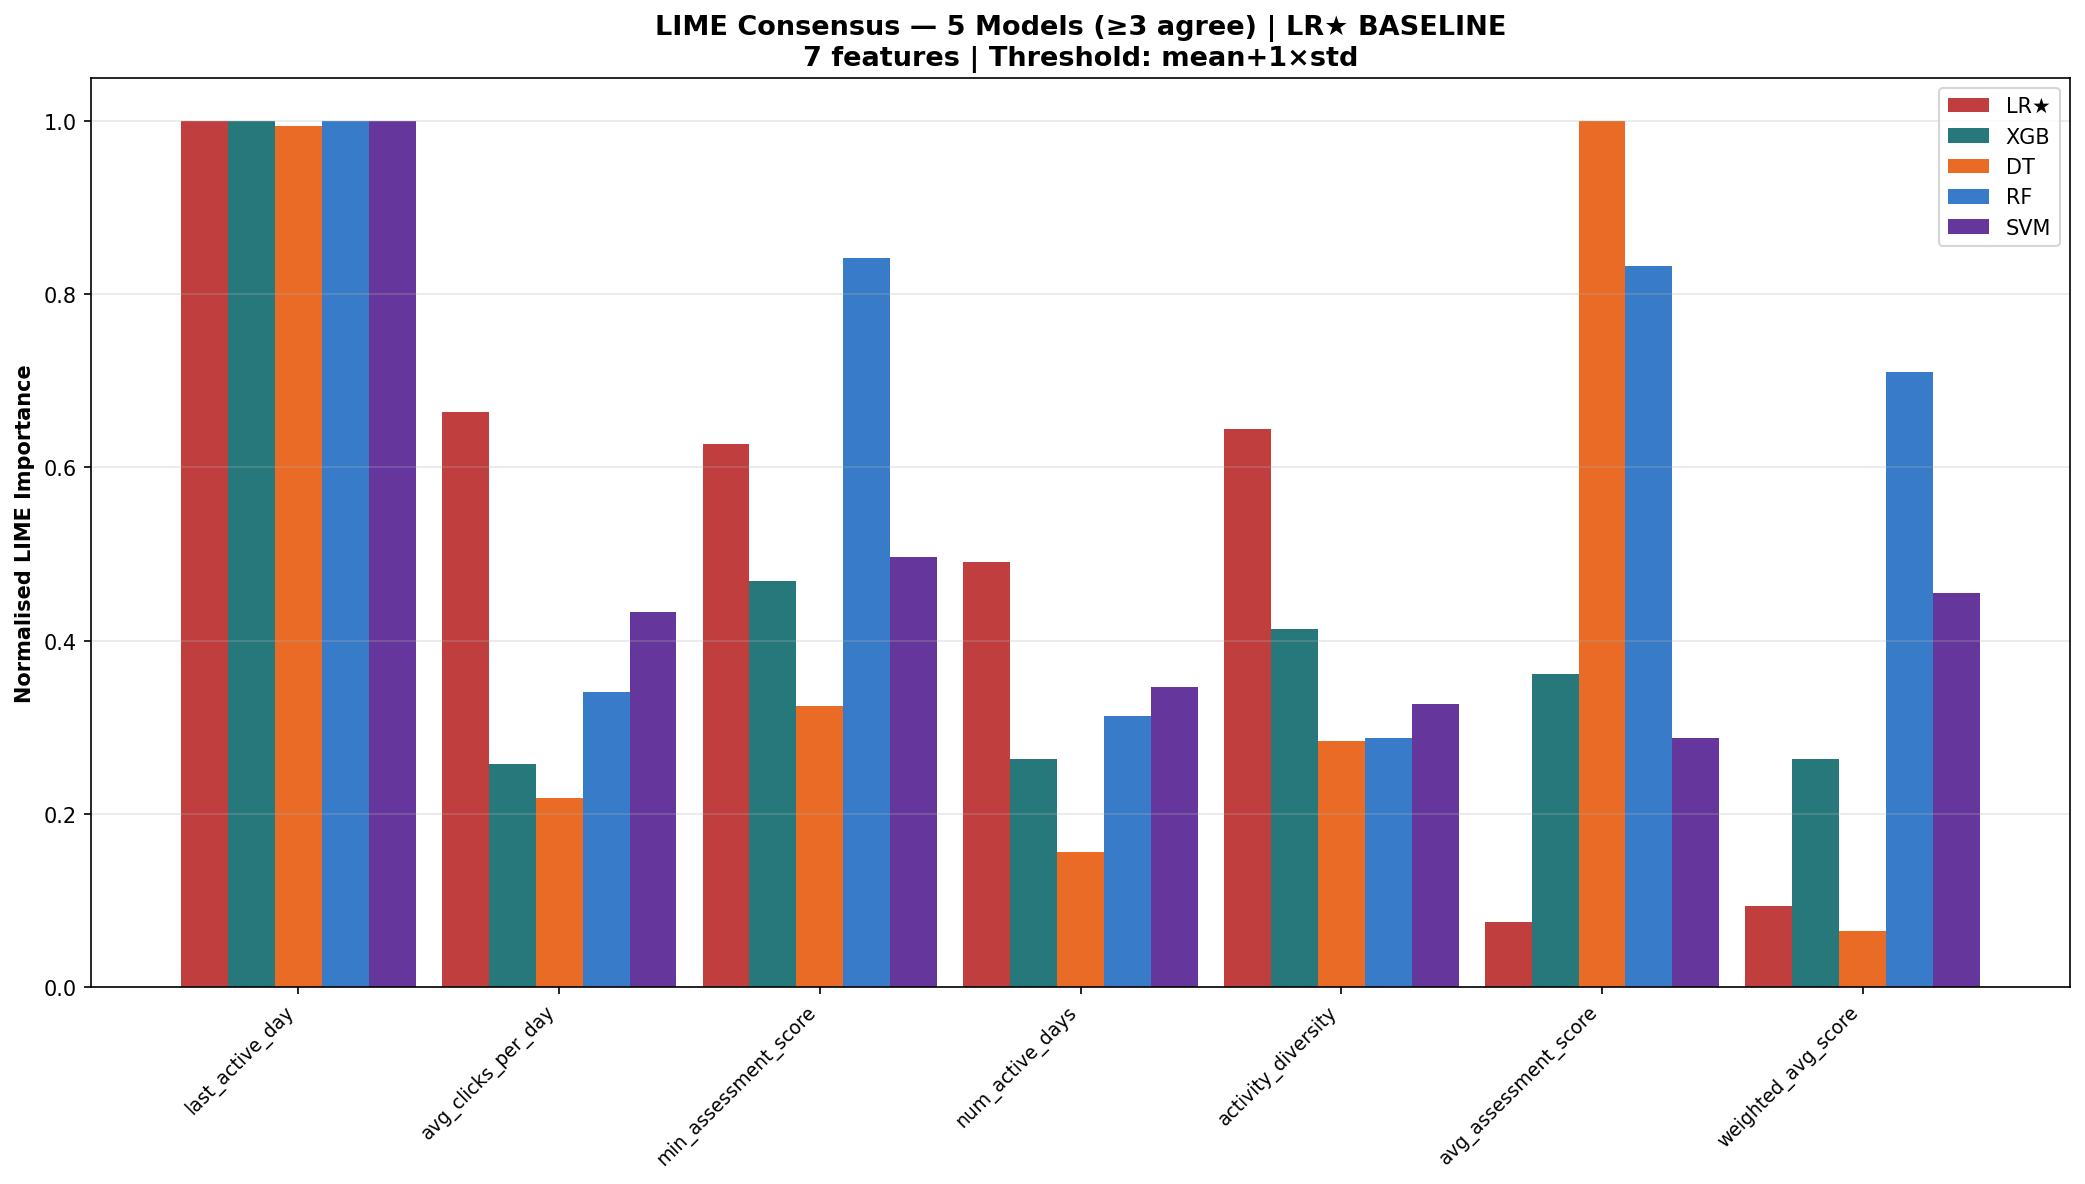

LIME Consensus plot saved.


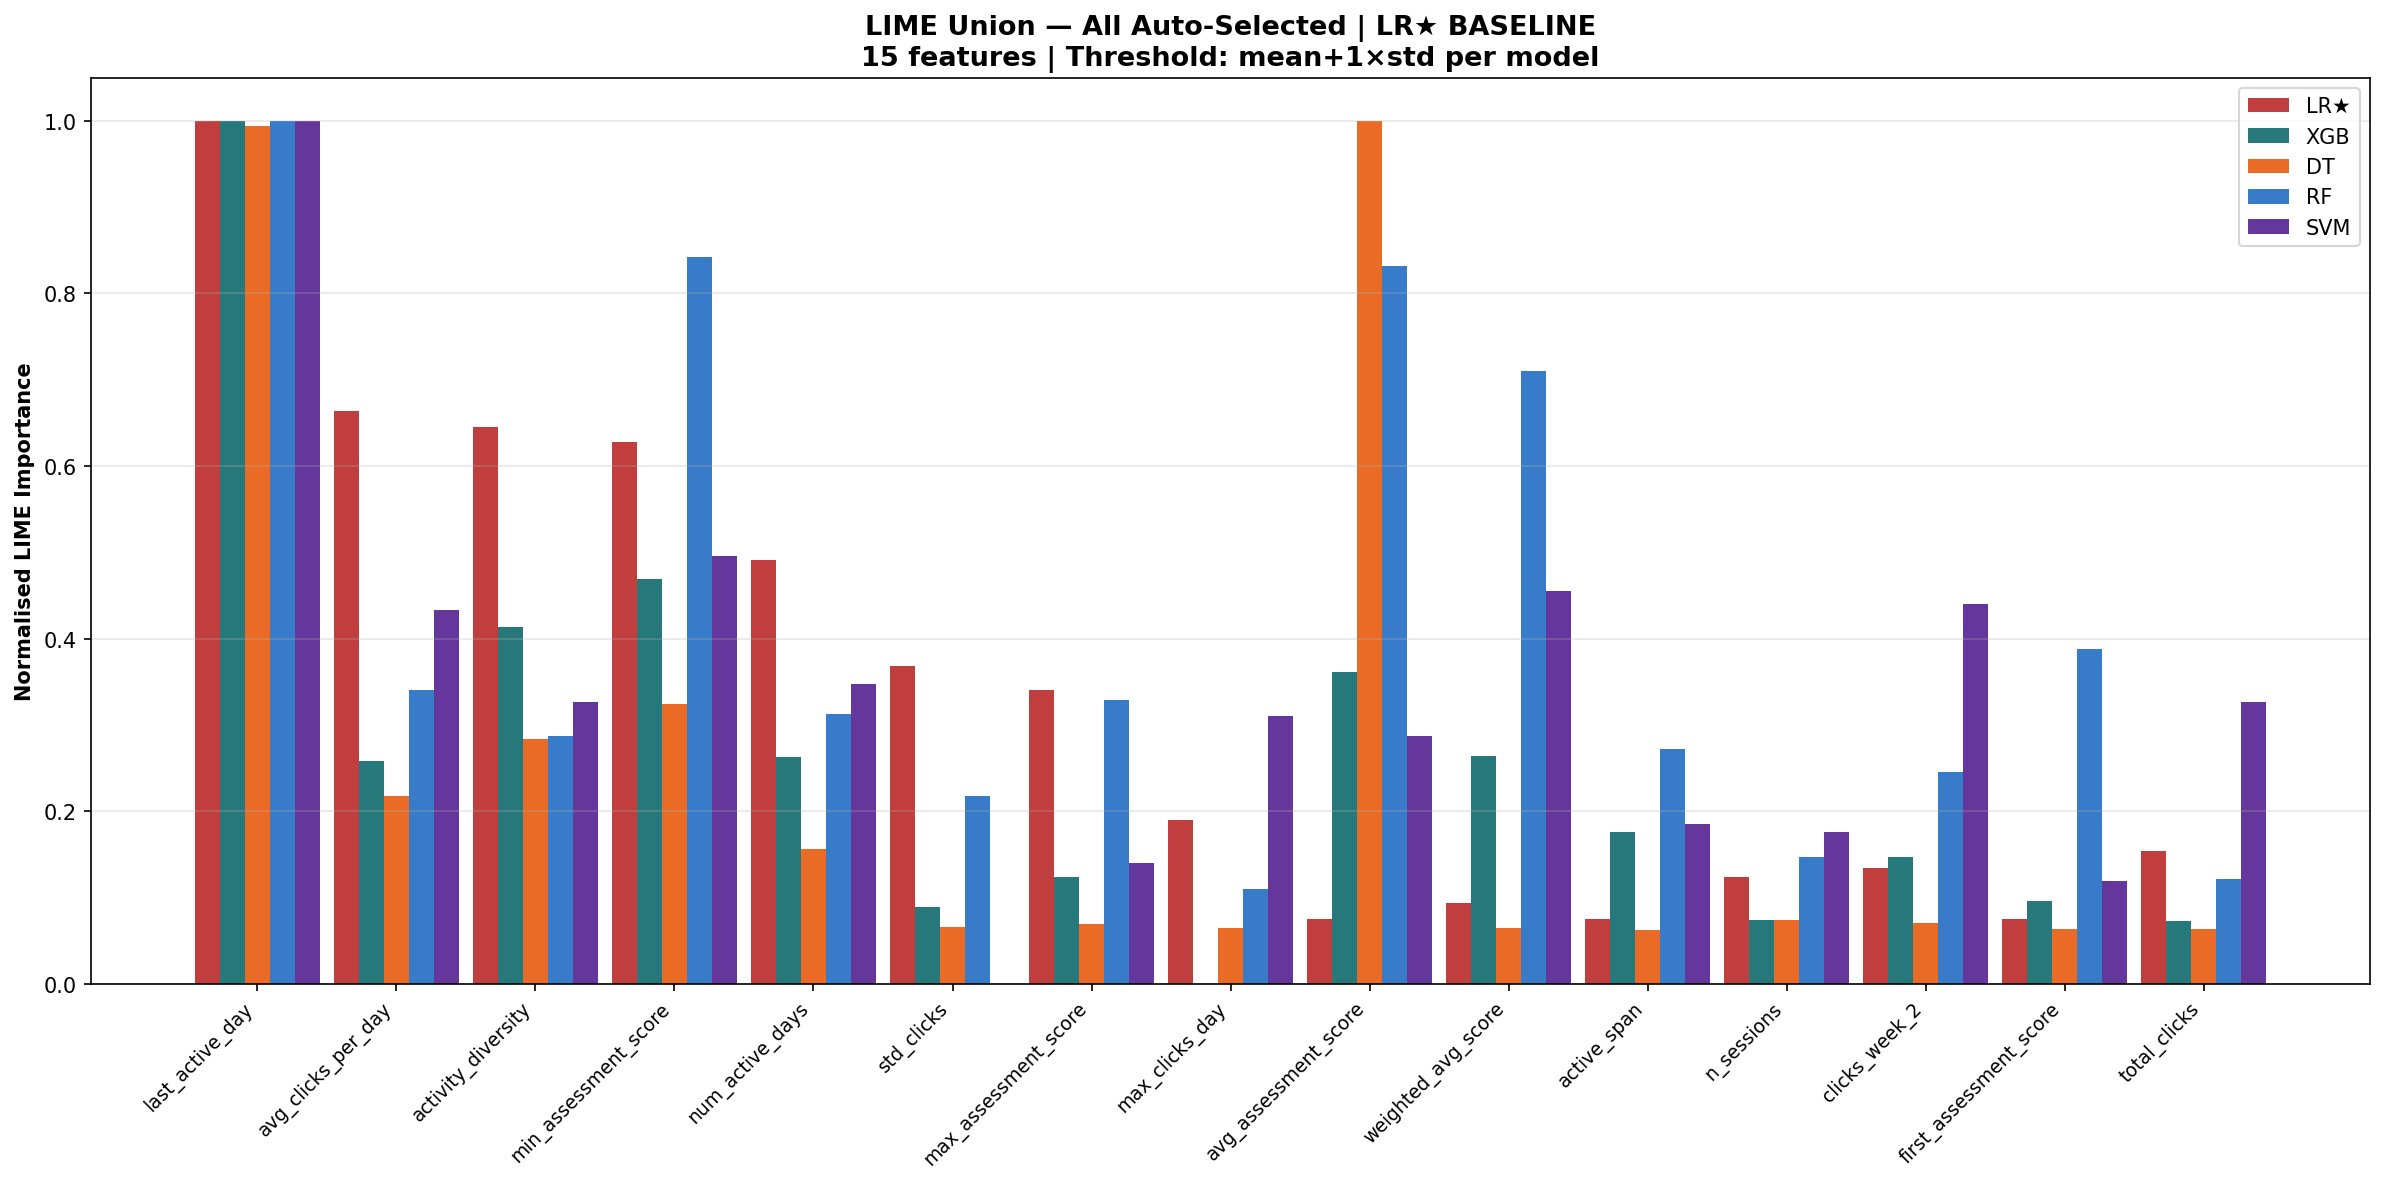

LIME Union plot saved.


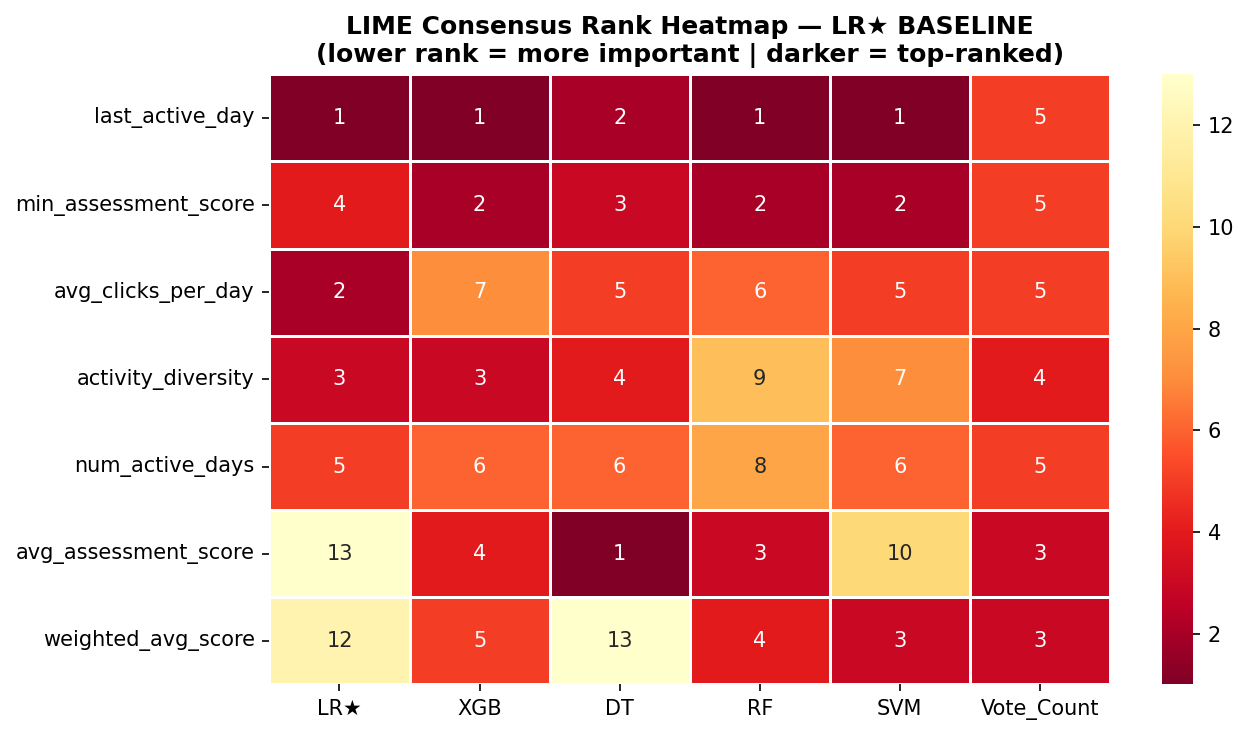

Heatmap saved.

LIME Rankings complete — Consensus:7 | Union:15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LIME AUTO-SELECTED RANKINGS + CONSENSUS (All 5 Models
# ════════════════════════════════════════════════════════════════════════════
from collections import Counter as _LCtr

def _lime_global_5(predict_fn, X_eval, y_eval=None, n=LIME_GLOBAL_N, n_feat=8, n_samp=LIME_PERTURB_SAMPLES, seed=42):
    """Aggregate LIME importances over n instances.
    predict_fn must return (n_samples, n_classes) array — NOT [:,1] slice.
    LIME internally selects class via labels=(1,).
    """
    np.random.seed(seed)
    le = lime_tabular.LimeTabularExplainer(
        X_tr_p, feature_names=FEATURE_NAMES_SEL,
        class_names=['Success','At-Risk'], mode='classification', random_state=seed)
    wts = {f: [] for f in FEATURE_NAMES_SEL}
    if n is None or n >= len(X_eval):
        _eval_idx = np.arange(len(X_eval))
    elif y_eval is not None:
        _eval_idx = stratified_sample_indices(y_eval, n, seed)
    else:
        _eval_idx = np.random.choice(len(X_eval), n, replace=False)
    for idx2 in _eval_idx:
        e = le.explain_instance(X_eval[idx2], predict_fn,
            num_features=n_feat, num_samples=n_samp, labels=(1,))
        for fs, w in e.as_list(label=1):
            fn = _match_feature(fs, FEATURE_NAMES_SEL)
            if fn in wts: wts[fn].append(abs(w))
    return pd.Series({k: np.mean(v) if v else 0.0
                      for k,v in wts.items()}).sort_values(ascending=False)

def _auto_lime(s, min_f=MIN_FEATURES):
    sel = s[s >= s.mean()+s.std()]
    return sel if len(sel)>=min_f else s.iloc[:min_f]

# ── Global LIME for all 5 models ──────────────────────────────────────────

print('Computing global LIME — 5 models × 300 samples …')

lg_lr  = lime_global

lg_xgb = _lime_global_5(
    lambda x: trained_models['XGBoost'].named_steps['clf'].predict_proba(x),
    X_te_lr, y_test_arr, seed=SEED)

lg_dt  = _lime_global_5(
    lambda x: trained_models['Decision Tree'].named_steps['clf'].predict_proba(x),
    X_te_lr, y_test_arr, seed=SEED)

lg_rf  = _lime_global_5(
    lambda x: trained_models['Random Forest'].named_steps['clf'].predict_proba(x),
    X_te_lr, y_test_arr, seed=SEED)

lg_svm = _lime_global_5(
    lambda x: trained_models['SVM'].named_steps['clf'].predict_proba(x),
    X_te_lr, y_test_arr, seed=SEED)

print('Done.')

# ── Auto-select per model ─────────────────────────────────────────────────
al_lr  = _auto_lime(lg_lr);  al_xgb = _auto_lime(lg_xgb)
al_dt  = _auto_lime(lg_dt);  al_rf  = _auto_lime(lg_rf)
al_svm = _auto_lime(lg_svm)

print(f'LR★={len(al_lr)} XGB={len(al_xgb)} DT={len(al_dt)} ')
print(f'RF={len(al_rf)}  SVM={len(al_svm)}')

for nm, s in [('lr',al_lr),('xgb',al_xgb),('dt',al_dt),('rf',al_rf),('svm',al_svm)]:
    s.to_csv(CSV_DIR/f'lime_top_{nm}.csv', header=['LIME_Importance'])

# ── Consensus ≥3 of 5 models ──────────────────────────────────────────────
all_lf   = (list(al_lr.index)+list(al_xgb.index)+list(al_dt.index)+
            list(al_rf.index)+list(al_svm.index))
lv       = _LCtr(all_lf)
lcons    = [f for f,c in sorted(lv.items(),key=lambda x:-x[1]) if c>=3]
lunion   = list(dict.fromkeys(all_lf))

print(f'\nLIME Consensus (≥3/5 models): {len(lcons)} features')
print(f'LIME Union (all selected)    : {len(lunion)} features')

# ── Ranking table ─────────────────────────────────────────────────────────
lranks = [(lg_lr,'LR★','#B71C1C'),(lg_xgb,'XGB','#006064'),
           (lg_dt,'DT', '#E65100'),(lg_rf, 'RF', '#1565C0'),
           (lg_svm,'SVM','#4A148C')]
bw = 0.18

if lcons:
    rtbl = pd.DataFrame({lb: s.rank(ascending=False).astype(int)
                         for s,lb,_ in lranks}, index=FEATURE_NAMES_SEL).loc[lcons]
    rtbl['Avg_Rank']   = rtbl.mean(axis=1)
    rtbl['Vote_Count'] = [lv[f] for f in lcons]
    rtbl = rtbl.sort_values('Avg_Rank')
    rtbl.to_csv(CSV_DIR/'lime_consensus_ranking.csv')
    print('\nLIME Consensus Ranking Table:')
    print(rtbl[['LR★','XGB','DT','RF','SVM','Vote_Count','Avg_Rank']].to_string())

# ── Plot 1: Consensus ─────────────────────────────────────────────────────
if lcons:
    fig, ax = plt.subplots(figsize=(max(14,len(lcons)),8))
    x = np.arange(len(lcons))
    for ii,(rank,lb,col) in enumerate(lranks):
        ax.bar(x+(ii-2)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in lcons],
               bw,label=lb,color=col,alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in lcons],rotation=45,ha='right',fontsize=9)
    ax.set_ylabel('Normalised LIME Importance',fontweight='bold')
    ax.set_title(f'LIME Consensus — 5 Models (≥3 agree) | LR★ BASELINE\n'
                 f'{len(lcons)} features | Threshold: mean+1×std',
                 fontsize=13,fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'lime_consensus_features.png',dpi=150,bbox_inches='tight')
    plt.show(); print('LIME Consensus plot saved.')

# ── Plot 2: Union ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16,len(lunion)),8))
x = np.arange(len(lunion))
for ii,(rank,lb,col) in enumerate(lranks):
    ax.bar(x+(ii-2)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in lunion],
           bw,label=lb,color=col,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in lunion],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised LIME Importance',fontweight='bold')
ax.set_title(f'LIME Union — All Auto-Selected | LR★ BASELINE\n'
             f'{len(lunion)} features | Threshold: mean+1×std per model',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'lime_all_models_comparison.png',dpi=150,bbox_inches='tight')
plt.show(); print('LIME Union plot saved.')

# ── Heatmap ───────────────────────────────────────────────────────────────
if lcons:
    fig,ax = plt.subplots(figsize=(9,max(5,len(lcons)*0.5)))
    sns.heatmap(rtbl.sort_values('Avg_Rank')[['LR★','XGB','DT','RF','SVM','Vote_Count']],
                annot=True,fmt='.0f',cmap='YlOrRd_r',linewidths=0.5,ax=ax)
    ax.set_title('LIME Consensus Rank Heatmap — LR★ BASELINE\n'
                 '(lower rank = more important | darker = top-ranked)',fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'lime_rank_heatmap.png',dpi=150,bbox_inches='tight')
    plt.show(); print('Heatmap saved.')


lime_global_xgb = lg_xgb

lunion = list(dict.fromkeys(
    list(al_lr.index)+list(al_xgb.index)+list(al_dt.index)+
    list(al_rf.index)+list(al_svm.index)))
print(f'\nLIME Rankings complete — Consensus:{len(lcons)} | Union:{len(lunion)}')


SHAP auto-selected : 8
LIME auto-selected : 8
Union              : 8
★ Both methods     : 8
Kendall's τ = 0.4286  p = 0.1789
Interpretation: Not statistically significant (p=0.179)
  → SHAP and LIME capture different explanatory perspectives; applying both methods in tandem is warranted.


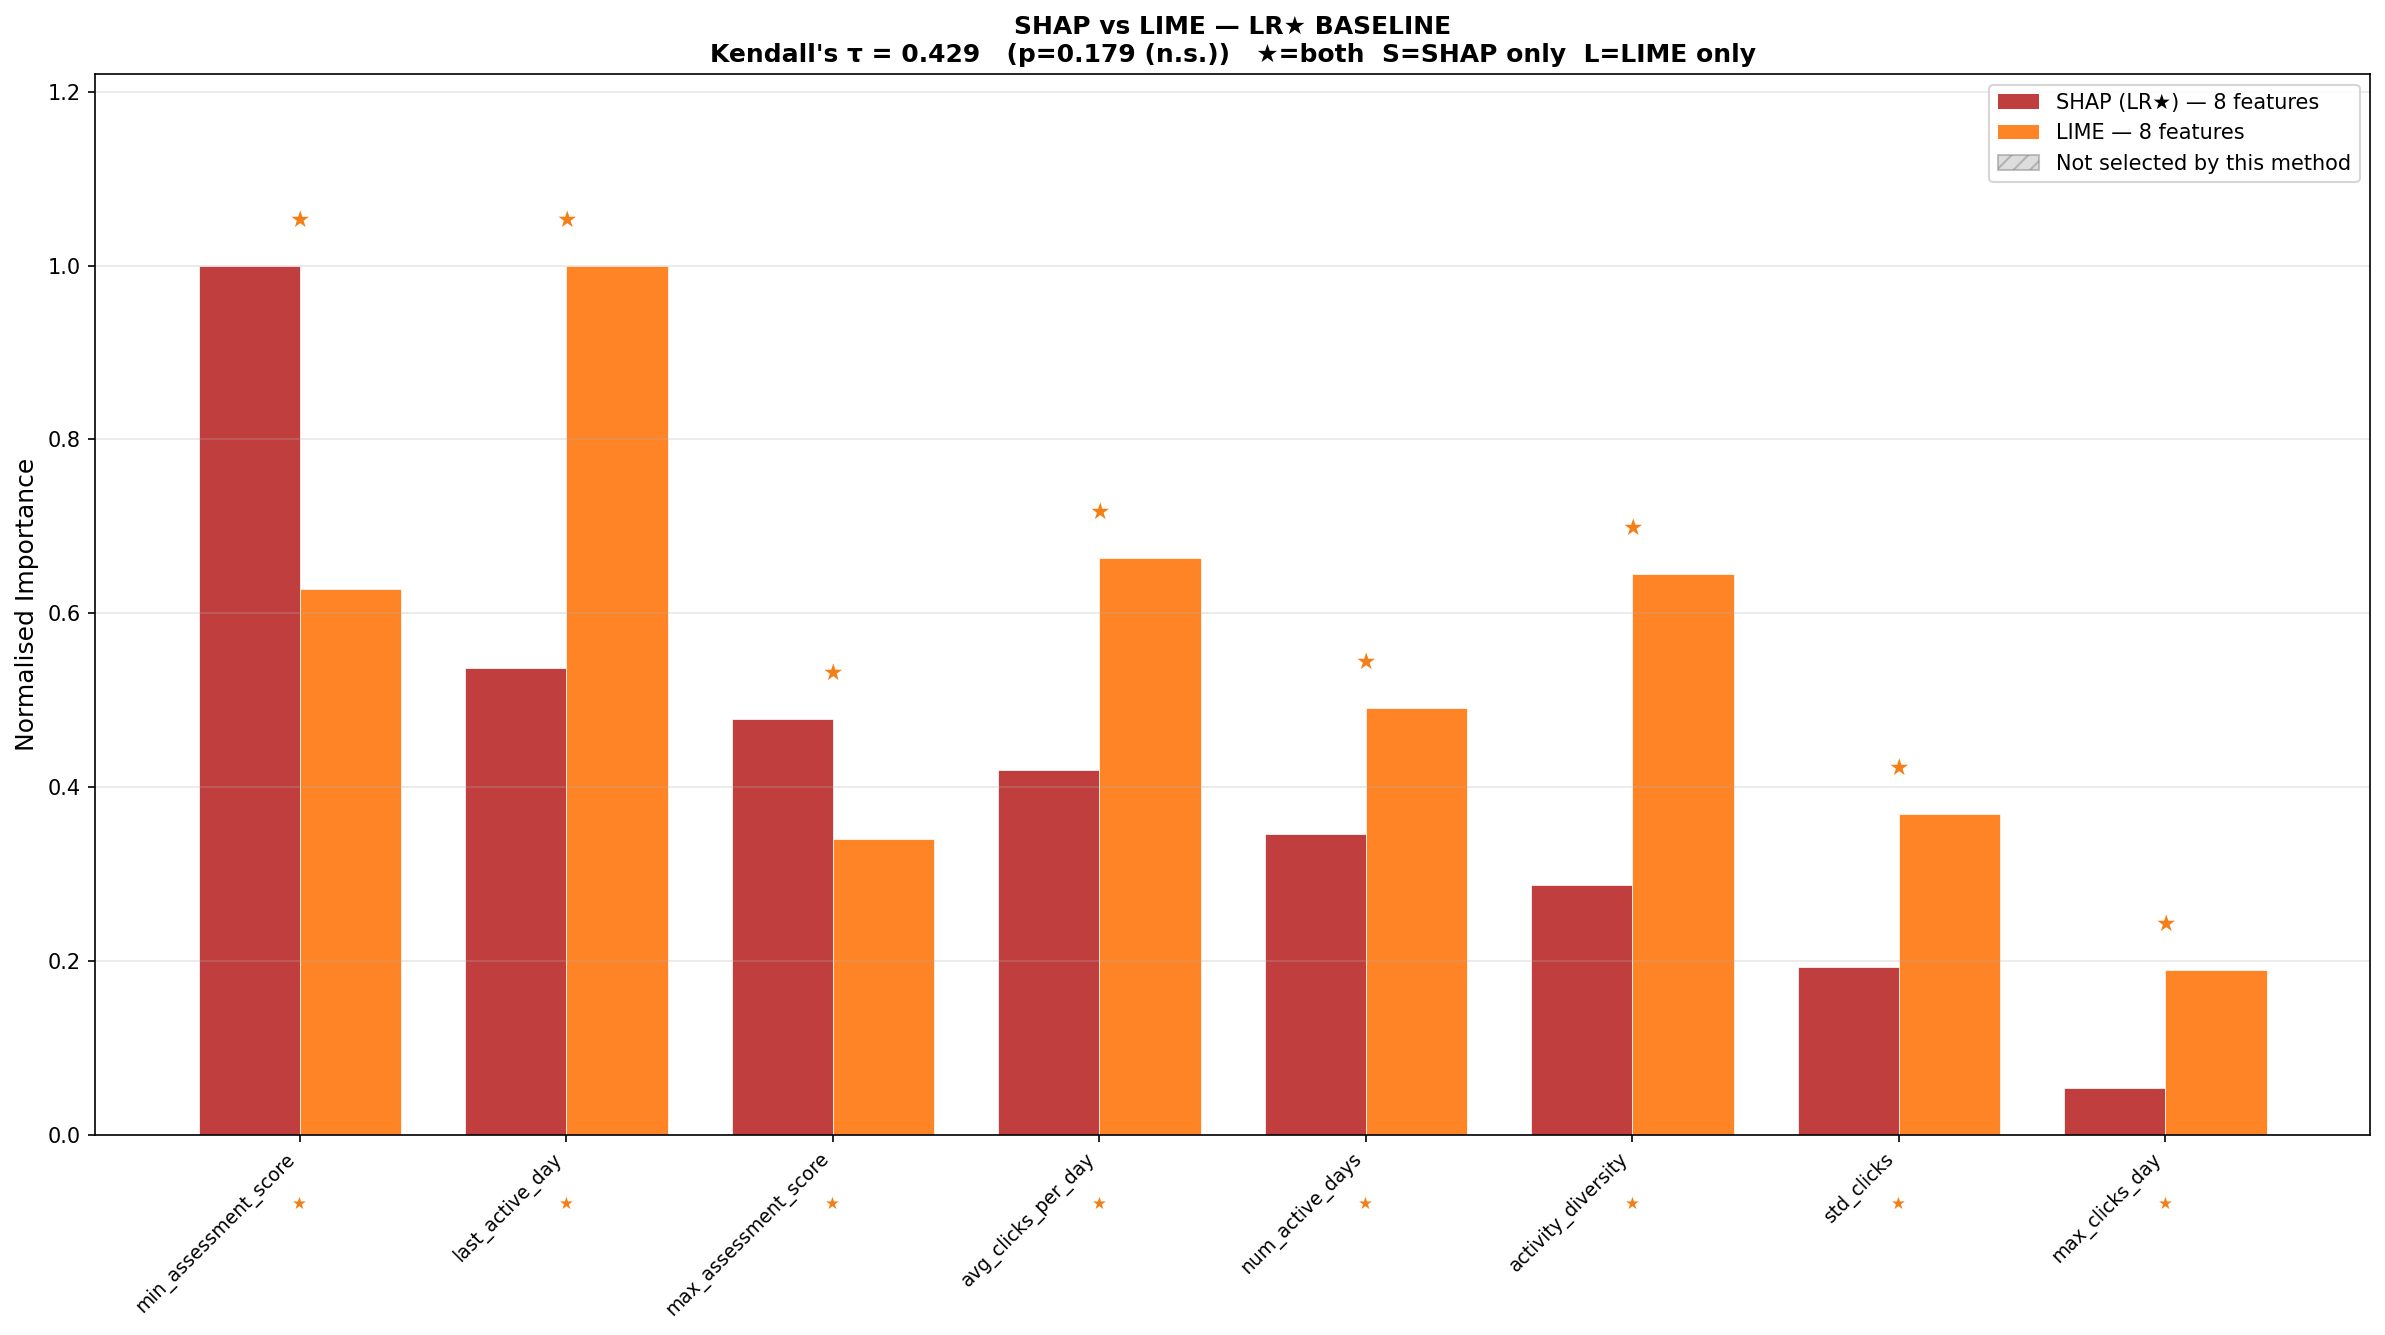

Comparison saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — SHAP vs LIME COMPARISON + Kendall's τ
# ════════════════════════════════════════════════════════════════════════════
union        = list(dict.fromkeys(list(auto_shap_lr.index)+list(auto_lime.index)))
intersection = [f for f in union if f in auto_shap_lr.index and f in auto_lime.index]
shap_only    = [f for f in union if f in auto_shap_lr.index and f not in auto_lime.index]
lime_only    = [f for f in union if f in auto_lime.index    and f not in auto_shap_lr.index]

print(f'SHAP auto-selected : {len(auto_shap_lr)}')
print(f'LIME auto-selected : {len(auto_lime)}')
print(f'Union              : {len(union)}')
print(f'★ Both methods     : {len(intersection)}')

sr  = {f:i+1 for i,f in enumerate(shap_rank_lr.index)}
lr2 = {f:i+1 for i,f in enumerate(lime_global.index)}
tau,pv = kendalltau([sr[f] for f in union],[lr2[f] for f in union])
if pv<0.05:
    strength = "strong" if abs(tau)>0.6 else "moderate" if abs(tau)>0.3 else "weak"
    sig_note = f"Statistically significant (p={pv:.3f}) — {strength} rank agreement"
else:
    sig_note = (f"Not statistically significant (p={pv:.3f})\n"
                "  → SHAP and LIME capture different explanatory perspectives; "
                "applying both methods in tandem is warranted.")
print(f"Kendall's τ = {tau:.4f}  p = {pv:.4f}")
print(f"Interpretation: {sig_note}")

shap_max = shap_rank_lr[union].max() or 1.0
lime_max = lime_global[union].max()  or 1.0
sv_p  = (shap_rank_lr.reindex(union).fillna(0)/shap_max).tolist()
lv_p  = (lime_global.reindex(union).fillna(0)/lime_max).tolist()

SHAP_COLOR = '#B71C1C'; LIME_COLOR = '#FF6F00'; GREY_COLOR = '#BDBDBD'
from matplotlib.patches import Patch

fig,ax = plt.subplots(figsize=(max(16,len(union)),9))
x = np.arange(len(union)); w = 0.38

for j,f in enumerate(union):
    cat = ('both' if f in intersection else 'shap_only' if f in shap_only else 'lime_only')
    sc = SHAP_COLOR if cat in ('both','shap_only') else GREY_COLOR
    lc = LIME_COLOR if cat in ('both','lime_only') else GREY_COLOR
    sh = '' if cat in ('both','shap_only') else '///'
    lh = '' if cat in ('both','lime_only') else '///'
    ax.bar(x[j]-w/2,sv_p[j],w,color=sc,alpha=0.85,hatch=sh,edgecolor='white',linewidth=0.4)
    ax.bar(x[j]+w/2,lv_p[j],w,color=lc,alpha=0.85,hatch=lh,edgecolor='white',linewidth=0.4)
    if cat=='both':
        ax.text(x[j],max(sv_p[j],lv_p[j])+0.045,'★',ha='center',fontsize=11,color='#F57F17',fontweight='bold')

legend_elements = [
    Patch(facecolor=SHAP_COLOR,alpha=0.85,label=f'SHAP (LR★) — {len(auto_shap_lr)} features'),
    Patch(facecolor=LIME_COLOR,alpha=0.85,label=f'LIME — {len(auto_lime)} features'),
    Patch(facecolor=GREY_COLOR,alpha=0.5,hatch='///',edgecolor='#888',label='Not selected by this method'),
]
ax.legend(handles=legend_elements,fontsize=10,loc='upper right')

for j,f in enumerate(union):
    label = '★' if f in intersection else 'S' if f in shap_only else 'L'
    ax.text(x[j],-0.07,label,ha='center',fontsize=8,
            color='#F57F17' if f in intersection else SHAP_COLOR if f in shap_only else LIME_COLOR,
            fontweight='bold',transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels([f[:25] for f in union],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised Importance',fontsize=12); ax.set_ylim(0,1.22); ax.grid(axis='y',alpha=0.3)
sig_str = f"p<0.05 ✓" if pv<0.05 else f"p={pv:.3f} (n.s.)"
ax.set_title(f"SHAP vs LIME — LR★ BASELINE\n"
             f"Kendall's τ = {tau:.3f}   ({sig_str})   ★=both  S=SHAP only  L=LIME only",
             fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_lime_comparison_LR.png',dpi=150,bbox_inches='tight')
plt.show()

comp = pd.DataFrame({
    'Feature'    : union,
    'Selected_By': ['Both' if f in intersection else 'SHAP only' if f in shap_only else 'LIME only' for f in union],
    'SHAP_norm'  : sv_p, 'LIME_norm': lv_p,
    'SHAP_rank'  : [sr[f] for f in union],
    'LIME_rank'  : [lr2[f] for f in union],
})
comp.to_csv(CSV_DIR/'shap_lime_comparison_LR.csv',index=False)
print('Comparison saved.')


  [F1] Fixed points (threshold 0.50): TP=8, TN=8, FP=7, FN=7  | total=30
  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1
Bootstrap: 100 iters x 30 fixed pts | SHAP=KernelExplainer | LIME=1000 samples
------------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 10/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 20/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 30/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 40/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 50/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 60/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 70/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 80/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [ 90/100] done


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  [100/100] done

[F5] No LIME explanation failures.

Median CV% — SHAP: 16.8%   LIME: 13.8%


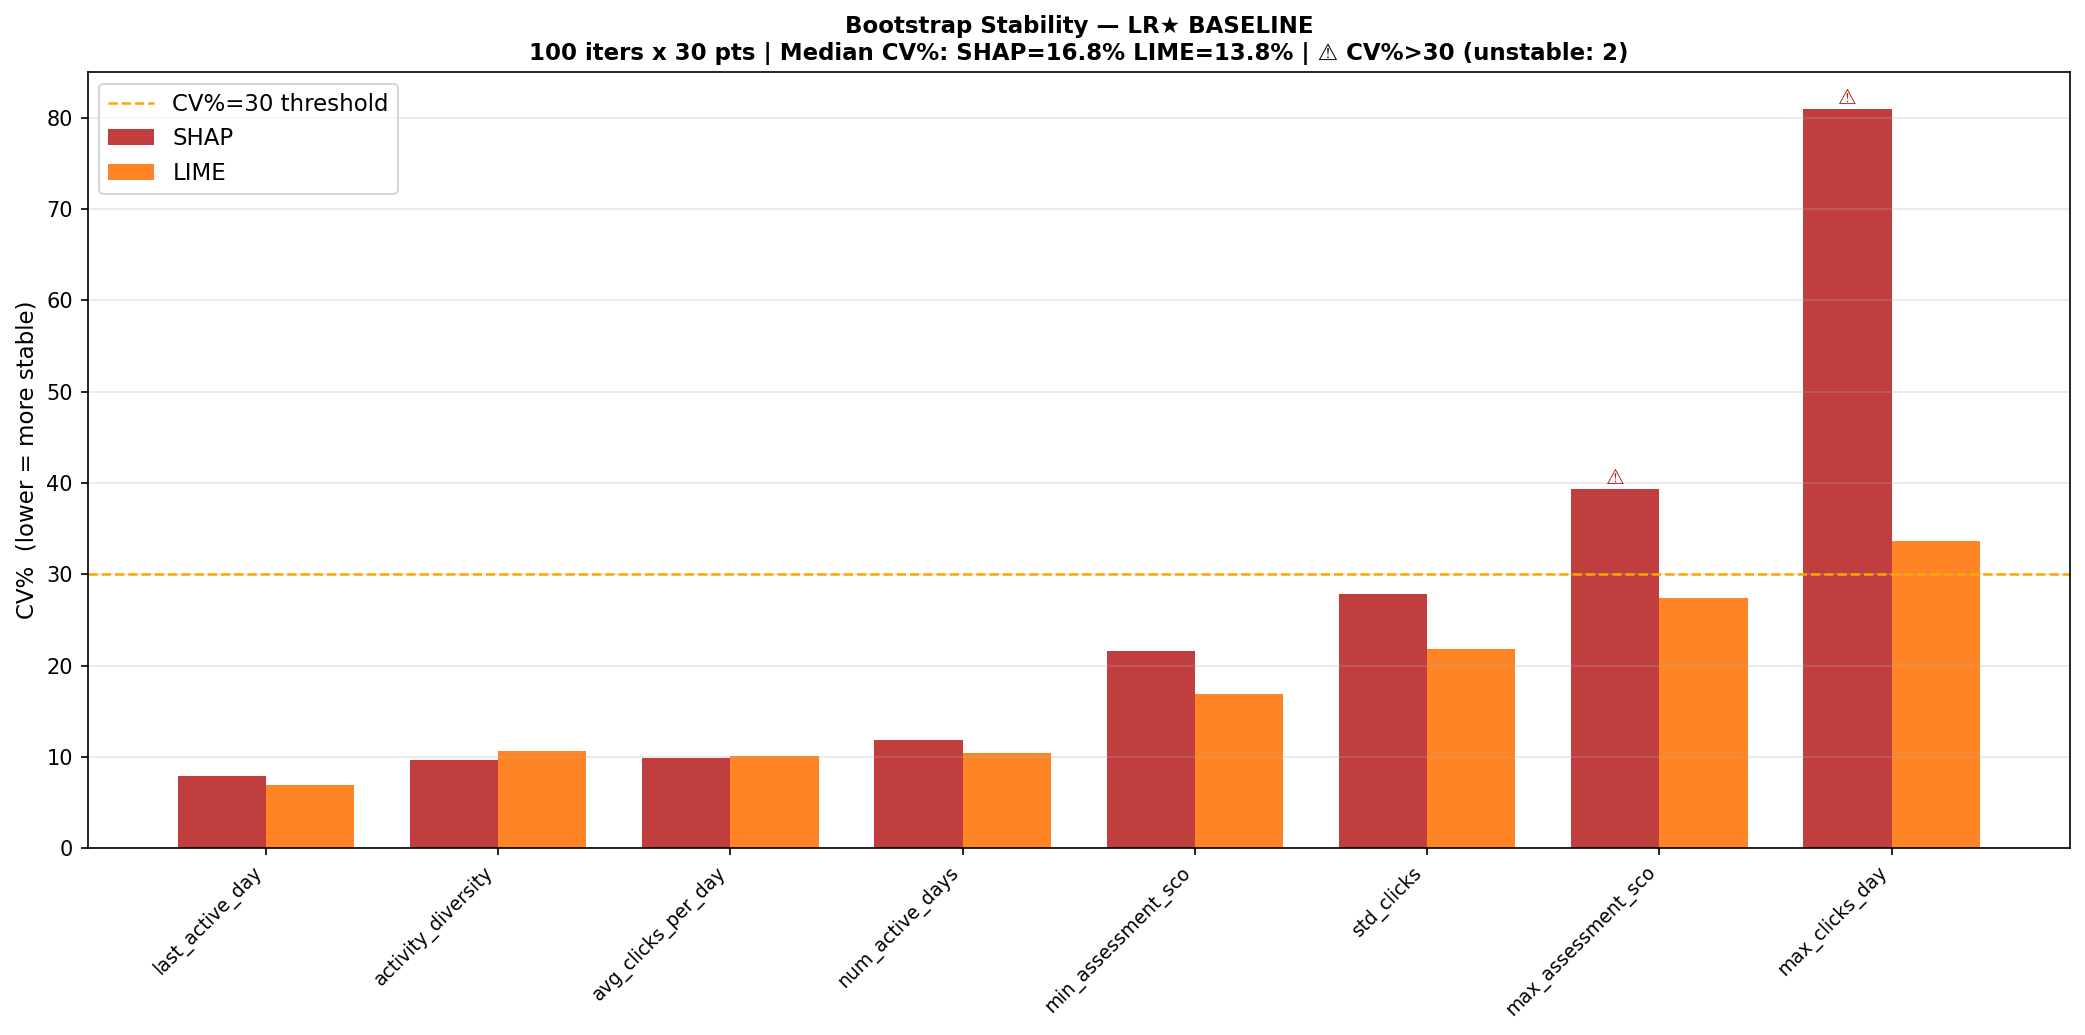

Stable (CV%≤30): 6  |  Unstable: 2


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17 — BOOTSTRAP STABILITY  (100 iterations, 30 fixed points)
# ════════════════════════════════════════════════════════════════════════════
N_BOOT      = 100
N_FIX       = 30
N_LIME_FEAT = len(auto_shap_lr)
# 1000 = literature lower bound; full 5000 x bootstrap iters is prohibitive.
# Single-shot global LIME uses the full 5000.
N_LIME_SAMP = 1000
trk_feats   = list(auto_shap_lr.index)


# ── [FIX F1] Stratified selection of the fixed bootstrap evaluation points ──
# The previous version used np.random.choice(..., replace=False), i.e. a simple
# random sample. The methodology requires proportional representation of the
# four confusion-matrix categories (TP, TN, FP, FN) at the default threshold
# tau = 0.50, so that the stability estimate is not dominated by whichever
# category happens to be over-drawn. This helper enforces that quota and
# reports the realised composition, which is the number the thesis cites.
def stratified_fixed_points(y_true, y_prob, n_fix, thr=0.50, seed=SEED, verbose=True):
    """Pick n_fix test indices with ~equal representation of TP/TN/FP/FN."""
    y_true = np.asarray(y_true).astype(int)
    y_hat  = (np.asarray(y_prob) >= thr).astype(int)
    cats = {
        'TP': np.where((y_true == 1) & (y_hat == 1))[0],
        'TN': np.where((y_true == 0) & (y_hat == 0))[0],
        'FP': np.where((y_true == 0) & (y_hat == 1))[0],
        'FN': np.where((y_true == 1) & (y_hat == 0))[0],
    }
    rng = np.random.RandomState(seed)
    base, extra = divmod(n_fix, 4)
    quota = {k: base for k in cats}
    # distribute the remainder to the largest categories first, deterministically
    for k in sorted(cats, key=lambda c: -len(cats[c]))[:extra]:
        quota[k] += 1
    picked, realised = [], {}
    for k in ['TP', 'TN', 'FP', 'FN']:
        take = min(quota[k], len(cats[k]))
        if take > 0:
            picked.extend(rng.choice(cats[k], take, replace=False))
        realised[k] = take
    picked = np.array(picked)
    # if a category was too small to fill its quota, top up from the remainder
    if len(picked) < n_fix:
        pool = np.setdiff1d(np.arange(len(y_true)), picked)
        picked = np.concatenate([picked, rng.choice(pool, n_fix - len(picked),
                                                    replace=False)])
    picked = np.sort(picked)
    if verbose:
        print(f'  [F1] Fixed points (threshold {thr:.2f}): '
              + ', '.join(f'{k}={realised[k]}' for k in ["TP","TN","FP","FN"])
              + f'  | total={len(picked)}')
        print(f'  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1')
    return picked, realised

np.random.seed(SEED)
Xta = np.array(X_tr_p, dtype=np.float32)
yta = np.array(y_train_arr, dtype=np.int64)
fix_idx, fix_composition = stratified_fixed_points(
    y_test_arr, y_prob_lr, N_FIX, thr=0.50, seed=SEED)
X_fix   = X_te_lr[fix_idx]

# [FIX F3] match the main analysis (Cell: SHAP ANALYSIS) exactly
BOOT_SHAP_BG       = 100
BOOT_SHAP_NSAMPLES = 100

sb = {f:[] for f in trk_feats}
lb = {f:[] for f in trk_feats}
n_lime_fail = 0                                     # [FIX F5]

print(f'Bootstrap: {N_BOOT} iters x {N_FIX} fixed pts | SHAP=KernelExplainer | LIME={N_LIME_SAMP} samples')
print('-'*60)

for b in range(N_BOOT):
    bi     = np.random.choice(len(Xta),len(Xta),replace=True)
    Xb,yb  = Xta[bi],yta[bi]

    # Retrain LR on bootstrap sample using best GridSearch hyperparams
    from sklearn.linear_model import LogisticRegression as LR_boot
    _best_lr_p = trained_models['Logistic Regression'].named_steps['clf'].get_params()
    lr_b = LR_boot(
        C              = _best_lr_p.get('C', 1),
        penalty        = _best_lr_p.get('penalty', 'l2'),
        solver         = _best_lr_p.get('solver', 'saga'),
        max_iter       = _best_lr_p.get('max_iter', 1000),
        class_weight   = 'balanced',
        random_state   = SEED+b)
    lr_b.fit(Xb,yb)

    # SHAP: KernelExplainer on 50 background points (faster for bootstrap)
    # [FIX F3] background and coalition counts raised from 50/50 to 100/100 so
    #          that the bootstrap SHAP estimate carries no more Monte-Carlo
    #          noise than the global SHAP estimate actually reported.
    bg_b  = shap.sample(Xb, BOOT_SHAP_BG, random_state=SEED+b)
    se_b  = shap.KernelExplainer(lambda x: lr_b.predict_proba(x)[:,1], bg_b)
    sv_b  = np.array(se_b.shap_values(X_fix, nsamples=BOOT_SHAP_NSAMPLES), dtype=float)
    sv_b  = safe_kernel_shap(sv_b, len(FEATURE_NAMES_SEL))
    ms    = np.abs(sv_b).mean(0)
    for f in trk_feats:
        if f in FEATURE_NAMES_SEL: sb[f].append(ms[FEATURE_NAMES_SEL.index(f)])

    # LIME: all N_FIX points
    le_b = lime_tabular.LimeTabularExplainer(
        Xb.astype(np.float32), feature_names=FEATURE_NAMES_SEL,
        class_names=['Success','At-Risk'], mode='classification', random_state=SEED+b)
    lw_iter = {f:[] for f in trk_feats}
    for j in range(N_FIX):
        try:
            ex = le_b.explain_instance(X_fix[j].astype(np.float32),
                lr_b.predict_proba, num_features=N_LIME_FEAT,
                num_samples=N_LIME_SAMP, labels=(1,))
            for feat_str,w in ex.as_list(label=1):
                # [FIX F4] use the same matcher as compute_lime_global
                fn = _match_feature(feat_str, FEATURE_NAMES_SEL)
                if fn in lw_iter: lw_iter[fn].append(abs(w))
        except Exception as e:                      # [FIX F5] count, don't swallow
            n_lime_fail += 1
            if n_lime_fail <= 3:
                print(f'    [warn] LIME failed (iter {b}, point {j}): '
                      f'{type(e).__name__}: {e}')
    for f in trk_feats:
        if lw_iter[f]: lb[f].append(np.mean(lw_iter[f]))

    if (b+1)%10==0: print(f'  [{b+1:3d}/{N_BOOT}] done')

if n_lime_fail:                                     # [FIX F5]
    print(f'\n[F5] LIME explanations that failed: {n_lime_fail} '
          f'of {N_BOOT*N_FIX} ({100*n_lime_fail/(N_BOOT*N_FIX):.2f}%) '
          f'- report this figure if non-zero.')
else:
    print('\n[F5] No LIME explanation failures.')

def cv_percent(values):
    arr = np.array(values,dtype=float)
    if len(arr)<5 or arr.mean()==0: return np.nan
    return arr.std()/arr.mean()*100

stab_rows = []
for f in trk_feats:
    stab_rows.append({'Feature':f,
        'SHAP_n':len(sb[f]),'SHAP_Mean':np.mean(sb[f]) if sb[f] else np.nan,
        'SHAP_CV%':cv_percent(sb[f]),
        'LIME_n':len(lb[f]),'LIME_Mean':np.nanmean(lb[f]) if lb[f] else np.nan,
        'LIME_CV%':cv_percent(lb[f])})
stab = pd.DataFrame(stab_rows).sort_values('SHAP_CV%')
stab.to_csv(CSV_DIR/'stability_LR.csv',index=False)

shap_cv_med = stab['SHAP_CV%'].dropna().median()
lime_cv_med = stab['LIME_CV%'].dropna().median()
print(f'\nMedian CV% — SHAP: {shap_cv_med:.1f}%   LIME: {lime_cv_med:.1f}%')

fig,ax = plt.subplots(figsize=(14,7))
x = np.arange(len(stab)); w = 0.38
ax.bar(x-w/2,stab['SHAP_CV%'].fillna(0),w,label='SHAP',color=PRIMARY_COLOR,alpha=0.85)
lime_bars = ax.bar(x+w/2,stab['LIME_CV%'].fillna(0),w,label='LIME',color='#FF6F00',alpha=0.85)
for j,lv in enumerate(stab['LIME_CV%']):
    if np.isnan(lv):
        lime_bars[j].set_hatch('///'); lime_bars[j].set_edgecolor('#888')
        lime_bars[j].set_facecolor('#CCCCCC')
        ax.text(x[j]+w/2,1.5,'N/A',ha='center',va='bottom',fontsize=7,color='#555',style='italic')
ax.axhline(30,color='orange',linestyle='--',linewidth=1.2,label='CV%=30 threshold')
stab_r = stab.reset_index(drop=True)
for j,row in stab_r.iterrows():
    if not np.isnan(row['SHAP_CV%']) and row['SHAP_CV%']>30:
        ax.text(x[j]-w/2,row['SHAP_CV%']+0.5,'⚠',ha='center',fontsize=10,color='#B71C1C')
ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in stab['Feature']],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('CV%  (lower = more stable)',fontsize=11)
n_stable   = (stab['SHAP_CV%'].dropna()<=30).sum()
n_unstable = (stab['SHAP_CV%'].dropna()>30).sum()
ax.set_title(f'Bootstrap Stability — LR★ BASELINE\n'
             f'{N_BOOT} iters x {N_FIX} pts | Median CV%: SHAP={shap_cv_med:.1f}% LIME={lime_cv_med:.1f}% | '
             f'⚠ CV%>30 (unstable: {n_unstable})',fontweight='bold',fontsize=11)
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'stability_LR.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Stable (CV%≤30): {n_stable}  |  Unstable: {n_unstable}')


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Method  Total_s  Per_Instance_ms
  SHAP    1.123           11.227
  LIME    5.623           56.232

SHAP is 5.0x faster than LIME for LR
Note: KernelExplainer is slower than TreeExplainer (XGBoost) —
      this reflects the model-agnostic overhead, not a LR weakness.


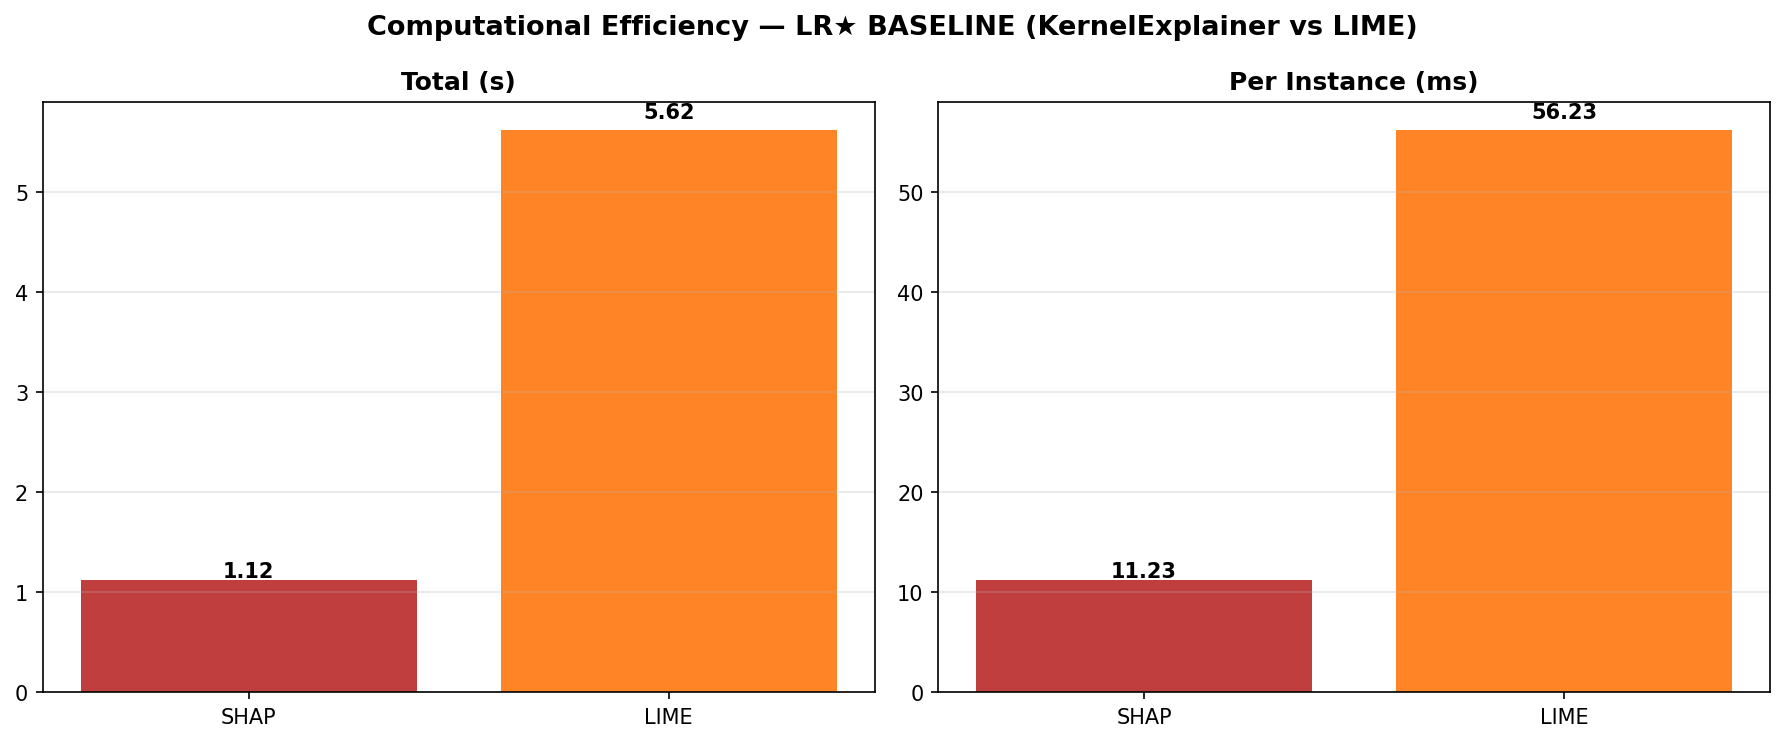

All LR Baseline analyses complete.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 18 — COMPUTATIONAL EFFICIENCY (SHAP vs LIME)
# ════════════════════════════════════════════════════════════════════════════
N_EFF          = 100
N_LIME_SAMP_EFF = LIME_PERTURB_SAMPLES
np.random.seed(SEED)
eff_idx = np.random.choice(len(X_te_lr), N_EFF, replace=False)
Xe      = X_te_lr[eff_idx]

bg_speed  = shap.sample(X_tr_p, 100, random_state=SEED)
se_speed  = shap.KernelExplainer(lambda x: lr_pipe.named_steps['clf'].predict_proba(x)[:,1], bg_speed)

# Warm-up
se_speed.shap_values(Xe[:3], nsamples=50)
_ = lime_exp.explain_instance(Xe[0],lime_fn,num_features=len(auto_shap_lr),
                               num_samples=N_LIME_SAMP_EFF,labels=(1,))

# Timed runs
t0 = time.time(); se_speed.shap_values(Xe, nsamples=100); shap_eff = time.time()-t0
t0 = time.time()
for i in range(N_EFF):
    lime_exp.explain_instance(Xe[i],lime_fn,num_features=len(auto_shap_lr),
                               num_samples=N_LIME_SAMP_EFF,labels=(1,))
lime_eff = time.time()-t0

eff = pd.DataFrame({'Method':['SHAP','LIME'],
    'Total_s':[shap_eff,lime_eff],
    'Per_Instance_ms':[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000]})
eff.to_csv(CSV_DIR/'efficiency_LR.csv',index=False)
print(eff.to_string(index=False,float_format='{:.3f}'.format))
print(f'\nSHAP is {lime_eff/shap_eff:.1f}x faster than LIME for LR')
print('Note: KernelExplainer is slower than TreeExplainer (XGBoost) —')
print('      this reflects the model-agnostic overhead, not a LR weakness.')

fig,(a1,a2) = plt.subplots(1,2,figsize=(12,5))
for ax,vals,title in [(a1,[shap_eff,lime_eff],'Total (s)'),
                      (a2,[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000],'Per Instance (ms)')]:
    bars = ax.bar(['SHAP','LIME'],vals,color=[PRIMARY_COLOR,'#FF6F00'],alpha=0.85)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,v+v*0.02,f'{v:.2f}',ha='center',fontweight='bold')
    ax.set_title(title,fontweight='bold'); ax.grid(axis='y',alpha=0.3)
plt.suptitle('Computational Efficiency — LR★ BASELINE (KernelExplainer vs LIME)',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'efficiency_LR.png',dpi=150,bbox_inches='tight')
plt.show()
print('All LR Baseline analyses complete.')


LIME sensitivity analysis (LR primary) ...
     Setting  vs_reference_tau      p
perturb=1000            0.9167 0.0000
perturb=2500            0.8833 0.0000
perturb=5000            0.8667 0.0000
global_n=150            0.9000 0.0000
global_n=300            0.8667 0.0000


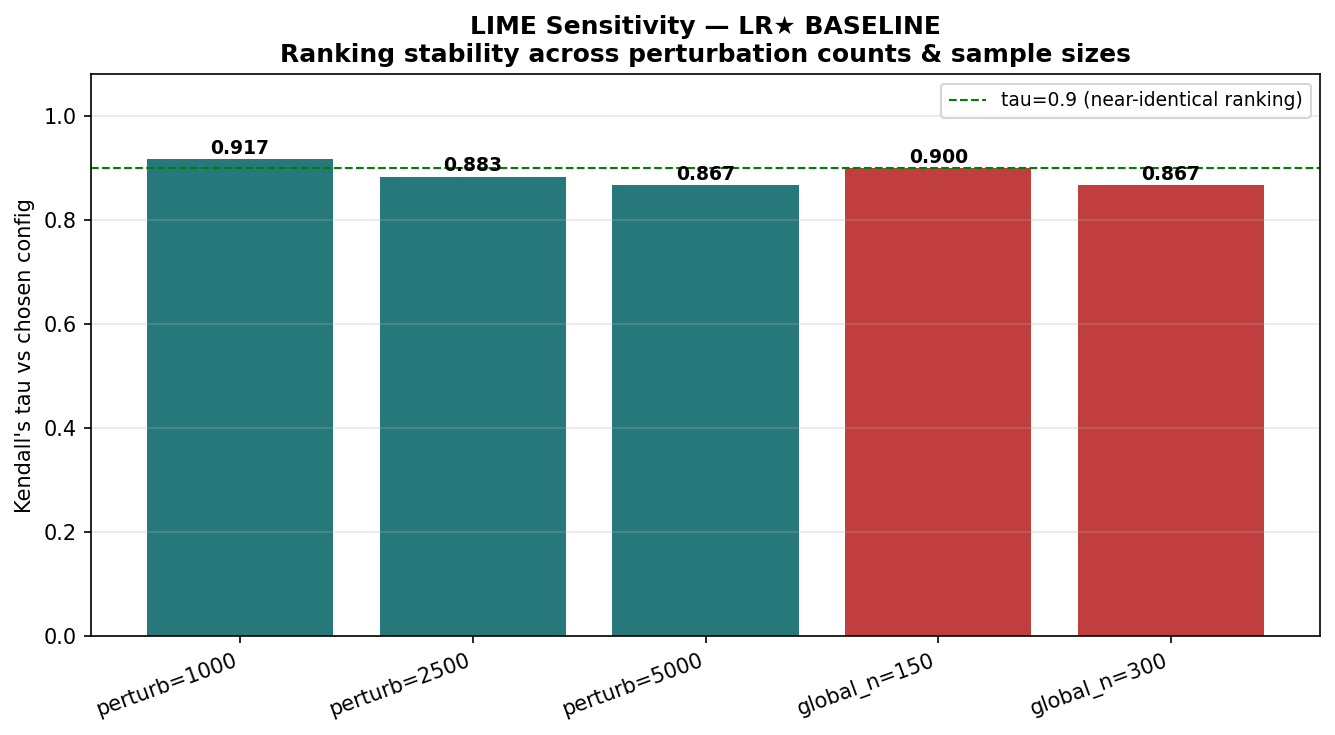


Interpretation: tau close to 1.0 => n_lime_samples=5000 & stratified sample size empirically justified.


In [ ]:

# ════════════════════════════════════════════════════════════════════════════
# LIME SENSITIVITY ANALYSIS — justifies n_lime_samples (perturbations) & sample size
# Global LIME ranking stability across perturbation counts {1000,2500,5000} and
# sample sizes {150,300}, measured by Kendall's tau vs the chosen config.
# ════════════════════════════════════════════════════════════════════════════
print('LIME sensitivity analysis (LR primary) ...')
_ref_order = list(lime_global.index)
sens_rows = []
for ns in [1000, 2500, 5000]:
    r = _lime_global_5(lime_fn, X_te_lr, y_test_arr, n=LIME_GLOBAL_N, n_samp=ns, seed=SEED)
    tau_s, p_s = kendalltau([_ref_order.index(f) for f in _ref_order],
                            [list(r.index).index(f) for f in _ref_order])
    sens_rows.append({'Setting': f'perturb={ns}', 'vs_reference_tau': tau_s, 'p': p_s})
for gn in [150, 300]:
    r = _lime_global_5(lime_fn, X_te_lr, y_test_arr, n=gn, n_samp=LIME_PERTURB_SAMPLES, seed=SEED)
    tau_s, p_s = kendalltau([_ref_order.index(f) for f in _ref_order],
                            [list(r.index).index(f) for f in _ref_order])
    sens_rows.append({'Setting': f'global_n={gn}', 'vs_reference_tau': tau_s, 'p': p_s})
sens_df = pd.DataFrame(sens_rows)
try: sens_df.to_csv(CSV_DIR / 'lime_sensitivity.csv', index=False)
except Exception: sens_df.to_csv('lime_sensitivity.csv', index=False)
print(sens_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(9,5))
colors=['#006064' if 'perturb' in s else '#B71C1C' for s in sens_df['Setting']]
bars=ax.bar(sens_df['Setting'], sens_df['vs_reference_tau'], color=colors, alpha=0.85)
for bar,v in zip(bars,sens_df['vs_reference_tau']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.axhline(0.9,color='green',linestyle='--',linewidth=1,label='tau=0.9 (near-identical ranking)')
ax.set_ylabel("Kendall's tau vs chosen config"); ax.set_ylim(0,1.08)
ax.set_title("LIME Sensitivity — LR\u2605 BASELINE\nRanking stability across perturbation counts & sample sizes", fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3); plt.xticks(rotation=20,ha='right')
plt.tight_layout()
try: plt.savefig(FIGURES_DIR / 'lime_sensitivity.png', dpi=150, bbox_inches='tight')
except Exception: plt.savefig('lime_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInterpretation: tau close to 1.0 => n_lime_samples=5000 & stratified sample size empirically justified.')


In [ ]:
import joblib
from pathlib import Path

for p in sorted(Path('models_LR').glob('*.pkl')):
    m = joblib.load(p)
    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m
    print(f'\n--- {p.stem} ---')
    for k, v in clf.get_params().items():
        if v is not None and k not in ('random_state','n_jobs','verbose'):
            print(f'  {k}: {v}')


--- Decision_Tree ---
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: 5
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 10
  min_weight_fraction_leaf: 0.0
  splitter: best

--- Logistic_Regression ---
  C: 1
  class_weight: balanced
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  max_iter: 1000
  multi_class: deprecated
  penalty: l1
  solver: saga
  tol: 0.0001
  warm_start: False

--- Random_Forest ---
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: 10
  max_features: sqrt
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 5
  min_weight_fraction_leaf: 0.0
  n_estimators: 200
  oob_score: False
  warm_start: False

--- SVM ---
  C: 10
  break_ties: False
  cache_size: 200
  class_weight: balanced
  coef0: 0.0
  decision_function_shape: ovr
  degree: 3
  gamma: scale
  kernel: rbf
  max_iter: -1
  probability: True
  shrinking: True
  tol: 0.001

--- XGBoost -

In [ ]:
perf = pd.read_csv(CSV_DIR/'model_performance_LR.csv')
print(perf[['Model','Best_Params','CV_AUC']].to_string(index=False))

              Model                                                                                        Best_Params  CV_AUC
Logistic Regression                                                                {'clf__C': 1, 'clf__penalty': 'l1'}  0.7707
            XGBoost {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 0.8}  0.8084
      Decision Tree                      {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 10}  0.7823
      Random Forest                      {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}  0.8063
                SVM                                        {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}  0.7924
